In [1]:
#set up working directory locally following
import os
os.getcwd()

'/Users/fengshuoliu/Library/CloudStorage/OneDrive-BaylorCollegeofMedicine/Lab/Zhan/202308_IIA_combine_ic/analysis'

In [2]:
pwd

'/Users/fengshuoliu/Library/CloudStorage/OneDrive-BaylorCollegeofMedicine/Lab/Zhan/202308_IIA_combine_ic/analysis'

In [3]:
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

/var/folders/37/xlq517ls2276293h4xc51ydc0000gn/T/ipykernel_15628/3777615979.py:1: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display
  from IPython.core.display import display, HTML


In [4]:
os.chdir('../')
#os.chdir('/home/humble_local2_25t/fengshuo/home/Single_cell/Lab/Deigo/')
#os.chdir('/Users/fengshuoliu/OneDrive - Baylor College of Medicine/Lab/Liqun/202304_Neuts/Azizi_PrimaryBCatalas/')

In [5]:
import numpy as np
import pandas as pd
import scanpy as sc
import itertools  # Import itertools module
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.backends.backend_pdf import PdfPages
import seaborn as sns
from matplotlib.collections import PathCollection

In [17]:
adata = sc.read_h5ad('./data/merged/merged_with_sham.h5ad')  # the file that we the analysis results
adata

AnnData object with n_obs × n_vars = 81696 × 26387
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'log10GenesPerUMI', 'mitoRatio', 'seq.ID', 'surgery', 'age', 'tissue', 'biotin', 'replicate', 'percent.mt', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.1', 'seurat_clusters', 'SCT_snn_res.0.8', 'cluster_label_wFT', 'SCT_snn_res.0.6', 'cell_type', 'groups', 'nCount_TAG', 'nFeature_TAG', 'TAG_maxID', 'TAG_secondID', 'TAG_margin', 'TAG_classification', 'TAG_classification.global', 'hash.ID', 'SCT_snn_res.0.5', 'sample', 'celltype_A', 'celltype_B', 'integrated_snn_res.1', 'integrated_snn_res.2', 'integrated_snn_res.5'
    var: 'name'
    obsm: 'X_pca', 'X_tsne', 'X_umap'

In [7]:
adata

AnnData object with n_obs × n_vars = 81696 × 26387
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'log10GenesPerUMI', 'mitoRatio', 'seq.ID', 'surgery', 'age', 'tissue', 'biotin', 'replicate', 'percent.mt', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.1', 'seurat_clusters', 'SCT_snn_res.0.8', 'cluster_label_wFT', 'SCT_snn_res.0.6', 'cell_type', 'groups', 'nCount_TAG', 'nFeature_TAG', 'TAG_maxID', 'TAG_secondID', 'TAG_margin', 'TAG_classification', 'TAG_classification.global', 'hash.ID', 'SCT_snn_res.0.5', 'sample', 'celltype_A', 'celltype_B', 'integrated_snn_res.1', 'integrated_snn_res.2', 'integrated_snn_res.5'
    var: 'name'
    obsm: 'X_pca', 'X_tsne', 'X_umap'

In [16]:
#adata.obs['biotin'].astype(str) + '_' +  adata.obs['surgery'].astype(str) + '-' +
#adata.obs['sample'] = adata.obs['tissue'].astype(str) + '-' +adata.obs['biotin'].astype(str) + '_' +  adata.obs['surgery'].astype(str) + '-' + adata.obs['age'].astype(str) + '-' + adata.obs['replicate'].astype(str)
adata.obs['sample'] = adata.obs['tissue'].astype(str) + '-' + adata.obs['surgery'].astype(str) + '-' + adata.obs['age'].astype(str)
#adata.obs['tissue'] = adata.obs['tissue'].replace('bone marrow', 'bone')
# Count the number of unique values in 'sample' column
num_unique_samples = adata.obs['sample'].nunique()
num_unique_samples

11

In [108]:
adata.obs['cell_bio'] = adata.obs['celltype_C'].astype(str) + '-' + adata.obs['biotin'].astype(str)

In [ ]:
adata.write('./data/merged/merged_with_sham.IC.pos.h5ad')

In [104]:
# 1. Subset the adata object
#subset_values = ["#41", "#21", "#48", "#12", "#18", "#29", "#35", "#42", "#44", "#47", "#50"]
subset_values = ["pos"]
adata_subset = adata[adata.obs['biotin'].isin(subset_values), :]

In [53]:
sc.tl.pca(adata_subset)

/Users/fengshuoliu/miniforge3/envs/scvelo_env/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/Users/fengshuoliu/miniforge3/envs/scvelo_env/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/Users/fengshuoliu/miniforge3/envs/scvelo_env/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_

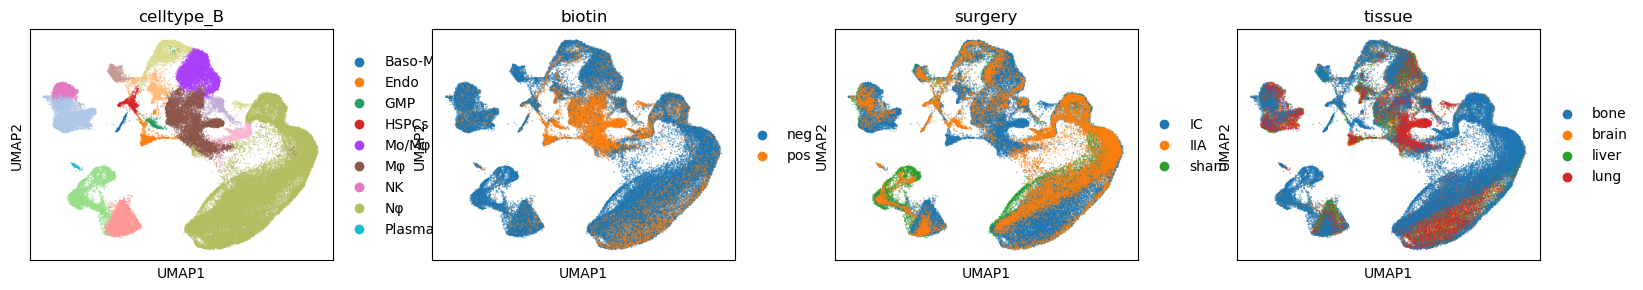

In [19]:
#cmap = plt.cm.get_cmap('inferno_r')  # brown-white gradient

with plt.rc_context({'figure.figsize': (4, 3)}):
    sc.pl.umap(adata, color = ['celltype_B',
                               'biotin',
                               'surgery',
                              'tissue'], size = 5, alpha=0.5
               ,legend_loc= 'right margin'
              #,save='all_umap_integrated.pdf'
              )

categories: Baso-Mast, Endo, GMP, etc.
var_group_labels: NK, T, immature B, etc.


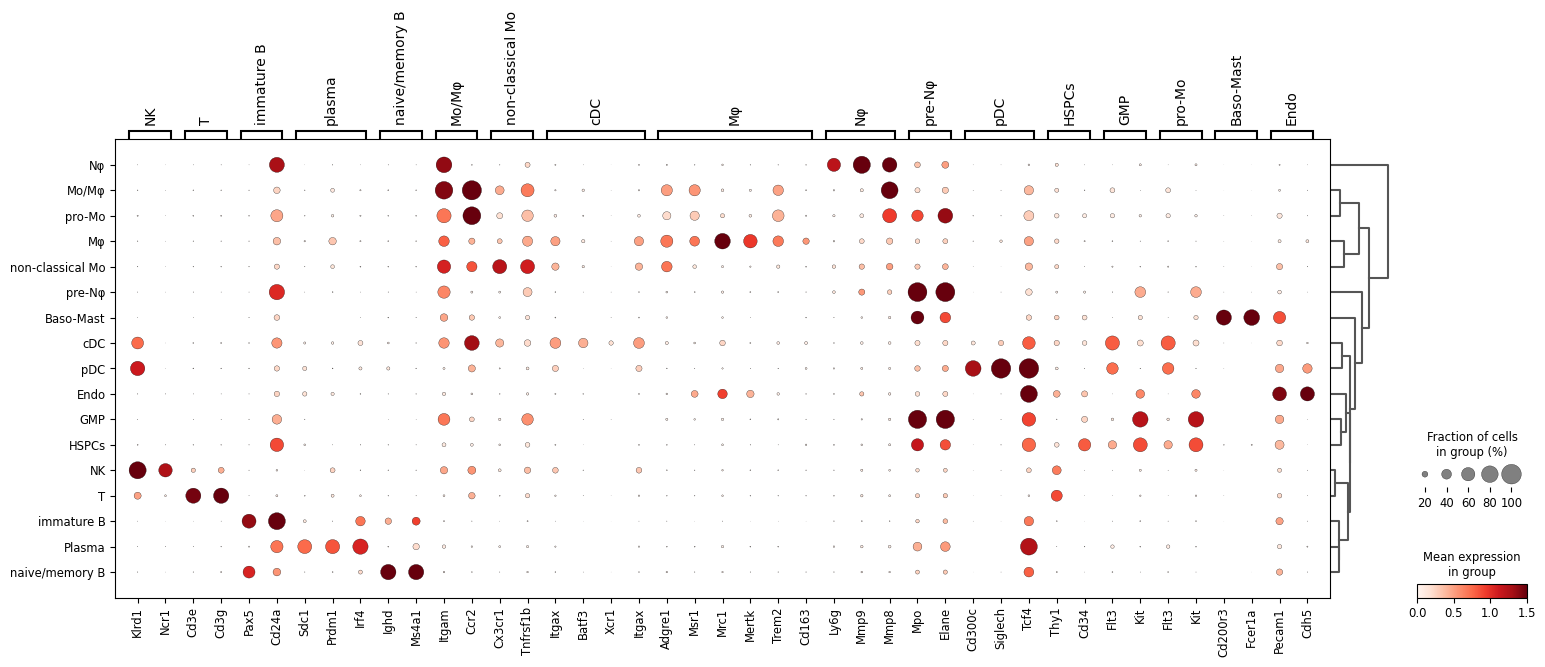

In [89]:
#all cell
markers = {'NK': ['Klrd1','Ncr1'],
           
           'T':['Cd3e','Cd3g'],
           
           'immature B': ['Pax5','Cd24a'],
           'plasma' : ['Sdc1','Prdm1','Irf4'],
           'naive/memory B' : ['Ighd','Ms4a1'],

           'Mo/Mφ': ['Itgam','Ccr2'],
           'non-classical Mo' : ['Cx3cr1','Tnfrsf1b'],
           'cDC': ['Itgax', 'Batf3','Xcr1','Itgax'],
           'Mφ': ['Adgre1','Msr1','Mrc1','Mertk','Trem2','Cd163'],
           'Nφ': ['Ly6g','Mmp9','Mmp8'],
           'pre-Nφ':['Mpo','Elane'], 
           'pDC':['Cd300c', 'Siglech', 'Tcf4'],
           'HSPCs' : ['Thy1','Cd34'],
           'GMP' : ['Flt3','Kit'],
           'pro-Mo' : ['Flt3','Kit'],
           'Baso-Mast' : ['Cd200r3','Fcer1a'],
           'Endo' : ['Pecam1','Cdh5']

          }

sc.pl.dotplot(adata, markers, groupby='celltype_B', 
              dendrogram=True,
              #min_logfoldchange=1.5,
              vmax=1.5,
              swap_axes=False
             ,save='all_cell_marker_dotplot.pdf'
             )

categories: Mo_c0, Mo_c4, Mo_c9, etc.
var_group_labels: pro-Mo, Mono, non-classical Mono, etc.


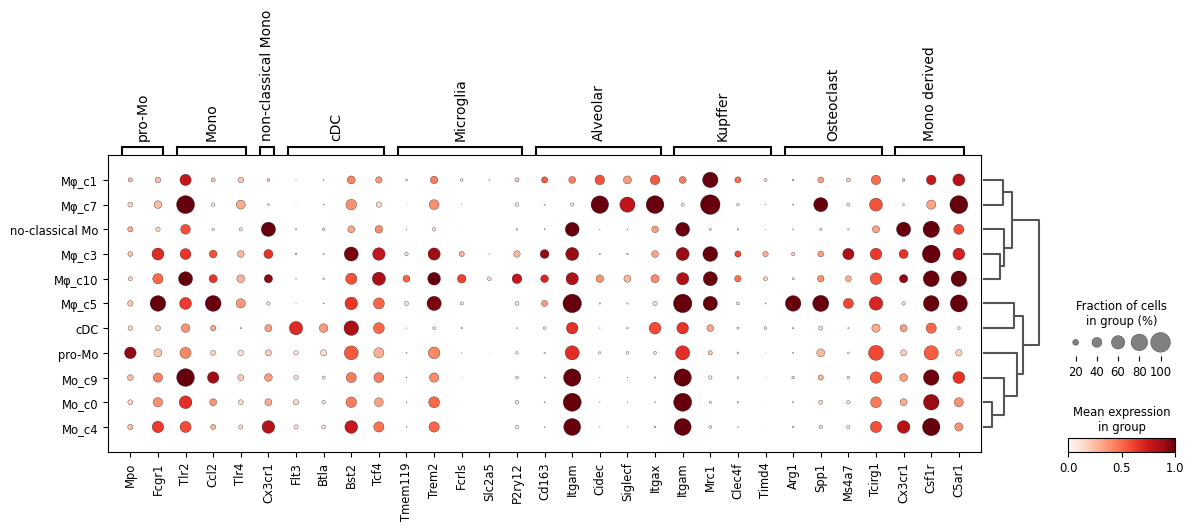

In [280]:
#all cell
markers = {'pro-Mo': ['Mpo','Fcgr1'],
           'Mono':['Tlr2','Ccl2','Tlr4'],
           'non-classical Mono': ['Cx3cr1'],
           'cDC' : ['Flt3','Btla','Bst2','Tcf4'],
           
           'Microglia' : ['Tmem119','Trem2','Fcrls','Slc2a5','P2ry12'],
           'Alveolar': ['Cd163','Itgam','Cidec','Siglecf','Itgax'],
           'Kupffer' : ['Itgam','Mrc1','   Clec4f','Timd4'],
           'Osteoclast': ['Arg1', 'Spp1','Ms4a7','Tcirg1'],
           'Mono derived': ['Cx3cr1','Csf1r','C5ar1'],

          }

sc.pl.dotplot(adata, markers, groupby='celltype_C', 
              dendrogram=True,
              vmin=0,
              vmax=1,
              swap_axes=False
             #,save='all_cell_marker_dotplot.pdf'
             )

In [ ]:
#PCA plot with horizontal bar area plot
#for tissue
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
from scipy.spatial import ConvexHull

# Assuming 'adata' is your Anndata object and it has 'tissue', 'celltype_B', and 'sample' in .obs
# Ensure PCA has been performed, and PCA results are in adata.obsm['X_pca']

# Extract the first two principal components
adata_subset.obs['pca_1'] = adata_subset.obsm['X_pca'][:, 0]
adata_subset.obs['pca_2'] = adata_subset.obsm['X_pca'][:, 1]

# Aggregate the PCA data by tissue and celltype (ignoring the sample)
agg_pca = (adata.obs.groupby(['tissue', 'celltype_C'])
           .agg({'pca_1': 'mean', 'pca_2': 'mean'})
           .reset_index())

# Define marker shapes for each tissue type
tissue_markers = {
    'bone': 'o',  # Circle
    'brain': 's',  # Square
    'liver': '^',  # Triangle up
    'lung': 'D',  # Diamond
    # Add more shapes as needed for different tissues
}

# Generate a color palette for cell types using a categorical colormap
num_celltypes = agg_pca['celltype_C'].nunique()
celltype_colors = plt.get_cmap('tab20', num_celltypes)

# Map colors to cell types
celltype_color_map = dict(zip(agg_pca['celltype_C'].unique(), celltype_colors.colors))

# Create the plot
fig, ax = plt.subplots(figsize=(6, 4))

# Draw connecting lines and calculate area
celltype_areas = {}

for celltype in agg_pca['celltype_C'].unique():
    # Filter points for the current celltype
    celltype_points = agg_pca[agg_pca['celltype_C'] == celltype][['pca_1', 'pca_2']]

    # Drop rows with NaN values
    celltype_points = celltype_points.dropna()

    # Convert to numpy array
    celltype_points = celltype_points.values

    # Check if there are enough points to form a convex hull
    if len(celltype_points) >= 3:
        try:
            hull = ConvexHull(celltype_points)
            for simplex in hull.simplices:
                ax.plot(celltype_points[simplex, 0], celltype_points[simplex, 1],
                        color=celltype_color_map[celltype])
            # Calculate area
            celltype_areas[celltype] = hull.volume
        except ValueError:
            # Handle the case where Convex Hull cannot be formed
            celltype_areas[celltype] = 0
    else:
        # Not enough points to form a convex hull, set area to zero
        celltype_areas[celltype] = 0


# Plot each cell type-tissue combination
for _, row in agg_pca.iterrows():
    ax.scatter(
        row['pca_1'],
        row['pca_2'],
        marker=tissue_markers[row['tissue']],
        color=celltype_color_map[row['celltype_C']],
        label=f"{row['tissue']}_{row['celltype_C']}"
    )

# Set labels and title
ax.set_xlabel('PCA 1')
ax.set_ylabel('PCA 2')
ax.set_title('PCA Plot by Cell Type and phenotype')

# Create a legend for cell types
celltype_patches = [Line2D([0], [0], marker='o', color='w', label=celltype,
                           markerfacecolor=color, markersize=10)
                    for celltype, color in celltype_color_map.items()]

# Create a legend for tissue types
tissue_patches = [Line2D([0], [0], marker=marker, color='w', label=tissue,
                         markerfacecolor='grey', markersize=10)
                  for tissue, marker in tissue_markers.items()]

# Add the first legend: cell types
first_legend = ax.legend(handles=celltype_patches, title='Cell Type', bbox_to_anchor=(1.05, 1), loc='upper left')

# Add the first legend to the plot
ax.add_artist(first_legend)

# Add the second legend: tissues
ax.legend(handles=tissue_patches, title='tissue', bbox_to_anchor=(1.05, 0.5), loc='center left')

# Show plot with tight layout
plt.tight_layout()
#plt.savefig('./outs/total_PCA_phenotype_celltypeC.pdf', dpi=300, transparent=True, bbox_inches='tight')
plt.show()
#--------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Sorting celltype areas in descending order
sorted_celltype_areas = sorted(celltype_areas.items(), key=lambda x: x[1], reverse=True)

# Extracting labels and values
labels, areas = zip(*sorted_celltype_areas)

# Create the vertical bar plot for cell type areas
fig, ax = plt.subplots(figsize=(4, 6))  # Adjust the figure size as needed
bars = ax.barh(labels, areas, color=[celltype_color_map[label] for label in labels])
ax.set_xlabel('Area')
ax.set_title('Area of Each Cell Type in PCA Plot')

# Set the limit for the x-axis, adjust the max_x_value as needed
max_x_value = max(areas) * 1.1  # Set a bit larger than the max area
ax.set_xlim(0, 10)

# Invert the y-axis to have the largest bar on top
ax.invert_yaxis()

# Annotate each bar with the cell type name
for bar, label in zip(bars, labels):
    label_x_pos = bar.get_width() + max_x_value * 0.01  # Adjust this value to move the label to the right
    ax.text(label_x_pos, bar.get_y() + bar.get_height() / 2, label, va='center')

# Rotate x-axis labels to the bottom (default position)
plt.xticks(rotation=0)

# Remove y-axis labels (since they are redundant with bar annotations)
ax.set_yticklabels([])

# Show the plot
plt.tight_layout()
#plt.savefig('./outs/PCA_phenotype_area_celltypeC.pdf', dpi=300, transparent=True, bbox_inches='tight')
plt.show()

In [ ]:
#data pre-processing including harmony
from harmony.harmony import harmonize
#normolize
sc.pp.normalize_total(adata, target_sum=1e4)
#log transform
sc.pp.log1p(adata)
#identify highly variable genes
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)
adata = adata[:, adata.var.highly_variable]
#optional
#sc.pp.regress_out(adata, ['nCount_RNA', 'percent.mt'])
#scale
sc.pp.scale(adata, max_value=10)
#PCA
sc.tl.pca(adata, svd_solver='arpack')

#harmony starts--------------------------------------------------------------------------------
# Assuming that the 'cancer' column in merged_adata.obs denotes different cancer types
data_mat = adata.obsm['X_pca']
meta_data = adata.obs
vars_use = ['cancer']  # This should be the column name in adata.obs that indicates batches
harmony_out = harmonize(data_mat, meta_data, vars_use)
print(harmony_out.shape)
print(data_mat.shape)
print(adata.shape)
#check above outputs before next
adata.obsm['X_pca_harmony'] = harmony_out.reshape(73607, 50)
#harmony ends--------------------------------------------------------------------------------
#compute neighborhood graph
sc.pp.neighbors(adata, use_rep='X_pca_harmony')
#UMAP embedding
sc.tl.umap(adata)
#clustering
sc.tl.leiden(adata)

[<Axes: title={'center': 'celltype_C'}, xlabel='UMAP1', ylabel='UMAP2'>,
 <Axes: title={'center': 'tissue'}, xlabel='UMAP1', ylabel='UMAP2'>,
 <Axes: title={'center': 'biotin'}, xlabel='UMAP1', ylabel='UMAP2'>]

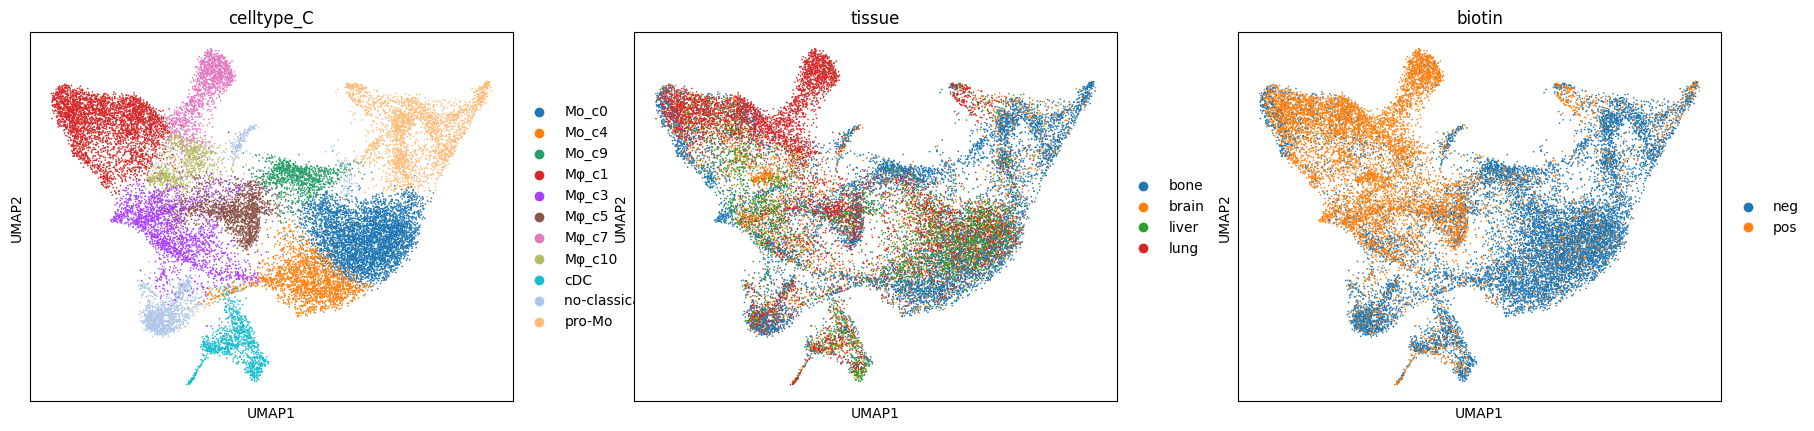

In [3]:
sc.pl.umap(adata, color=['celltype_C', 'tissue', 'biotin'], show=False)

In [ ]:
#Feature plot-1
cmap = plt.cm.get_cmap('cividis_r')
#rc_context is used for the figure size, in this case 4x4
with plt.rc_context({'figure.figsize': (4, 4)}):
    sc.pl.umap(adata, color=["Ptprc","Cd3g", "Cd79a","Cd68", "Epcam","Krt19", "Krt18", "Krt8", "Pecam1","Acta2", "Myl9","Mylk"],
              ncols=4,
              size=15,
              cmap=cmap,
              save='celltype_A marker.pdf')

In [ ]:
#Feature plot-2
# Calculate global vmin and vmax for the 'ESR1' across all datasets
all_values = np.concatenate([
    adata_M_LC[:, 'ESR1'].X.flatten(),
    adata_F_LC[:, 'ESR1'].X.flatten(),
    adata_F_ctrl[:, 'ESR1'].X.flatten()
])
vmin, vmax = np.min(all_values), np.max(all_values)

fig, axs = plt.subplots(1, 3, figsize=(12, 4))  # 1 row x 3 columns

# Define the reversed colormap
cmap = plt.cm.get_cmap('inferno_r')  # brown-white gradient

# Plot for adata_M_LC
sc.pl.umap(adata_M_LC, color=['ESR1'],size=12, use_raw=False, ax=axs[0], show=False, cmap=cmap, vmin=vmin, vmax=vmax)
axs[0].set_title('LC_males')

# Plot for adata_F_LC
sc.pl.umap(adata_F_LC, color=['ESR1'],size=12, use_raw=False, ax=axs[1], show=False, cmap=cmap, vmin=vmin, vmax=vmax)
axs[1].set_title('LC_females')

# Plot for adata_F_ctrl
sc.pl.umap(adata_F_ctrl, color=['ESR1'],size=12, use_raw=False, ax=axs[2], show=False, cmap=cmap, vmin=vmin, vmax=vmax)
axs[2].set_title('ctrl_females')

# Calculate global y-limits
all_ys = np.concatenate([
    adata_M_LC.obsm['X_umap'][:, 1],
    adata_F_LC.obsm['X_umap'][:, 1],
    adata_F_ctrl.obsm['X_umap'][:, 1]
])
ymin, ymax = np.min(all_ys), np.max(all_ys)

# Set consistent y-limits and remove borders for all plots
for ax in axs:
    ax.set_ylim(ymin, ymax)
    for spine in ax.spines.values():
        spine.set_visible(False)

plt.tight_layout()
#plt.savefig("ESR1_in_KC_by_gender.pdf", dpi=600, transparent=True)  # Save the figure with a transparent background

plt.show()

In [21]:
#Density plot
from scipy.stats import kde
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec

# Convert the 'cancer' column to categorical type
adata.obs['tissue'] = adata.obs['tissue'].astype('category')

# Define the cancer types
tissue_types = adata.obs['tissue'].cat.categories

# Save original parameters
original_figsize = plt.rcParams['figure.figsize']
original_dpi = plt.rcParams['figure.dpi']

# Set global size parameters (smaller plot size and higher DPI for higher resolution)
plt.rcParams['figure.dpi'] = 600

# Determine the grid layout for the plots
n_cols = 4
n_rows = int(np.ceil(len(tissue_types) / n_cols))

# Create a figure and grid layout
fig = plt.figure(figsize=(24, 4 * n_rows))
gs = gridspec.GridSpec(n_rows, n_cols + 1, width_ratios=[1] * n_cols + [0.05])

# For each cancer type, subset the data, calculate the density, and plot it
for idx, tissue in enumerate(tissue_types):
    ax = plt.subplot(gs[idx // n_cols, idx % n_cols])
    # Subset the data
    adata_tissue = adata[adata.obs['tissue'] == tissue]
    # Get UMAP coordinates
    x, y = adata_tissue.obsm['X_umap'].T
    # Compute density
    density = kde.gaussian_kde([x, y])
    zi = density([x, y])
    # Plot density as colors of dots
    sc = ax.scatter(x, y, c=zi, s=5, cmap="plasma_r")  # Smaller dot size
    ax.set_title(f'{tissue}')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_facecolor('white')  # White background

# Add a color scale bar
cax = plt.subplot(gs[:, -1])
plt.colorbar(sc, cax=cax, label='Density')

# Adjust layout
plt.tight_layout()
plt.savefig('./outs/iia_ic_merged/mye_embedding_density_plots_split_by_tissue.pdf', bbox_inches='tight')
plt.show()

# Reset to original values
plt.rcParams['figure.figsize'] = original_figsize
plt.rcParams['figure.dpi'] = original_dpi

Output hidden; open in https://colab.research.google.com to view.

In [22]:
#split the density plot by biotin as well
from scipy.stats import kde
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec

# Convert the 'cancer' and 'biotin' columns to categorical type
adata.obs['tissue'] = adata.obs['tissue'].astype('category')
adata.obs['biotin'] = adata.obs['biotin'].astype('category')

# Define the tissue and biotin types
tissue_types = adata.obs['tissue'].cat.categories
biotin_types = ['All'] + list(adata.obs['biotin'].cat.categories)  # Adding 'All' to represent combined biotin groups

# Save original parameters
original_figsize = plt.rcParams['figure.figsize']
original_dpi = plt.rcParams['figure.dpi']

# Set global size parameters
plt.rcParams['figure.dpi'] = 300

# Determine the grid layout for the plots
n_cols = 4
n_rows = int(np.ceil(len(tissue_types) * len(biotin_types) / n_cols))

# Create a figure and grid layout
fig = plt.figure(figsize=(24.5, 4 * n_rows))
gs = gridspec.GridSpec(n_rows, n_cols + 1, width_ratios=[1] * n_cols + [0.05])

# For each combination of tissue and biotin types, subset the data, calculate the density, and plot it
plot_idx = 0
for biotin in biotin_types:
    for tissue in tissue_types:
        ax = plt.subplot(gs[plot_idx // n_cols, plot_idx % n_cols])

        # Subset the data
        if biotin == 'All':
            adata_subset = adata[adata.obs['tissue'] == tissue]
        else:
            adata_subset = adata[(adata.obs['tissue'] == tissue) & (adata.obs['biotin'] == biotin)]

        # Get UMAP coordinates
        x, y = adata_subset.obsm['X_umap'].T
        # Compute density
        density = kde.gaussian_kde([x, y])
        zi = density([x, y])
        # Plot density as colors of dots
        sc = ax.scatter(x, y, c=zi, s=15, cmap="plasma_r")
        ax.set_title(f'{tissue} - {biotin}')
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_facecolor('white')  # White background
        plot_idx += 1

# Add a color scale bar
cax = plt.subplot(gs[:, -1])
plt.colorbar(sc, cax=cax, label='Density')

# Adjust layout
plt.tight_layout()
plt.savefig('./outs/iia_ic_merged/mye_embedding_density_plots_split_by_tissue_and_biotin.pdf', bbox_inches='tight')
plt.show()

# Reset to original values
plt.rcParams['figure.figsize'] = original_figsize
plt.rcParams['figure.dpi'] = original_dpi


Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# find markers
sc.tl.rank_genes_groups(adata, groupby='tissue', method='wilcoxon')

/Users/fengshuoliu/anaconda3/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:582: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}
/Users/fengshuoliu/anaconda3/lib/python3.11/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


In [ ]:
adata.uns['rank_genes_groups']

{'params': {'groupby': 'celltype_C',
  'reference': 'rest',
  'method': 'wilcoxon',
  'use_raw': False,
  'layer': None,
  'corr_method': 'benjamini-hochberg'},
 'names': rec.array([('Retnlg', 'Il1b', 'Camp', 'Elane'),
            ('S100a6', 'Srgn', 'Ngp', 'Mpo'),
            ('Mmp8', 'Junb', 'Chil3', 'Prtn3'), ...,
            ('H2afz', 'Cd177', 'Junb', 'Tyrobp'),
            ('Ptma', 'S100a8', 'Fth1', 'S100a9'),
            ('Ppia', 'Ngp', 'Srgn', 'Cd52')],
           dtype=[('Nφ_c0', 'O'), ('Nφ_c1', 'O'), ('Nφ_c2', 'O'), ('pre-Nφ', 'O')]),
 'scores': rec.array([(127.800446,  125.07839 ,  145.80951,  59.34978 ),
            (105.871254,  119.49064 ,  139.70973,  59.345425),
            (100.04396 ,  118.86681 ,  136.49792,  58.942707), ...,
            (-55.16299 , -113.20965 , -114.58915, -53.70048 ),
            (-58.862015, -116.60578 , -128.70912, -54.31023 ),
            (-60.097305, -120.125305, -136.60204, -55.05451 )],
           dtype=[('Nφ_c0', '<f4'), ('Nφ_c1', '<f4'), ('N

In [ ]:
output_path = "./outs/iia_ic_merged/neuts_degs"

# Loop over each celltype
for celltype in adata.uns['rank_genes_groups']['names'].dtype.names:
    # Create a dataframe for the current celltype
    df = pd.DataFrame({
        'names': adata.uns['rank_genes_groups']['names'][celltype],
        'scores': adata.uns['rank_genes_groups']['scores'][celltype],
        'pvals': adata.uns['rank_genes_groups']['pvals'][celltype],
        'pvals_adj': adata.uns['rank_genes_groups']['pvals_adj'][celltype],
        'logfoldchanges': adata.uns['rank_genes_groups']['logfoldchanges'][celltype]
    })

    # Save the dataframe to a CSV file in the specified directory
    filename = f"{output_path}/rank_genes_groups_{celltype}.csv"
    df.to_csv(filename, index=False)
    print(f"Saved data for {celltype} to {filename}")

Saved data for Nφ_c0 to ./outs/iia_ic_merged/neuts_degs/rank_genes_groups_Nφ_c0.csv
Saved data for Nφ_c1 to ./outs/iia_ic_merged/neuts_degs/rank_genes_groups_Nφ_c1.csv
Saved data for Nφ_c2 to ./outs/iia_ic_merged/neuts_degs/rank_genes_groups_Nφ_c2.csv
Saved data for pre-Nφ to ./outs/iia_ic_merged/neuts_degs/rank_genes_groups_pre-Nφ.csv


/Users/fengshuoliu/anaconda3/lib/python3.11/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/Users/fengshuoliu/anaconda3/lib/python3.11/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/Users/fengshuoliu/anaconda3/lib/python3.11/site-packages/scanpy/tools/_dendrogram.py:135: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observe

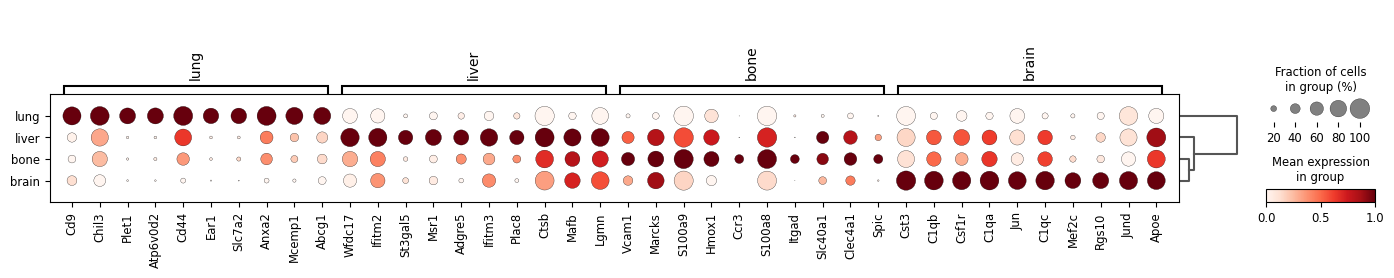

In [ ]:
adata.raw = adata
sc.pl.rank_genes_groups_dotplot(adata, groupby='tissue', n_genes=10, standard_scale='var',
                               #swap_axes=True,
                               save='IC_macs_tissue_marker dotplot.pdf',
                               use_raw=True)

In [10]:
#proliferation activities
gene_list = ['Maf','Mafb']
sc.tl.score_genes(adata, gene_list, score_name='cell_cycel_arrest')

#Hallmark_Hypoxia
gene_list = ["Ackr3", "Adm", "Adora2b", "Ak4", "Akap12", "Aldoa", "Aldob", "Aldoc", "Ampd3", "Angptl4", "Ankzf1", "Anxa2", "Atf3", "Atp7a", "B3galt6", "B4galnt2", "Bcan", "Bcl2", "Bgn", "Bhlhe40", "Bnip3l", "Brs3", "Btg1", "Car12", "Casp6", "Cav1", "Cavin1", "Cavin3", "Ccn1", "Ccn2", "Ccn5", "Ccng2", "Cdkn1a", "Cdkn1b", "Cdkn1c", "Chst2", "Chst3", "Cited2", "Col5a1", "Cp", "Csrp2", "Cxcr4", "Dcn", "Ddit3", "Ddit4", "Dpysl4", "Dtna", "Dusp1", "Edn2", "Efna1", "Efna3", "Egfr", "Eno1b", "Eno2", "Eno3", "Ero1a", "Errfi1", "Ets1", "Ext1", "F3", "Fam162a", "Fbp1", "Fos", "Fosl2", "Foxo3", "Gaa", "Galk1", "Gapdh-ps15", "Gapdhs", "Gbe1", "Gck", "Gcnt2", "Glrx", "Gpc1", "Gpc3", "Gpc4", "Gpi1", "Grhpr", "Gys1", "Has1", "Hdlbp", "Hexa", "Hk1", "Hk2", "Hmox1", "Hoxb9", "Hs3st1", "Hspa5", "Ids", "Ier3", "Igfbp1", "Igfbp3", "Il6", "Ilvbl", "Inha", "Irs2", "Isg20", "Jmjd6", "Jun", "Kdelr3", "Kdm3a", "Kif5a", "Klf6", "Klf7", "Klhl24", "Lalba", "Large1", "Ldha", "Ldhc", "Lox", "Lxn", "Maff", "Map3k1", "Mif", "Mt1", "Mxi1", "Myh9", "Nagk", "Ncan", "Ndrg1", "Ndst1", "Ndst2", "Nedd4l", "Nfil3", "Noct"]
sc.tl.score_genes(adata, gene_list, score_name='hypoxia')

#Response to estrogen
gene_list = ['Mir574', 'Mir493', 'Mir3065', 'Agtr1a', 'Agtr1b', 'Akr1c20', 'Ar', 'Arsb', 'Arsa', 'Brca1', 'Ctnnb1', 'Cav1', 'Cd24a', 'Cited1', 'Abcc2', 'Crhbp', 'Esr1', 'Gata4', 'Gata6', 'Gba', 'Ghrhr', 'Hmox1', 'Kcnma1', 'Mme', 'Mmp2', 'Cited2', 'Naip1', 'Naip2', 'Naip6', 'Nos1', 'Bcas3', 'Rara', 'Sfrp1', 'Rbbp5', 'Tbl1x', 'Arid5a', 'Tek', 'Trim25', 'Tgfb2', 'Tgfb3', 'Tgfbr1', 'Trim24', 'Wbp2', 'Wnt7a', 'Ash2l', 'Zfp366', 'Sra1', 'Mapk1', 'Ep300', 'Kmt2d', 'Mir18', 'Mir126a', 'Mir142', 'Mir143', 'Mir145a', 'Mir146', 'Mir148a', 'Mir195a', 'Mir206', 'Mir207', 'Mir125a', 'Mir125b-1', 'Mirlet7e', 'Rcan1', 'Cited4', 'Ghrl', 'Sfr1', 'Mir223', 'Mir297-1', 'Mir338', 'Mir451a', 'Mir486', 'Mir466', 'Mir708', 'Ocstamp', 'Mir672', 'Pelp1', 'Akr1c6']
sc.tl.score_genes(adata, gene_list, score_name='esr')

gene_list_ppar=['Acaa1a', 'Acaa1b', 'Acadl', 'Acadm', 'Acox1', 'Acox2', 'Acox3', 'Acsbg1', 'Acsbg2', 'Acsl1', 'Acsl3', 'Acsl4', 'Acsl5', 'Acsl6', 'Adipoq', 'Angptl4', 'Apoa1', 'Apoa2', 'Apoa5', 'Apoc3', 'Aqp7', 'Cd36', 'Cpt1a', 'Cpt1b', 'Cpt1c', 'Cpt2', 'Cyp27a1', 'Cyp4a10', 'Cyp4a12a', 'Cyp4a12b', 'Cyp4a14', 'Cyp4a29', 'Cyp4a30b', 'Cyp4a31', 'Cyp4a32', 'Cyp7a1', 'Cyp8b1', 'Dbi', 'Ehhadh', 'Fabp1', 'Fabp2', 'Fabp3', 'Fabp4', 'Fabp5', 'Fabp6', 'Fabp7', 'Fads2', 'Gk', 'Gk2', 'Hmgcs2', 'Ilk', 'Lpl', 'Me1', 'Mmp1a', 'Mmp1b', 'Nr1h3', 'Olr1', 'Pck1', 'Pck2', 'Pdpk1', 'Plin1', 'Pltp', 'Ppara', 'Ppard', 'Pparg', 'Rxra', 'Rxrb', 'Rxrg', 'Scd1', 'Scd2', 'Scd3', 'Scd4', 'Scp2', 'Slc27a1', 'Slc27a2', 'Slc27a4', 'Slc27a5', 'Slc27a6', 'Sorbs1', 'Ubc', 'Ucp1']
sc.tl.score_genes(adata, gene_list_ppar, score_name='pparg')
#GOBP_POSITIVE_REGULATION_OF_NEUROINFLAMMATORY_RESPONSE
gene_list=["Csf1r", "Ctsc", "Kcnn4", "Lrrk2", "Mmp8", "Nupr1", "Plcg2", "Stap1", "Sall1", "Trem2", "P2ry12"]
sc.tl.score_genes(adata, gene_list, score_name='neuroninflammation')

#GOBP_POSITIVE_REGULATION_OF_REACTIVE_OXYGEN_SPECIES_BIOSYNTHETIC_PROCESS
gene_list=["Adcy10", "Adgrb1", "Alox12", "Cd36", "Clcn3", "Cyba", "Duoxa1", "Duoxa2", "Foxo3", "Grin1", "Hdac4", "Il4", "Lcn2", "Mfn2", "Nox4", "Ogt", "Park7", "Plcg2", "Rab27a", "Slc5a3", "Sod2", "Tlr4", "Tlr6", "Zfp13"]
sc.tl.score_genes(adata, gene_list, score_name='ros')


#GOMF_HEAT_SHOCK_PROTEIN_BINDING
gene_list=['Acaca', 'Actr2', 'Actr3', 'Adcy2', 'Akt1', 'Akt1s1', 'Ap2m1', 'Arf1', 'Arhgdia', 'Arpc3', 'Atf1', 'Cab39', 'Cab39l', 'Calr', 'Camk4', 'Cdk1', 'Cdk2', 'Cdk4', 'Cdkn1a', 'Cdkn1b', 'Cfl1', 'Cltc', 'Csnk2b', 'Cxcr4', 'Dapp1', 'Ddit3', 'Dusp3', 'E2f1', 'Ecsit', 'Egfr', 'Eif4e', 'Fasl', 'Fgf17', 'Fgf22', 'Fgf6', 'Gna14', 'Gngt1', 'Grb2', 'Grk2', 'Gsk3b', 'Hras', 'Hsp90b1', 'Il2rg', 'Il4', 'Irak4', 'Itpr2', 'Lck', 'Map2k3', 'Map2k6', 'Map3k7', 'Mapk1'
]
sc.tl.score_genes(adata, gene_list, score_name='hsp')

       'Mir145a', 'Mir146', 'Mir148a', 'Mir195a', 'Mir206', 'Mir207',
       'Mir125a', 'Mir125b-1', 'Mirlet7e', 'Mir223', 'Mir297-1', 'Mir338',
       'Mir451a', 'Mir486', 'Mir466', 'Mir708', 'Mir672'],
      dtype='object')


/var/folders/37/xlq517ls2276293h4xc51ydc0000gn/T/ipykernel_74048/115211137.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('RdYlGn_r')  # brown-white gradient


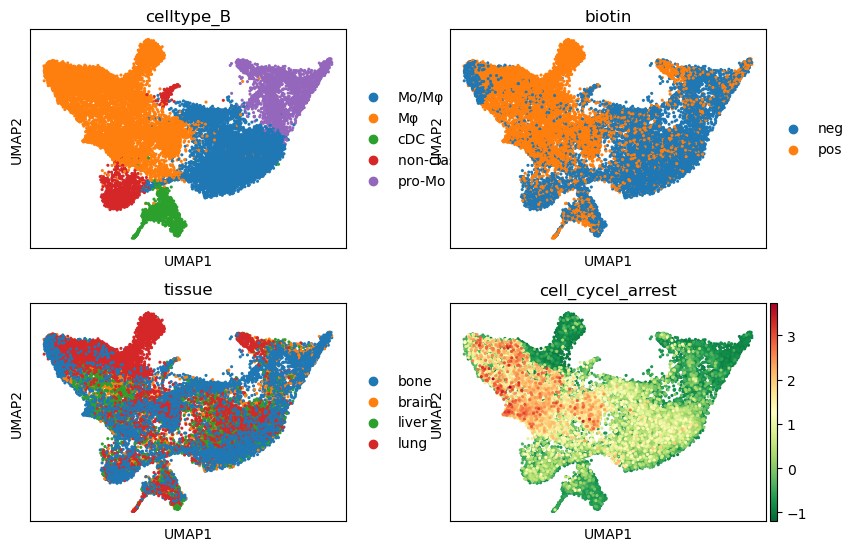

In [11]:
## rc_context is used for the figure size, in this case 4x4
# Define the reversed colormap
cmap = plt.cm.get_cmap('RdYlGn_r')  # brown-white gradient

with plt.rc_context({'figure.figsize': (4, 3)}):
    sc.pl.umap(adata, color= ['celltype_B','biotin','tissue','cell_cycel_arrest'
                             # ,'hsp','Mki67','Mcm7','Marco','Mki67'
                             ], cmap=cmap, ncols=2, size=20, alpha=1
               #, save='mye_for_proliferation.pdf'
              )

/var/folders/37/xlq517ls2276293h4xc51ydc0000gn/T/ipykernel_9083/1265885235.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('Spectral_r')


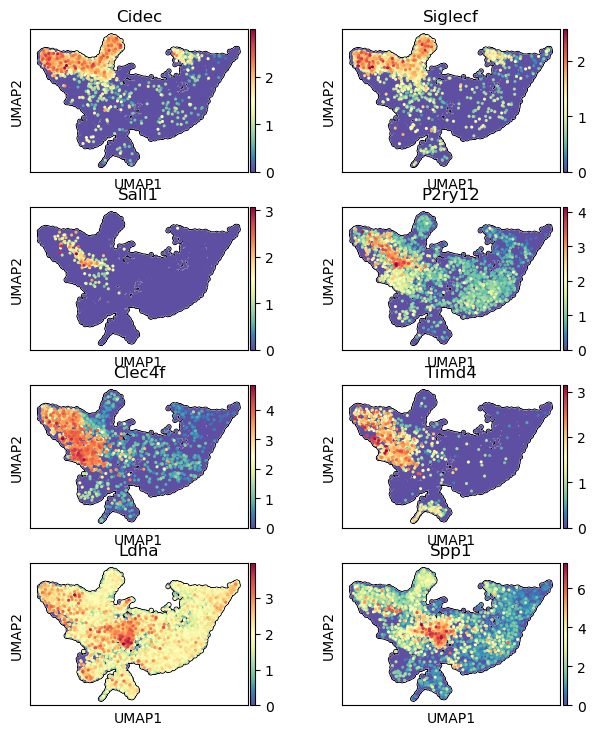

In [488]:
import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc

# Define the reversed colormap
cmap = plt.cm.get_cmap('Spectral_r')  

# Shuffle the order of the cells
shuffled_indices = np.random.permutation(adata.n_obs)
adata_shuffled = adata[shuffled_indices]

# Create the UMAP plots
with plt.rc_context({'figure.figsize': (2.67, 2)}):
    sc.pl.umap(
        adata_shuffled, 
        color=['Cidec', 'Siglecf', 'Sall1', 'P2ry12', 'Clec4f', 'Timd4', 'Ldha', 'Spp1'], 
        cmap=cmap, 
        ncols=2, 
        size=20, 
        alpha=1,
        add_outline=True,
        show=False  # Prevent automatic display
    )

    # Manually save with specified dpi and transparent background
    plt.savefig('./figures/tissue_specific_marker_featureplot.pdf', dpi=600, bbox_inches='tight', transparent=True)
    plt.show()  # Ensure the figure is displayed correctly

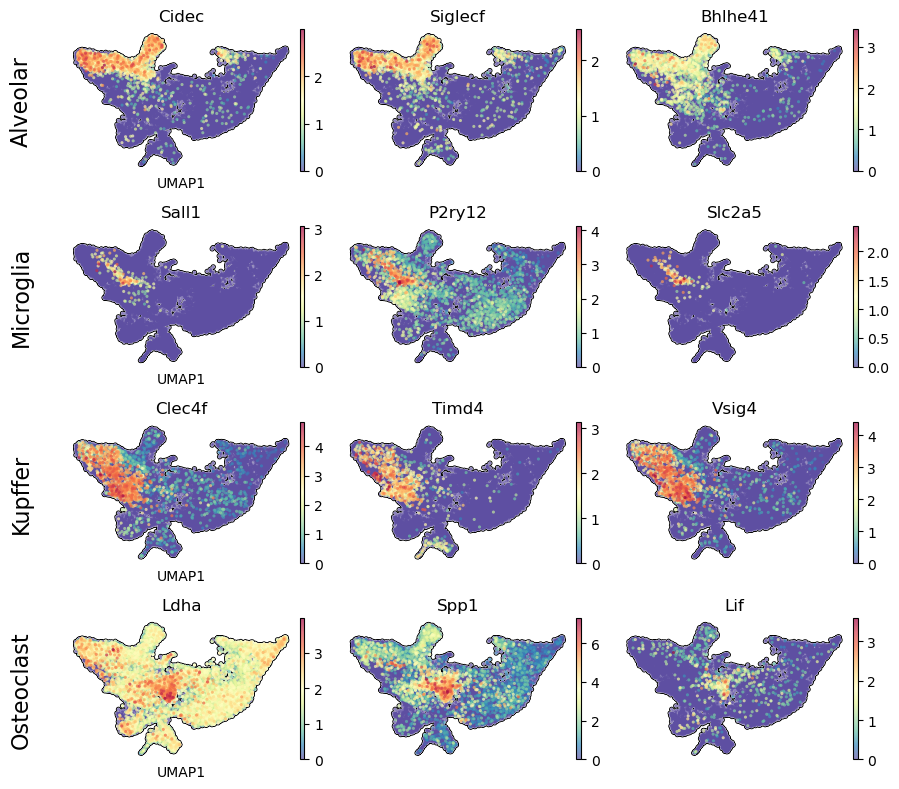

In [556]:
# In this example we want to show UMAPs of different cell type markers,
# with markers of a single cell type in one row
# and with a different number of markers per cell type (row)

# Marker genes
marker_genes = {
    "Alveolar": ['Cidec', 'Siglecf','Bhlhe41'],
    "Microglia": ['Sall1', 'P2ry12','Slc2a5'],
    "Kupffer": ['Clec4f', 'Timd4','Vsig4'],
    "Osteoclast": ['Ldha', 'Spp1','Lif'],
}
# Make Axes
# Number of needed rows and columns (based on the row with the most columns)
nrow = len(marker_genes)
ncol = max([len(vs) for vs in marker_genes.values()])
fig, axs = plt.subplots(nrow, ncol, figsize=(3 * ncol, 2 * nrow))
# Plot expression for every marker on the corresponding Axes object
for row_idx, (cell_type, markers) in enumerate(marker_genes.items()):
    col_idx = 0
    for marker in markers:
        ax = axs[row_idx, col_idx]
        sc.pl.umap(adata, color=marker, cmap=cmap,ax=ax, show=False, add_outline=True, frameon=False, legend_fontsize=18, legend_fontweight='bold', wspace=0.2, s=20)
        # Add cell type as row label - here we simply add it as ylabel of
        # the first Axes object in the row
        if col_idx == 0:
            # We disabled axis drawing in UMAP to have plots without background and border
            # so we need to re-enable axis to plot the ylabel
            ax.axis("on")
            ax.tick_params(
                top="off",
                bottom="off",
                left="off",
                right="off",
                labelleft="on",
                labelbottom="off"
            )
            ax.set_ylabel(cell_type + "\n", rotation=90, fontsize=16)
            ax.set(frame_on=False)
        col_idx += 1
    # Remove unused column Axes in the current row
    while col_idx < ncol:
        axs[row_idx, col_idx].remove()
        col_idx += 1
# Alignment within the Figure
fig.tight_layout()
plt.savefig('./figures/tissue_specific_marker_featureplot.png', 
            dpi=1200, 
            transparent=True,
            bbox_inches='tight')
plt.show()

In [24]:
# Function to convert list of genes to single quoted list separated by commas
def convert_genes_list(genes):
    # Convert list of genes to single quoted list separated by commas
    single_quoted_genes = ["'" + gene + "'" for gene in genes]
    return single_quoted_genes

# Input: Get list of genes from user
genes_input = input("Please enter a list of genes separated by spaces: ")
genes_list = genes_input.split()

# Convert list of genes
converted_genes_list = convert_genes_list(genes_list)

# Output: Print converted list of genes
print("Converted list of genes:")
print(", ".join(converted_genes_list))

Please enter a list of genes separated by spaces: Enpp1 gadd45g tsc22d4 ccl6 coro1a gpsm3 tgfbi chmp2a nr1h2 p2rx4 fermt3 gnb1 trf h2-T23 cxcl13 b4galf3 unc93b1 rabac1  ifitm1 il13ra1 smox slfn2 ugt1a10 tcn2 pxn ab12461 slc11a1 ogfrl1 chmp4b h3f3a lcp1 pfkp pias4 sdcbp gosr2 msn jak3 lgals9 atp6v0d1
Converted list of genes:
'Enpp1', 'gadd45g', 'tsc22d4', 'ccl6', 'coro1a', 'gpsm3', 'tgfbi', 'chmp2a', 'nr1h2', 'p2rx4', 'fermt3', 'gnb1', 'trf', 'h2-T23', 'cxcl13', 'b4galf3', 'unc93b1', 'rabac1', 'ifitm1', 'il13ra1', 'smox', 'slfn2', 'ugt1a10', 'tcn2', 'pxn', 'ab12461', 'slc11a1', 'ogfrl1', 'chmp4b', 'h3f3a', 'lcp1', 'pfkp', 'pias4', 'sdcbp', 'gosr2', 'msn', 'jak3', 'lgals9', 'atp6v0d1'


In [15]:
# calculate score: option and prapare the violin plot
#Response to estrogen
gene_list = ['Mir574', 'Mir493', 'Mir3065', 'Agtr1a', 'Agtr1b', 'Akr1c20', 'Ar', 'Arsb', 'Arsa', 'Brca1', 'Ctnnb1', 'Cav1', 'Cd24a', 'Cited1', 'Abcc2', 'Crhbp', 'Esr1', 'Gata4', 'Gata6', 'Gba', 'Ghrhr', 'Hmox1', 'Kcnma1', 'Mme', 'Mmp2', 'Cited2', 'Naip1', 'Naip2', 'Naip6', 'Nos1', 'Bcas3', 'Rara', 'Sfrp1', 'Rbbp5', 'Tbl1x', 'Arid5a', 'Tek', 'Trim25', 'Tgfb2', 'Tgfb3', 'Tgfbr1', 'Trim24', 'Wbp2', 'Wnt7a', 'Ash2l', 'Zfp366', 'Sra1', 'Mapk1', 'Ep300', 'Kmt2d', 'Mir18', 'Mir126a', 'Mir142', 'Mir143', 'Mir145a', 'Mir146', 'Mir148a', 'Mir195a', 'Mir206', 'Mir207', 'Mir125a', 'Mir125b-1', 'Mirlet7e', 'Rcan1', 'Cited4', 'Ghrl', 'Sfr1', 'Mir223', 'Mir297-1', 'Mir338', 'Mir451a', 'Mir486', 'Mir466', 'Mir708', 'Ocstamp', 'Mir672', 'Pelp1', 'Akr1c6']
sc.tl.score_genes(adata, gene_list, score_name='esr_score')
#Intracellular estrogen receptor signaling pathway
#gene_list = ['Parp1', 'Ar', 'Phb2', 'Brca1', 'Cyp7b1', 'Ddx5', 'Esr1', 'Esr2', 'Foxh1', 'Fshr', 'Foxa1', 'Isl1', 'Lats1', 'Ppargc1b', 'Ncoa3', 'Pak1', 'Padi2', 'Pou4f2', 'Med1', 'Ufsp2', 'Src', 'Trp63', 'Wbp2', 'Safb', 'Yap1', 'Vps18', 'Cnot1', 'Kank2', 'Zfp366', 'Taf7', 'Skp2', 'Srarp', 'Peg13', 'Kmt2d', 'Trip4', 'Cnot9', 'Carm1', 'Uba5', 'Ddx17', 'Pagr1a', 'Ufl1', 'Dnaaf4', 'Ufm1', 'Vps11', 'Cnot2', 'Gper1', 'Ddrgk1', 'Lbh', 'Rbfox2', 'Arid1a', 'Strn3']
#cellular response to estrogen
#gene_list = ['Ar', 'Arid5a', 'Bcas3', 'Crhbp', 'Esr1', 'Esr2', 'Mir125a', 'Mir125b-1', 'Mir126a', 'Mir142', 'Mir143', 'Mir145a', 'Mir146', 'Mir148a', 'Mir18', 'Mir195a', 'Mir206', 'Mir207', 'Mir223', 'Mir297-1', 'Mir451a', 'Mir466', 'Mir486', 'Mir493', 'Mir574', 'Mir672', 'Mir708', 'Mirlet7e', 'Naip1', 'Naip2', 'Naip6', 'Ocstamp', 'Pelp1', 'Rara', 'Sfr1', 'Sfrp1', 'Sra1', 'Trim24', 'Wbp2']
#GOBP_ESTROGEN_METABOLIC_PROCESS
#gene_list = ['2610005L07Rik', 'Bmpr1b', 'Chst10', 'Comt', 'Cyp19a1', 'Cyp1a1', 'Cyp1a2', 'Cyp1b1', 'Cyp3a11', 'Cyp3a13', 'Cyp3a16', 'Cyp3a41a', 'Cyp3a41b', 'Cyp3a44', 'Hsd17b1', 'Hsd17b10', 'Hsd17b2', 'Hsd17b4', 'Hsd17b7', 'Hsd17b8', 'Pdgfra', 'Plekha1', 'Schip1', 'Sgpl1', 'Star', 'Sult1a1', 'Sult1e1', 'Tiparp', 'Ugt1a1', 'Ugt1a7c', 'Ugt2b1', 'Ugt2b34', 'Ugt2b35', 'Ugt2b36', 'Ugt2b37', 'Ugt2b38', 'Ugt2b5']
#GOBP_INTRACELLULAR_ESTROGEN_RECEPTOR_SIGNALING_PATHWAY
#gene_list = ['Ar', 'Arid1a', 'Brca1', 'Carm1', 'Cnot1', 'Cnot2', 'Cnot9', 'Cyp7b1', 'Ddrgk1', 'Ddx17', 'Ddx5', 'Dnaaf4', 'Esr1', 'Esr2', 'Foxa1', 'Foxh1', 'Fshr', 'Gper1', 'Isl1', 'Kank2', 'Kmt2d', 'Lats1', 'Lbh', 'Med1', 'Ncoa3', 'Padi2', 'Pagr1a', 'Pak1', 'Parp1', 'Peg13', 'Phb2', 'Pou4f2', 'Ppargc1b', 'Rbfox2', 'Safb', 'Skp2', 'Srarp', 'Src', 'Strn3', 'Taf7', 'Trip4', 'Trp63', 'Uba5', 'Ufl1', 'Ufm1', 'Ufsp2', 'Vps11', 'Vps18', 'Wbp2', 'Yap1', 'Zfp366']
#GOBP_POSITIVE_REGULATION_OF_INTRACELLULAR_ESTROGEN_RECEPTOR_SIGNALING_PATHWAY
#gene_list = ['Ar', 'Foxa1', 'Fshr', 'Kmt2d', 'Med1', 'Ncoa3', 'Pagr1a', 'Pak1', 'Parp1', 'Skp2', 'Srarp', 'Wbp2', 'Yap1']
#HALLMARK_ESTROGEN_RESPONSE_EARLY
#gene_list = ['Abat', 'Abca3', 'Abhd2', 'Ablim1', 'Adcy1', 'Adcy9', 'Add3', 'Aff1', 'Akap1', 'Aldh3b1', 'Amfr', 'Anxa9', 'Aqp3', 'Ar', 'Areg', 'Arl3', 'Asb13', 'B4galt1', 'Bag1', 'Bcl11b', 'Bcl2', 'Bhlhe40', 'Blvrb', 'Calb2', 'Calcr', 'Cant1', 'Car12', 'Cbfa2t3', 'Ccn5', 'Ccnd1', 'Cd44', 'Celsr1', 'Celsr2', 'Chpt1', 'Cish', 'Cldn7', 'Clic3', 'Cxcl12', 'Cyp26b1', 'Deptor', 'Dhcr7', 'Dhrs2', 'Dhrs3', 'Dlc1', 'Dynlt3', 'Eeig1', 'Egr3', 'Elf1', 'Elf3', 'Elovl2', 'Elovl5', 'Endod1', 'Esrp2', 'Farp1', 'Fasn', 'Fcmr', 'Fdft1', 'Fhl2', 'Fkbp4', 'Fkbp5', 'Flnb', 'Fos', 'Foxc1', 'Frk', 'Gab2', 'Gfra1', 'Gja1', 'Gla', 'Greb1', 'Hes1', 'Hr', 'Hspb8', 'Igf1r', 'Igfbp4', 'Il17rb', 'Il6st', 'Inhbb', 'Inpp5f', 'Isg20l2', 'Itpk1', 'Jak2', 'Kazn', 'Kcnk15', 'Kcnk5', 'Kdm4b', 'Klf10', 'Klf4', 'Klk10', 'Krt13', 'Krt15', 'Krt18', 'Krt19', 'Krt8', 'Lad1', 'Lrig1', 'Mapt', 'Mast4', 'Med13l', 'Med24', 'Mindy1', 'Mlph', 'Mpped2', 'Mreg', 'Msmb', 'Muc1', 'Myb', 'Mybbp1a', 'Mybl1', 'Myc', 'Myof', 'Nadsyn1', 'Nav2', 'Ncor2', 'Nherf1', 'Npy1r', 'Nrip1', 'Nxt1', 'Olfm1', 'Olfml3', 'Opn3', 'Ovol2', 'P2ry2', 'Papss2', 'Pdlim3', 'Pdzk1', 'Pex11a', 'Pgr', 'Plaat3', 'Pmaip1', 'Podxl', 'Ppif', 'Prss23', 'Ptges', 'Rab17', 'Rab31', 'Rapgefl1', 'Rara', 'Rasgrp1', 'Rbbp8', 'Reep1', 'Ret', 'Retreg1', 'Rhobtb3', 'Rhod', 'Rps6ka2', 'Rrp12', 'Scarb1', 'Scnn1a', 'Sec14l2', 'Sema3b', 'Sfn', 'Sh3bp5', 'Siah2', 'Slc16a1', 'Slc19a2', 'Slc1a1', 'Slc1a4', 'Slc22a5', 'Slc24a3', 'Slc26a2', 'Slc27a2', 'Slc2a1', 'Slc37a1', 'Slc39a6', 'Slc7a2', 'Slc7a5', 'Snx24', 'Sox3', 'Stc2', 'Sult2b1', 'Svil', 'Sybu', 'Syngr1', 'Syt12', 'Tbc1d30', 'Tfap2c', 'Tff3', 'Tgif2', 'Tgm2', 'Thsd4', 'Tiam1', 'Tiparp', 'Tjp3', 'Tmem164', 'Tmprss3', 'Tob1', 'Tpbg', 'Tpd52l1', 'Tsku', 'Ttc39a', 'Tubb2b', 'Ugcg', 'Unc119', 'Wfs1', 'Wwc1', 'Xbp1', 'Zfp185']
#Wong_ADULT_TISSUE_STEM_MODULE	
gene_list_stemness = ['Akt1', 'Akt2', 'Akt3', 'Araf', 'Bad', 'Braf', 'Ccna1', 'Ccnd1', 'Cebpa', 'Chuk', 'Eif4ebp1', 'Flt3', 'Grb2', 'Hras', 'Ikbkb', 'Ikbkg', 'Jup', 'Kit', 'Kras', 'Lef1', 'Map2k1', 'Map2k2', 'Mapk1', 'Mapk3', 'Mtor', 'Bmyc', 'Nfkb1', 'Nras', 'Pik3ca', 'Pik3cb', 'Pik3cd', 'Pik3cg', 'Pik3r1', 'Pik3r2', 'Pik3r3', 'Pik3r5', 'Pim1', 'Pim2', 'Pml', 'Ppard', 'Raf1', 'Rara', 'Rela', 'Rps6kb1', 'Rps6kb2', 'Runx1', 'Runx1t1', 'Sos1', 'Sos2', 'Spi1', 'Stat3', 'Stat5a', 'Stat5b', 'Tcf7', 'Tcf7l1', 'Tcf7l2', 'Zbtb16']
sc.tl.score_genes(adata, gene_list_stemness, score_name='stem_score')
#HALLMARK_ESTROGEN_RESPONSE_LATE
gene_list = ['Abca3', 'Abhd2', 'Acox2', 'Add3', 'Aff1', 'Agr2', 'Aldh3a2', 'Aldh3b1', 'Amfr', 'Anxa9', 'Areg', 'Arl3', 'Ascl1', 'Ass1', 'Atp2b4', 'Bag1', 'Batf', 'Bcl2', 'Blvrb', 'Btg3', 'Cacna2d2', 'Calcr', 'Car12', 'Car2', 'Cav1', 'Ccn5', 'Ccna1', 'Ccnd1', 'Cd44', 'Cd9', 'Cdc20', 'Cdc6', 'Cdh1', 'Celsr2', 'Chpt1', 'Chst8', 'Cish', 'Ckb', 'Clic3', 'Cox6c', 'Cpe', 'Cxcl12', 'Cxcl14', 'Cyp26b1', 'Dcxr', 'Dhcr7', 'Dhrs2', 'Dlg5', 'Dnajc1', 'Dnajc12', 'Dusp2', 'Dynlt3', 'Eeig1', 'Egr3', 'Elovl5', 'Emp2', 'Etfb', 'Fabp5', 'Farp1', 'Fdft1', 'Fgfr3', 'Fkbp4', 'Fkbp5', 'Flnb', 'Fos', 'Foxc1', 'Frk', 'Gal', 'Gale', 'Gfus', 'Gins2', 'Gjb3', 'Gla', 'Gper1', 'Hmgcs2', 'Homer2', 'Hprt', 'Hr', 'Hspa4l', 'Hspb8', 'Id2', 'Idh2', 'Igfbp4', 'Igsf1', 'Il17rb', 'Il6st', 'Impa2', 'Isg20', 'Itpk1', 'Jak1', 'Jak2', 'Kcnk5', 'Kif20a', 'Klf4', 'Klk10', 'Klk11', 'Krt13', 'Krt19', 'Lamc2', 'Large1', 'Llgl2', 'Lsr', 'Ltf', 'Mapk13', 'Mapt', 'Mdk', 'Mest', 'Mettl3', 'Mocs2', 'Myb', 'Myof', 'Nab2', 'Ncor2', 'Nherf1', 'Nmu', 'Npy1r', 'Nrip1', 'Nxt1', 'Olfm1', 'Opn3', 'Ovol2', 'Papss2', 'Pcp4', 'Pdcd4', 'Pdlim3', 'Pdzk1', 'Perp', 'Pgr', 'Pkp3', 'Plaat3', 'Plac1', 'Plk4', 'Plxnb1', 'Ppif', 'Prkar2b', 'Prlr', 'Prss23', 'Ptger3', 'Ptges', 'Ptpn6', 'Rab31', 'Rabep1', 'Rapgefl1', 'Rbbp8', 'Ret', 'Rnaseh2a', 'Rps6ka2', 'S100a9', 'Scarb1', 'Scnn1a', 'Scube2', 'Sema3b', 'Serpina5', 'Sfn', 'Sgk1', 'Siah2', 'Slc16a1', 'Slc1a4', 'Slc22a5', 'Slc24a3', 'Slc26a2', 'Slc27a2', 'Slc29a1', 'Slc2a8', 'Slc7a5', 'Snx10', 'Sord', 'Sox3', 'St14', 'St6galnac2', 'Stil', 'Sult2b1', 'Tfap2c', 'Tff3', 'Tfpi2', 'Th', 'Tiam1', 'Tjp3', 'Tmprss3', 'Tnnc1', 'Tob1', 'Top2a', 'Tpbg', 'Tpd52l1', 'Tpsb2', 'Trim29', 'Tspan13', 'Tst', 'Ugdh', 'Unc13b', 'Wfs1', 'Xbp1', 'Xrcc3', 'Zfp36']
sc.tl.score_genes(adata, gene_list, score_name='esr_score')

#GOBP_POSITIVE_REGULATION_OF_INFLAMMATORY_RESPONSE
#gene_list = ['Abcc1', 'Adam8', 'Adora2b', 'Adora3', 'Aim2', 'Alox5ap', 'Aoc3', 'App', 'Btk', 'C2cd4a', 'C2cd4b', 'C3', 'Camk2n1', 'Casp1', 'Casp4', 'Ccl1', 'Ccl24', 'Ccl3', 'Ccl5', 'Ccn4', 'Ccr2', 'Ccr5', 'Ccr7', 'Cd24a', 'Cd28', 'Cd47', 'Cd81', 'Cebpa', 'Cebpb', 'Clock', 'Cnr1', 'Csf1r', 'Ctsc', 'Ctss', 'Ddt', 'Dhx9', 'Ets1', 'Fabp4', 'Fcer1a', 'Fcer1g', 'Fcgr1', 'Fcgr3', 'Fem1a', 'Ffar2', 'Ffar3', 'Gpr4', 'Gprc5b', 'Gpsm3', 'Grn', 'Gsdmd', 'H2-Bl', 'H2-D1', 'H2-K1', 'H2-M1', 'H2-M10.1', 'H2-M10.2', 'H2-M10.3', 'H2-M10.4', 'H2-M10.5', 'H2-M10.6', 'H2-M11', 'H2-M2', 'H2-M5', 'H2-M9', 'H2-Q1', 'H2-Q10', 'H2-Q2', 'H2-Q4', 'H2-Q6', 'H2-Q7', 'H2-T-ps', 'H2-T10', 'H2-T22', 'H2-T23', 'H2-T3', 'Hyal2', 'Ido1', 'Ifi35', 'Ifng', 'Ighg1', 'Ighg2b', 'Il16', 'Il17ra', 'Il17rb', 'Il18', 'Il1b', 'Il1rl1', 'Il33', 'Il6', 'Kars', 'Lbp', 'Ldlr', 'Lgals1', 'Lgals2', 'Lilra5', 'Lpl', 'Lrrk2', 'Lta', 'Mdk', 'Mefv', 'Mmp8', 'Napepld', 'Nfkbia', 'Nfkbiz', 'Ninj1', 'Nkg7', 'Nlrp10', 'Nlrp1a', 'Nlrp1b', 'Nlrp3', 'Nlrp6', 'Nmi', 'Nppa', 'Npy5r', 'Nupr1', 'Osm', 'Park7', 'Pdcd4', 'Pde2a', 'Pde5a', 'Pik3cg', 'Pla2g3', 'Plcg2', 'Prkca', 'Ptger3', 'Ptger4', 'Ptgs2', 'Pycard', 'Ripk1', 'Rps19', 'S100a8', 'S100a9', 'Serpine1', 'Setd4', 'Snca', 'Snx4', 'Stap1', 'Stat5a', 'Stat5b', 'Sucnr1', 'Tac1', 'Tafa3', 'Tgfb1', 'Tlr2', 'Tlr4', 'Tlr6', 'Tnf', 'Tnfrsf11a', 'Tnfrsf1a', 'Tnfsf11', 'Tnfsf18', 'Tnfsf4', 'Tnip1', 'Tradd', 'Trem2', 'Trpv4', 'Tslp', 'Ttbk1', 'Vamp8', 'Wnt5a', 'Zbp1', 'Zp3']
#GOBP_POSITIVE_REGULATION_OF_CHRONIC_INFLAMMATORY_RESPONSE
#gene_list = ['Adora2b', 'Ido1', 'Lta', 'Pde5a', 'Tnf']
#GOBP_CHRONIC_INFLAMMATORY_RESPONSE
#gene_list = ['Adora2b', 'Ahcy', 'Ahcyl', 'Camp', 'Cebpb', 'Cx3cr1', 'Cyp19a1', 'Foxp3', 'Gja1', 'Gm5849', 'Ido1', 'Il10', 'Il4', 'Lta', 'Nfkbiz', 'Pde5a', 'S100a9', 'Scn11a', 'Tnf', 'Tnfaip3', 'Trav7-2', 'Unc13d', 'Vnn1']
#GOBP_POSITIVE_REGULATION_OF_CYTOKINE_PRODUCTION_INVOLVED_IN_INFLAMMATORY_RESPONSE
#gene_list = ['Ankrd42', 'Appl1', 'Card9', 'Cd6', 'Clec7a', 'Gbp5', 'Gpsm3', 'Hif1a', 'Il17a', 'Il17b', 'Il17c', 'Il17d', 'Il17f', 'Il17ra', 'Il17rc', 'Il6', 'Klrh1', 'Kpna6', 'Mapk9', 'Mir324', 'Myd88', 'Nod2', 'Pla2g3', 'Stat3', 'Tarm1', 'Ticam1', 'Ticam2', 'Tlr3', 'Tlr4', 'Tlr6', 'Tnf']
#human OC markers
#gene_list = [ 'Mmp9', 'Ctsk', 'Ckb', 'Acp5', 'Slc9b2', 'Ak5', 'Atp6v0d2', 'Dgki', 'Actn2', 'Wwc1', 'Akap6', 'Col27a1', 'Siglec15', 'Col6a2', 'Car2', 'Thrb', 'Itga2', 'Rai14', 'Myo1d', 'Matk', 'Zfp462', 'Rab13', 'Mast4', 'Ext1', 'Sparc', 'Fnbp1l', 'Nav2', 'Rfx8', 'Tnfrsf11a', 'Itgb3', 'Nfatc1', 'Cblb', 'Col6a1', 'Arfgef3', 'Rgs10', 'Arhgap10', 'Pde4dip', 'Dnm1', 'Strip2', 'Thop1', 'Cdc42ep5', 'Cst3', 'Tnfrsf12a', 'Ptprm', 'Pheta1', 'Cadm1', 'P3h2', 'Cd109', 'Parm1', 'Ppic', 'Itgav', 'Hsd3b7', 'Palld', 'Spp1', 'Tcirg1', 'Serpinf1', 'Cstb', 'St18', 'Rufy4', 'Ppfibp1', 'Msantd3', 'F2r', 'Ppp2r3a', 'Jdp2', 'Mmp14', 'Stradb', 'Ndufs8', 'Retreg1', 'Eogt', 'Dixdc1', 'Atp6v0e', 'Fxyd6', 'Hcfc1r1', 'Myo10', 'Atp6v1g1', 'Plxna2', 'Tbc1d4', 'Sucnr1', '4930523C07Rik', 'Anpep', 'Ank', 'Nrp2', 'Cd84', 'Cd59b', 'Gsn', 'Agap1', 'Myo1e', 'Fkbp11', 'Supt3', 'Ust', '1700025G04Rik', 'Xpr1', 'Sh3pxd2a', 'Slc37a2', 'Slc4a2', 'Atp6v1c1', 'Atp6v1f', 'Ppp1r14bl', 'Map4k4', 'Kifc3', 'Oxr1', 'Zeb1', 'Atp6v1b2', 'Apoe', 'Slc39a1', 'Tpgs2', 'Chchd10', 'Scarf1', 'Gnptab', 'Filip1l', 'Fam20c', 'Nrip3', 'Bnc2', 'Ptpn22', 'Mcrip2', 'Lmna', 'Dstn', 'Csf1r', 'Tiam1', 'Atp6v1h', 'Myo1c', 'Papss2', 'Arhgef12', 'Bola3', 'F5', 'Atp6v1e1', 'Itgb5', 'Cisd3', 'Ptms', 'Ctnnbip1', 'Atox1', 'Abcc5', 'Atp6ap1', 'Pcbd1', 'Gns', 'Cd68', 'Tspan3', 'Srgap1', 'Rala', 'Flnb', 'Carmil1', 'Atp5b', 'Mapk13', 'Raph1', 'Cd9', 'Trap1', 'Dbndd2', 'Ndufb5', 'Pld3', 'Nenf', 'Vdac2', 'Abcc3', 'Atp6v1a', 'Gpnmb', 'Clec4a4', 'Pdha1', 'Arl2', 'Ssr3', 'Cd63', 'Srgap3', 'Uqcc2', 'Wdr91', 'Sh3pxd2b', 'Ndufa6', 'Trak2', 'Atp6v0c', 'Dnph1', 'Cyc1', 'Pfkp', 'Cpeb4', 'Gpr137b', 'Mrpl40', 'Rnase1', 'Vegfb', 'Tmem181a', 'Atp5g3', 'Mitf', 'Tspan4', 'Mdh1', 'Timp2', 'Camsap2', 'Uqcrh', 'Calr', 'Grn', 'Psmd3', 'Atp6v0b', 'Ndufb2', 'Aco2', 'Mgst3', 'Gnl3', 'G3bp1', 'Rasal2', 'Glud1', 'Kidins220', 'Mid1ip1', 'Slc16a7', 'Ndufa4', 'Mrps6', 'Shtn1', 'Atp5g1', 'Rdx', 'Etfb', 'Itpripl2', 'N4bp2', 'Rnf145', 'Mydgf', 'Actn1', 'Epb41l2', 'Mlx', 'Arl6ip5', 'Glrx3', 'Cuta', 'Eci1', 'Agap3', 'Ext2', 'Hprt', '1110065P20Rik', 'Mrpl34', 'Cttnbp2nl', 'Rnasek']
#Esr1
#gene_list = ['Esr1']
#gene_list = ['Maf','Mafb']
#sc.tl.score_genes(adata, gene_list_esr, score_name='esr_score')
gene_list_il10=['Blvra', 'Blvrb', 'Hmox1', 'Il10', 'Il10ra', 'Il10rb', 'Il1a', 'Il6', 'Jak1', 'Stat1', 'Stat3', 'Stat5a', 'Tnf']
sc.tl.score_genes(adata, gene_list_il10, score_name='il10_score')
gene_list_m2=['Abca9', 'Abhd1', 'Acss1', 'Acyp2', 'Ada', 'Aif1', 'Alad', 'Arfgef3', 'Arsb', 'Atp6v0e2', 'Axl', 'Bckdhb', 'Bloc1s6', 'Cadm1', 'Cap1', 'Capn5', 'Cbx6', 'Cd59b', 'Cfhr4', 'Clba1', 'Cnrip1', 'Colec12', 'Comt', 'Crim1', 'Cxcl14', 'Cxcr4', 'Dst', 'Dynlt1b', 'Emc1', 'Eno2', 'Fam124a', 'Fam135a', 'Fgd2', 'Filip1l', 'Galnt11', 'Gatm', 'Gda', 'Gja1', 'Glo1', 'Gnb4', 'Haus2', 'Hddc3', 'H2-Aa', 'Hmgn3', 'Kcnj10', 'Lama3', 'Lcorl', 'Lyplal1', 'Maf', 'Malat1', 'Marcksl1', 'Marco', 'Msr1', 'Nat8l', 'Nrcam', 'Ocel1', 'Ogfrl1', 'P2ry13', 'Pianp', 'Pik3ap1', 'Plaat3', 'Plbd1', 'Plxdc2', 'Ppp2r5c', 'Ptger3', 'Rab10', 'Rapsn', 'Rasal2', 'Rcbtb2', 'Rcn1', 'Rfx3', 'Rpl14', 'Sfi1', 'Slc35a1', 'Slc7a7', 'Slco2b1', 'Srd5a3', 'Tgfbi', 'Tifab', 'Tm7sf3', 'Tor3a', 'Ttc3', 'Tubb2b', 'Txnip', 'Zfp534', 'Zfp595']
sc.tl.score_genes(adata, gene_list_m2, score_name='m2_score')
gene_list_tgfb=['Apc', 'Cdh1', 'Crebbp', 'Ep300', 'Map2k1', 'Map3k7', 'Mapk3', 'Skil', 'Smad2', 'Smad3', 'Smad4', 'Smad7', 'Tab1', 'Tgfb1', 'Tgfb2', 'Tgfb3', 'Tgfbr1', 'Tgfbr2', 'Zfyve9']
sc.tl.score_genes(adata, gene_list_tgfb, score_name='tgfb_score')
gene_list_nfkb=['Chuk', 'Fadd', 'Ikbkb', 'Ikbkg', 'Il1a', 'Il1r1', 'Map3k1', 'Map3k14', 'Map3k7', 'Myd88', 'Nfkb1', 'Nfkbia', 'Rela', 'Ripk1', 'Tab1', 'Tnf', 'Tnfaip3', 'Tnfrsf1a', 'Tnfrsf1b', 'Tradd', 'Traf6']
sc.tl.score_genes(adata, gene_list_nfkb, score_name='nfkb_score')
gene_list_chroinfflamation=['Adora2b', 'Ahcy', 'Ahcyl', 'Camp', 'Cebpb', 'Cx3cr1', 'Cyp19a1', 'Foxp3', 'Gja1', 'Ido1', 'Il10', 'Il4', 'Lta', 'Nfkbiz', 'Pde5a', 'S100a9', 'Scn11a', 'Tnf', 'Tnfaip3', 'Trav7-2', 'Unc13d', 'Vnn1']
sc.tl.score_genes(adata, gene_list_chroinfflamation, score_name='chroinfflamation_score')
gene_list_ppar=['Acaa1a', 'Acaa1b', 'Acadl', 'Acadm', 'Acox1', 'Acox2', 'Acox3', 'Acsbg1', 'Acsbg2', 'Acsl1', 'Acsl3', 'Acsl4', 'Acsl5', 'Acsl6', 'Adipoq', 'Angptl4', 'Apoa1', 'Apoa2', 'Apoa5', 'Apoc3', 'Aqp7', 'Cd36', 'Cpt1a', 'Cpt1b', 'Cpt1c', 'Cpt2', 'Cyp27a1', 'Cyp4a10', 'Cyp4a12a', 'Cyp4a12b', 'Cyp4a14', 'Cyp4a29', 'Cyp4a30b', 'Cyp4a31', 'Cyp4a32', 'Cyp7a1', 'Cyp8b1', 'Dbi', 'Ehhadh', 'Fabp1', 'Fabp2', 'Fabp3', 'Fabp4', 'Fabp5', 'Fabp6', 'Fabp7', 'Fads2', 'Gk', 'Gk2', 'Hmgcs2', 'Ilk', 'Lpl', 'Me1', 'Mmp1a', 'Mmp1b', 'Nr1h3', 'Olr1', 'Pck1', 'Pck2', 'Pdpk1', 'Plin1', 'Pltp', 'Ppara', 'Ppard', 'Pparg', 'Rxra', 'Rxrb', 'Rxrg', 'Scd1', 'Scd2', 'Scd3', 'Scd4', 'Scp2', 'Slc27a1', 'Slc27a2', 'Slc27a4', 'Slc27a5', 'Slc27a6', 'Sorbs1', 'Ubc', 'Ucp1']
sc.tl.score_genes(adata, gene_list_ppar, score_name='ppar_score')

gene_list_glutam=['Aldh18a1', 'Gls', 'Gls2', 'Glud1', 'Glud1', 'Glul', 'Got2', 'Kyat1', 'Oat', 'Pycr1', 'Pycr2', 'Pycrl', 'Rimkla', 'Rimklb']
sc.tl.score_genes(adata, gene_list_glutam, score_name='glutm_score')
gene_list_oxphos=[ 'Abcb7', 'Acaa1a', 'Acaa2', 'Acadm', 'Acadsb', 'Acadvl', 'Acat1', 'Aco2', 'Afg3l2', 'Aifm1', 'Alas1', 'Aldh6a1', 'Atp1b1', 'Atp5a1', 'Atp5b', 'Atp5c1', 'Atp5d', 'Atp5e', 'Atp5g1', 'Atp5g2', 'Atp5g3', 'Atp5k', 'Atp5j2', 'Atp5l', 'Atp5pb', 'Atp5h', 'Atp5j', 'Atp5o', 'Atp6ap1', 'Atp6v0b', 'Atp6v0c', 'Atp6v0e', 'Atp6v1c1', 'Atp6v1d', 'Atp6v1e1', 'Atp6v1f', 'Atp6v1g1', 'Atp6v1h', 'Bax', 'Bckdha', 'Bdh2', 'Casp7', 'Cox10', 'Cox11', 'Cox15', 'Cox17', 'Cox4i1', 'Cox5a', 'Cox5b', 'Cox6a1', 'Cox6b1', 'Cox6c', 'Cox7a2', 'Cox7a2l', 'Cox7b', 'Cox7c', 'Cox8a', 'Cpt1a', 'Csl', 'Cyb5a', 'Cyb5r3', 'Cyc1', 'Cycs', 'Decr1', 'Dlat', 'Dld', 'Dlst', 'Ech1', 'Echs1', 'Eci1', 'Etfa', 'Etfb', 'Etfdh', 'Fdx1', 'Fh1', 'Fxn', 'Glud1', 'Got2', 'Gpi1', 'Gpx4', 'Grpel1', 'Hadha', 'Hadhb', 'Hccs', 'Hsd17b10', 'Hspa9', 'Htra2', 'Idh1', 'Idh2', 'Idh3a', 'Idh3b', 'Idh3g', 'Immt', 'Isca1', 'Iscu', 'Ldha', 'Ldhb', 'Lrpprc', 'Maob', 'Mdh1', 'Mdh2', 'Mfn2', 'Mgst3', 'Mpc1', 'Mrpl11', 'Mrpl15', 'Mrpl34', 'Mrpl35', 'Mrps11', 'Mrps12', 'Mrps15', 'Mrps22', 'Mrps30', 'Mtrf1', 'Mtrr', 'Mtx2', 'Ndufa1', 'Ndufa2', 'Ndufa3', 'Ndufa4', 'Ndufa5', 'Ndufa6', 'Ndufa7', 'Ndufa8', 'Ndufa9', 'Ndufab1', 'Ndufb1', 'Ndufb2', 'Ndufb3', 'Ndufb4', 'Ndufb5', 'Ndufb6', 'Ndufb7', 'Ndufb8', 'Ndufc1', 'Ndufc2', 'Ndufs1', 'Ndufs2', 'Ndufs3', 'Ndufs4', 'Ndufs6', 'Ndufs7', 'Ndufs8', 'Ndufv1', 'Ndufv2', 'Nnt', 'Nqo2', 'Oat', 'Ogdh', 'Opa1', 'Oxa1l', 'Pdha1', 'Pdhb', 'Pdhx', 'Pdk4', 'Pdp1', 'Phb2', 'Phyh', 'Pmpca', 'Polr2f', 'Por', 'Prdx3', 'Retsat', 'Rhot1', 'Rhot2', 'Sdha', 'Sdhb', 'Sdhc', 'Sdhd', 'Slc25a11', 'Slc25a12', 'Slc25a20', 'Slc25a3', 'Slc25a4', 'Slc25a5', 'Sucla2', 'Suclg1', 'Supv3l1', 'Surf1', 'Tcirg1', 'Timm10', 'Timm13', 'Timm17a', 'Timm50', 'Timm8b', 'Timm9', 'Tomm22', 'Tomm70a', 'Uqcr10', 'Uqcr11', 'Uqcrb', 'Uqcrc1', 'Uqcrc2', 'Uqcrfs1', 'Uqcrh', 'Uqcrq', 'Vdac1', 'Vdac2', 'Vdac3']
sc.tl.score_genes(adata, gene_list_oxphos, score_name='oxphos_score')
gene_list_fatox=['Acadm', 'Acads', 'Acadvl', 'Adipor1', 'Adipor2', 'Alox12', 'Bdh2', 'Cpt1a', 'Cpt1b', 'Ech1', 'Echs1', 'Hacl1', 'Hadhb', 'Hao1', 'Hao2', 'Ppara', 'Ppard', 'Ppargc1a']
sc.tl.score_genes(adata, gene_list_fatox, score_name='fatox_score')
gene_list_angio=['Apoh', 'App', 'Ccnd2', 'Col3a1', 'Col5a2', 'Cxcl5', 'Fgfr1', 'Fstl1', 'Itgav', 'Jag1', 'Jag2', 'Kcnj8', 'Lpl', 'Lrpap1', 'Lum', 'Msx1', 'Nrp1', 'Olr1', 'Pdgfa', 'Pf4', 'Pglyrp1', 'Postn', 'Prg2', 'Ptk2', 'S100a4', 'Serpina5', 'Slco2a1', 'Spp1', 'Stc1', 'Thbd', 'Timp1', 'Tnfrsf21', 'Vav2', 'Vcan', 'Vegfa', 'Vtn']
sc.tl.score_genes(adata, gene_list_angio, score_name='angio_score')
gene_list_vegf=['Abi1', 'Abi2', 'Actb', 'Actg1', 'Akt1', 'Akt2', 'Akt3', 'Axl', 'Baiap2', 'Bcar1', 'Brk1', 'Calm1', 'Calm2', 'Calm3', 'Cav1', 'Cdc42', 'Cdh5', 'Crk', 'Ctnna1', 'Ctnnb1', 'Ctnnd1', 'Cyba', 'Cybb', 'Cyfip1', 'Cyfip2', 'Dock1', 'Elmo1', 'Elmo2', 'Flt1', 'Flt4', 'Fyn', 'Hras', 'Hsp90aa1', 'Hspb1', 'Itgav', 'Itgb3', 'Jup', 'Kdr', 'Kras', 'Mapk11', 'Mapk12', 'Mapk13', 'Mapk14', 'Mapkap1', 'Mapkapk2', 'Mapkapk3', 'Mlst8', 'Mtor', 'Ncf1', 'Ncf2', 'Ncf4', 'Nck1', 'Nck2', 'Nckap1', 'Nckap1l', 'Nos3', 'Nrp1', 'Nrp2', 'Pak1', 'Pak2', 'Pak3', 'Pdpk1', 'Pgf', 'Pik3ca', 'Pik3cb', 'Pik3r1', 'Pik3r2', 'Plcg1', 'Prkaca', 'Prkacb', 'Prkcb', 'Prkcd', 'Prkcz', 'Prr5', 'Ptk2', 'Ptk2b', 'Pxn', 'Rac1', 'Rasa1', 'Rhoa', 'Rictor', 'Rock1', 'Rock2', 'Sh2d2a', 'Shb', 'Shc2', 'Sphk1', 'Src', 'Them4', 'Trib3', 'Vav1', 'Vav2', 'Vav3', 'Vegfa', 'Vegfb', 'Vegfc', 'Vegfd', 'Wasf1', 'Wasf2', 'Wasf3']
sc.tl.score_genes(adata, gene_list_vegf, score_name='vegf_score')
gene_list_ar=['Akt1', 'Ar', 'Bag1', 'Brca1', 'Pak6', 'Calr', 'Carm1', 'Cav1', 'Ccnd1', 'Ccne1', 'Cdc42', 'Creb1', 'Crebbp', 'Ctnnb1', 'Daxx', 'Dstn', 'Efcab6', 'Egfr', 'Ep300', 'Etv5', 'Fhl2', 'Fkbp4', 'Flna', 'Foxo1', 'Gsk3b', 'Hdac1', 'Jun', 'Kat2b', 'Kat5', 'Kat7', 'Kdm1a', 'Limk2', 'Mdm2', 'Ncoa1', 'Ncoa2', 'Ncoa3', 'Ncoa4', 'Ncor1', 'Ncor2', 'Nr0b2', 'Nr2c2', 'Pak6', 'Park7', 'Patz1', 'Pias1', 'Pias2', 'Pias3', 'Pias4', 'Pik3r1', 'Pik3r2', 'Prdx1', 'Psmc3ip', 'Pten', 'Ptk2', 'Rac1', 'Rack1', 'Rad9a', 'Ran', 'Rb1', 'Rela', 'Rhoa', 'Rhob', 'Rln1', 'Rnf14', 'Rnf4', 'Rnf6', 'Rock1', 'Rock2', 'Runx2', 'Sin3a', 'Sirt1', 'Smad3', 'Smad4', 'Smarce1', 'Smim40', 'Sp1', 'Src', 'Stat3', 'Stub1', 'Sumo1', 'Tgfb1i1', 'Tgif1', 'Tle5', 'Ube2i', 'Ube3a', 'Zmiz1', 'Zfp318']
sc.tl.score_genes(adata, gene_list_ar, score_name='ar_score')




#--------------following are pro-inflammation-----------------
gene_list_jakstat=['Ccl2', 'Ccr2', 'Clcf1', 'F2', 'F2r', 'Fgfr3', 'Hcls1', 'Hgs', 'Ifnar1', 'Ifnar2', 'Ifnl2', 'Il12a', 'Il20', 'Il22ra2', 'Il31ra', 'Lyn', 'Nf2', 'Nmi', 'Pias1', 'Pigu', 'Socs1', 'Socs2', 'Socs3', 'Socs6', 'Stambp', 'Stat1', 'Stat2', 'Stat3', 'Stat4', 'Stat5a', 'Stat5b']
sc.tl.score_genes(adata, gene_list_jakstat, score_name='jakstat_score')
gene_list_toll=['Chuk', 'Ecsit', 'Eif2ak2', 'Elk1', 'Fos', 'Ikbkb', 'Ikbkg', 'Irak1', 'Jun', 'Map2k3', 'Map2k4', 'Map2k6', 'Map3k1', 'Map3k14', 'Map3k7', 'Mapk14', 'Mapk8', 'Myd88', 'Nfkb1', 'Nfkbia', 'Pglyrp1', 'Ppara', 'Rela', 'Traf6']
sc.tl.score_genes(adata, gene_list_toll, score_name='toll_score')
gene_list_tnfr1=['Arhgdib', 'Bag4', 'Casp2', 'Casp3', 'Casp8', 'Cradd', 'Dffa', 'Dffb', 'Fadd', 'Jun', 'Lmna', 'Lmnb1', 'Lmnb2', 'Map2k4', 'Map3k1', 'Map3k7', 'Mapk8', 'Pak1', 'Pak2', 'Parp1', 'Prkdc', 'Rb1', 'Ripk1', 'Sptan1', 'Tnf', 'Tnfrsf1a', 'Tradd', 'Traf2']
sc.tl.score_genes(adata, gene_list_toll, score_name='tnfr1_score')
gene_list_stat1=['Bcl2', 'Casp1', 'Casp2', 'Casp3', 'Casp7', 'Fgf2', 'Mmp2', 'Mmp9', 'Bmyc', 'Nsg1']
sc.tl.score_genes(adata, gene_list_stat1, score_name='stat1_score')
gene_list_nfkb=['Bcl3', 'Chuk', 'Ikbkb', 'Ikbke', 'Ikbkg', 'Nfkb1', 'Nfkb2', 'Nfkbia', 'Nfkbib', 'Nfkbie', 'Rel', 'Rela', 'Relb']
sc.tl.score_genes(adata, gene_list_nfkb, score_name='nfkb_score')


#----------------treatment releated------------------------------
#GSE22935_UNSTIM_VS_12H_MBOVIS_BCG_STIM_MACROPHAGE_DN ## MBOVIS_BCG_STIM create immunesuppressive env
gene_list_GSE22935=['Aatk', 'Actr6', 'Acvrl1', 'Ada', 'Akr1b3', 'Akr1b7', 'Anapc1', 'Angel2', 'Arhgap6', 'Atf7ip', 'Atg2b', 'Atp6v1d', 'Aurkaip1', 'Bcas2', 'Bet1', 'Blnk', 'Gm5617', 'D8Ertd738e', 'C1qtnf12', 'AI597479', 'BC005537', 'Carmil1', 'Cbr1', 'Cbx6', 'Ccng1', 'Cd99l2', 'Cdc37l1', 'Cdk5rap1', 'Cdkn2aipnl', 'Cetn3', 'Chchd5', 'Chst14', 'Clk4', 'Clpx', 'Cmip', 'Cops6', 'Cox4i1', 'Ctdp1', 'Ctnnbip1', 'Ctu1', 'Cyrib', 'Dctn6', 'Dcxr', 'Dhrs3', 'Dio2', 'Dnajc14', 'Dnajc28', 'Dock8', 'Dpp3', 'Dynll2', 'Dynlrb1', 'Dynlt1b', 'E2f6', 'Ei24', 'Elp3', 'Epb41', 'Ercc3', 'Extl3', 'Fahd1', 'Fam89b', 'Fance', 'Fasn', 'Fastkd2', 'Fbxo25', 'Fbxo33', 'Fmnl3', 'Foxj2', 'Gabarap', 'Galnt11', 'Gga2', 'Gle1', 'Gpcpd1', 'Gpr65', 'Gpx1', 'Gramd4', 'Habp4', 'Hadha', 'Hint3', 'Hlx', 'Hrc', 'Htr2b', 'Il16', 'Imp4', 'Inpp4a', 'Itgb3bp', 'Jmjd1c', 'Kcnn4', 'Klhl9', 'Las1l', 'Lat2', 'Lztr1', 'Mettl8', 'Mia2', 'Mis18a', 'Mmaa', 'Mrm1', 'Mrm2', 'Mrpl41', 'Mrpl58', 'Mrps12', 'Mrps21', 'Mylip', 'Myo7a', 'Naga', 'Ndufa13', 'Ndufb5', 'Nelfa', 'Nfx1', 'Nlrx1', 'Nme3', 'Npm1', 'Nr1h3', 'Nt5c2', 'Nuf2', 'Nup85', 'Nup93', 'Otud6b', 'Oxct1', 'Pcyt1a', 'Peli2', 'Per1', 'Pgm1', 'Pgrmc1', 'Pink1', 'Pla2g6', 'Plpp2', 'Polr2a', 'Preb', 'Prr3', 'Prxl2c', 'Pts', 'Pwp1', 'R3hdm1', 'Rad54l', 'Ranbp10', 'Rasa1', 'Rdh11', 'Rnf13', 'Rnf167', 'Rnf26', 'Rpa1', 'Rpl19', 'Rpl27a', 'Rpl28', 'Rpl36', 'Rpp25l', 'S100a1', 'Sacm1l', 'Saraf', 'Sdf2', 'Sdha', 'Sdhd', 'Sec24d', 'Sec61b', 'Sel1l3', 'Septin8', 'Sft2d1', 'Siae', 'Slc16a7', 'Slc25a20', 'Slc25a26', 'Slc25a3', 'Slc30a5', 'Slf1', 'Smarcc1', 'Snap47', 'Snx21', 'Snx3', 'Sptbn1', 'Srek1ip1', 'Srpk2', 'Ssbp3', 'Stambpl1', 'Stom', 'Stub1', 'Sugp2', 'Tbcel', 'Tceal8', 'Tfeb', 'Thrap3', 'Tmem141', 'Tmem214', 'Tmem33', 'Tmem41a', 'Ttc5', 'Tuba3b', 'Twf2', 'Ulk2', 'Umps', 'Vamp1', 'Vamp7', 'Vps41', 'Wbp1', 'Wrap53', 'Xpa', 'Xpo7', 'Zfp36l1', 'Zfp90', 'Zmym5', 'Zfp644']
sc.tl.score_genes(adata, gene_list_GSE22935, score_name='GSE22935_score')
gene_list_GSE22935_1=['Aagab', 'Aamp', 'Aatf', 'Adamts4', 'Anks3', 'Arap1', 'Arhgap45', 'Arl14ep', 'Arl8b', 'Armc1', 'Asxl1', 'Atad3a', 'Atf1', 'B4galt1', 'B9d2', 'Blvra', 'Bud13', '1700017B05Rik', 'D8Ertd738e', '2310033P09Rik', '2210016F16Rik', 'Caskin2', 'Ccdc80', 'Ccn2', 'Cct2', 'Cd2bp2', 'Cd300lf', 'Cep20', 'Chfr', 'Chrnb3', 'Clba1', 'Clcn5', 'Clns1a', 'Cnot9', 'Col1a2', 'Col5a1', 'Coq8b', 'Cox6a1', 'Cpeb2', 'Crebzf', 'Cxcr4', 'Dguok', 'Dhx57', 'Dnajc15', 'Dok3', 'Dus1l', 'Efhd2', 'Eif4a3l1', 'Eif5', 'Elof1', 'Elovl1', 'Entpd4', 'Epb41l3', 'Eras', 'Esr2', 'Fam118a', 'Fam98c', 'Fasn', 'Fdft1', 'Fkbp15', 'Flvcr2', 'Fyn', 'Gatc', 'Gfer', 'Golph3l', 'Gon4l', 'Gtf2h3', 'Gtf3c4', 'Hdac6', 'Hebp2', 'Herpud1', 'Hif1a', 'Hnrnpc', 'Hs1bp3', 'Hs6st1', 'Hspa14', 'Id3', 'Imp4', 'Ing2', 'Irf2bp1', 'Itpa', 'Kcnn4', 'Kdm2b', 'Krtcap2', 'Lcmt2', 'Ldah', 'Lmnb2', 'Lpxn', 'Lrrc8a', 'Ltbr', 'Ly96', 'Mbnl1', 'Mcfd2', 'Med31', 'Mettl3', 'Mlycd', 'Mns1', 'Morf4l1', 'Mrc1', 'Mrpl41', 'Mrpl45', 'Mrps26', 'Mrps34', 'Mrrf', 'Mt2', 'Mterf4', 'Mtif2', 'Naf1', 'Ncbp1', 'Ndufb2', 'Neat1', 'Ntpcr', 'Oard1', 'Orc5', 'Pagr1a', 'Pax3', 'Pbx2', 'Pdcd7', 'Pelo', 'Pex12', 'Pex16', 'Phf12', 'Pigh', 'Pip4k2c', 'Plod1', 'Pmpca', 'Pnn', 'Pole3', 'Polr2i', 'Ppan', 'Ppbp', 'Ppp2ca', 'Ppp6r2', 'Prkrip1', 'Prpf39', 'Prune1', 'Prxl2b', 'Ptgs1', 'Pxmp4', 'Rab11fip5', 'Ralb', 'Ramp2', 'Rhoq', 'Ric8a', 'Rmnd5a', 'Rnf20', 'Rpa2', 'Rps14', 'Rspry1', 'S100a8', 'Sacs', 'Saraf', 'Sec11a', 'Sf3a1', 'Slc16a1', 'Slc41a1', 'Smad4', 'Smarcd2', 'Smc3', 'Sppl3', 'Srm', 'Ss18l2', 'Sys1', 'Tada1', 'Tagln', 'Tfdp1', 'Thap11', 'Thbs1', 'Thyn1', 'Tlr1', 'Tm9sf3', 'Tmem126a', 'Tmem14c', 'Tmem214', 'Tmem53', 'Tnfaip8l1', 'Tpcn2', 'Trmt10c', 'Tsr2', 'Ubald1', 'Ube2g2', 'Ubtf', 'Umps', 'Usp34', 'Utp11', 'Vamp1', 'Wasf2', 'Wdr83', 'Wrap73', 'Yars', 'Yif1a', 'Yy1', 'Zbtb7a', 'Zdhhc16', 'Zfp36l2', 'Zfyve19', 'Zfp105', 'Zfp410', 'Zfp574', 'Zscan26']
sc.tl.score_genes(adata, gene_list_GSE22935_1, score_name='GSE22935_1_score')

#GSE411_UNSTIM_VS_400MIN_IL6_STIM_MACROPHAGE_DN ## LL6 induces M2
gene_list_GSE411=['Abcg4', 'Acbd6', 'Acsm3', 'Akip1', 'Alg8', 'Angptl4', 'Ankmy2', 'Ankrd40', 'Ap1s2', 'Arl4a', 'Batf', 'Bbs2', 'Bend3', 'Bpgm', 'Btf3l4', 'D8Ertd738e', '2310009B15Rik', 'Cacna1d', 'Cbx2', 'Ccdc112', 'Ccdc34', 'Cdin1', 'Cenpq', 'Cenpu', 'Cep76', 'Cfap126', 'Cfdp1', 'Chdh', 'Chst7', 'Cibar1', 'Cmpk1', 'Cnot9', 'Crls1', 'Crppa', 'Csl', 'Cse1l', 'Ctc1', 'Cuta', 'Cwc15', 'Dbn1', 'Dcp2', 'Ddias', 'Dek', 'Dhrs1', 'Dis3', 'Dmrt2', 'Dnaja2', 'Dnajc19', 'Echdc1', 'Eif5b', 'Elp4', 'Epb41', 'Epb41l5', 'Ercc6l2', 'Eri1', 'Exoc4', 'F9', 'Faap24', 'Fam133b', 'Fam83g', 'Fars2', 'Fbxo10', 'Fdft1', 'Gars', 'Gca', 'Ggt7', 'Gla', 'Gng7', 'Grhl1', 'Grhpr', 'Grpel2', 'Haus1', 'Hebp2', 'Hmbs', 'Hmga1', 'Ift46', 'Ift57', 'Ift80', 'Igf2bp3', 'Iqcb1', 'Itgb1bp1', 'Jpt1', 'Kcnk5', 'Kptn', 'Ksr1', 'Lhfpl4', 'Lpxn', 'Lsm14a', 'Ltk', 'Ly75', 'Map2', 'Mbip', 'Mctp2', 'Med12l', 'Micu2', 'Mis18a', 'Mphosph6', 'Mrpl17', 'Mrpl27', 'Mrpl32', 'Msl3', 'Mtss1', 'Mtx2', 'Naa15', 'Naa50', 'Nacc1', 'Naf1', 'Nans', 'Nhp2', 'Nmnat3', 'Nmt1', 'Nol7', 'Nop16', 'Npat', 'Nr4a1', 'Nr4a3', 'Nsmce2', 'Nudc', 'Nudcd1', 'Nudt14', 'Ola1', 'Osgin2', 'Pde3b', 'Pds5b', 'Pbp2', 'Pfdn6', 'Pfkfb1', 'Pgpep1', 'Pidd1', 'Plekha5', 'Pmf1', 'Poc5', 'Polg', 'Polr3k', 'Ppfibp1', 'Prdx6', 'Prmt5', 'Prrc2a', 'Psmd13', 'Ptpn2', 'Rab9', 'Rad50', 'Gm10767', 'Rarb', 'Rbbp8', 'Rbks', 'Rev3l', 'Rhoh', 'Rnaseh2a', 'Rpa3', 'Rps27l', 'Sass6', 'Sccpdh', 'Scin', 'Sclt1', 'Septin12', 'Sfmbt1', 'Sfpq', 'Sik3', 'Skap2', 'Slain1', 'Slamf7', 'Slc16a1', 'Slc25a18', 'Slc29a1', 'Slc4a8', 'Pqlc3', 'Fam207a', 'Smc3', 'Syce2', 'Tbc1d7', 'Tdp1', 'Terf2ip', 'Tex9', 'Tlcd2', 'Tmem100', 'Tmem256', 'Tmem41b', 'Tnnt1', 'Tpk1', 'Tra2b', 'Trim33', 'Ttc39b', 'Tubb5', 'Tyw1', 'Ubap1', 'Ube2d2a', 'Ube2m', 'Ubqln1', 'Ucp2', 'Usp7', 'Vamp7', 'Wdr90', 'Yaf2', 'Zmat5', 'Zkscan17', 'Zfp664', 'Zfp523', 'Zwint']
sc.tl.score_genes(adata, gene_list_GSE411, score_name='GSE411_score')

#GSE25088_CTRL_VS_IL4_AND_ROSIGLITAZONE_STIM_MACROPHAGE_DN ##both activates PPARg
gene_list_GSE25088=['Adipor2', 'Alg1', 'Anapc7', 'Anxa4', 'Apba2', 'Apmap', 'Arih2', 'Arsa', 'Atl3', 'Atpif1', 'Bnip3', 'Btbd6', 'Btd', '5730409E04Rik', 'Caml', 'Cct7', 'Cd3d', 'Cd3g', 'Cd6', 'Cdkn2aipnl', 'Celsr2', 'Cep72', 'Chst12', 'Chst2', 'Copz2', 'Creld1', 'Ctbp2', 'Ctnna1', 'Cxcr2', 'Cyb5a', 'Cytip', 'Ddost', 'Ddx60', 'Dok1', 'Dpy19l2', 'Dtymk', 'Edn3', 'Eif4ebp2', 'Eloc', 'Elp6', 'Erbb2', 'Fam117a', 'Fam172a', 'Fam83g', 'Fbxw5', 'Fcgr4', 'Fto', 'Galns', 'Gdpd1', 'Ghdc', 'Glg1', 'Glrx', 'Gnal', 'Got1', 'Gpc3', 'Gramd3', 'Grk5', 'Gstm5', 'Guk1', 'Hif1an', 'Hrg', 'Hs6st1', 'Hsp90b1', 'Ids', 'Igf2r', 'Igfbp3', 'Igfbp7', 'Inpp5a', 'Insyn1', 'Ints15', 'Irf2', 'Jrkl', 'Kcnb2', '1110059G10Rik', '2510039O18Rik', 'Kir3dl1', 'Krt2', 'Krtcap2', 'Lamp1', 'Lipt1', 'Lpar5', 'Lpcat1', 'Lrif1', 'Lrpap1', 'Lyrm7', 'Macc1', 'Mageh1', 'Map3k7', 'Mapk1', 'Mast3', 'Mblac2', 'Mfap3', 'Mitd1', 'Mogs', 'Mpc2', 'Mrps30', 'Myl12b', 'Ncstn', 'Ndufc2', 'Nf2', 'Nfil3', 'Nlrx1', 'Nrxn2', 'Nup210', 'Or1d2', 'Ostm1', 'P3h4', 'Pcid2', 'Pcsk5', 'Pde6d', 'Pelp1', 'Pex14', 'Pigk', 'Pin1rt1', 'Plod1', 'Pmm1', 'Poglut3', 'Ppat', 'Ppp2r2d', 'Ppp2r5c', 'Ppp6r1', 'Pradc1', 'Prkcq', 'Pros1', 'Ptprn2', 'Rab5b', 'Rab5if', 'Rab6a', 'Rad23a', 'Reep1', 'Rnf169', 'Rpa3', 'Runx1', 'Rusc1', 'Samd9l', 'Sap18', 'Scara3', 'Scp2', 'Serpini1', 'Slc13a3', 'Slc1a7', 'Slc26a2', 'Slc39a11', 'Smpd1', 'Snapc3', 'Snph', 'Son', 'Spindoc', 'Spon2', 'Srsf7', 'Stc2', 'Stim1', 'Stmn3', 'Swi5', 'Taf4', 'Tbc1d22b', 'Tbcd', 'Tgfbr3', 'Tm7sf3', 'Tmcc1', 'Tmed10', 'Tmem106c', 'Tmem208', 'Tnfsf12', 'Trappc10', 'Trappc6b', 'Ttl', 'Txnl4a', 'Uggt1', 'Uqcrfs1', 'Vldlr', 'Wdr45', 'Zbtb8os', 'Zcchc14', 'Zfpm2', 'Zkscan14', 'Znhit1']
sc.tl.score_genes(adata, gene_list_GSE25088, score_name='GSE25088_score')

#GSE26343_UNSTIM_VS_LPS_STIM_MACROPHAGE_DN ##M1
gene_list_GSE26343=['Abcc4', 'Abcd2', 'Abhd4', 'Acot13', 'Acp6', 'Acss1', 'Adipor1', 'Ahnak2', 'Akip1', 'Apobec1', 'Appl2', 'Arhgap15', 'Arhgap17', 'Arhgap9', 'Arl5a', 'Arl6ip1', 'Ascc1', 'B3gnt8', 'B4galt6', 'Baz2b', 'Bcl2l11', 'Bex1', 'Bnip3l', 'Bub1', 'Bub1b', 'Cacfd1', 'Camk2n2', 'Ccdc186', 'Ccdc90b', 'Ccng2', 'Ccr2', 'Cd300a', 'Cdc42ep3', 'Cdkal1', 'Cdkn2c', 'Cklf', 'Clip1', 'Cnot8', 'Cnpy4', 'Comt', 'Csrp1', 'Cstf2t', 'Ctdsp2', 'Cutc', 'Cyfip2', 'Cyp3a13', 'Dag1', 'Dars2', 'Depdc5', 'Deptor', 'Dhx32', 'Dnah2', 'Dnajc12', 'Dock2', 'Dtnbp1', 'Dynlt2b', 'E2f7', 'Ech1', 'Eef1a2', 'Eif2d', 'Eps15', 'Evi2', 'Exoc6', 'Fam107b', 'Fam117b', 'Fgd3', 'Fig4', 'Fkbpl', 'Fos', 'Fto', 'Gpr162', 'Gramd3', 'Grb2', 'Gsn', 'Hadhb', 'Hdac5', 'Hdac9', 'Hfe', 'Hltf', 'Hmgcl', 'Hpse', 'Htatip2', 'Il16', 'Irf2bpl', 'Iscu', 'Itgb8', 'Itsn1', 'Kif21b', 'Klc4', 'Kyat1', 'L1cam', 'Lancl1', 'Lpin2', 'Lpxn', 'Lrp1', 'Lyl1', 'Mamdc2', 'Map3k9', 'Mapk14', 'Mcee', 'Mef2d', 'Metrnl', 'Mis18a', 'Mmp8', 'Mpp1', 'Mppe1', 'Msh6', 'Msl3', 'Msrb2', 'Mzt2', 'Nav2', 'Naxe', 'Ndnf', 'Ndufa6', 'Nfic', 'Nicn1', 'Nkap', 'Nme7', 'Notch2', 'Nr3c1', 'Nudt18', 'Oga', 'Oit3', 'Ophn1', 'Osbpl11', 'Pank1', 'Parn', 'Parp2', 'Parp8', 'Pcyox1', 'Pde7a', 'Pde8b', 'Pdp1', 'Phlpp1', 'Pik3ap1', 'Plin2', 'Plpp3', 'Pold3', 'Polr2a', 'Polr2g', 'Ppip5k1', 'Ppm1k', 'Primpol', 'Psen1', 'Rad50', 'Raph1', 'Rasa3', 'Rcbtb2', 'Retreg2', 'Rfwd3', 'Rfxap', 'Rgs10', 'Rit1', 'Rnaset2a', 'Rsad2', 'Rtn3', 'Scpep1', 'Sdf2', 'Sec22c', 'Sema4d', 'Serpinb6e', 'Sgsh', 'Slc16a10', 'Slc30a1', 'Slc30a5', 'Slc44a1', 'Smpd1', 'Smpdl3a', 'Snx33', 'Stag2', 'Stard5', 'Stat4', 'Synpo2', 'Tbc1d10c', 'Tbc1d9', 'Tedc2', 'Tef', 'Thbd', 'Tigd2', 'Tmem106b', 'Tmem106c', 'Tmem150c', 'Tmem38b', 'Tnks', 'Trafd1', 'Tst', 'Ttc12', 'Ubald2', 'Use1', 'Usf1', 'Uvssa', 'Vsig10', 'Wasf2', 'Wdr81', 'Xpa', 'Zfhx3', 'Zmat1', 'Zfp467', 'Zfp503']
sc.tl.score_genes(adata, gene_list_GSE26343, score_name='GSE26343_score')

#GSE26912_TUMORICIDAL_VS_CTRL_MACROPHAGE_DN
gene_list_GSE26912=['Acsl5', 'Acss1', 'Adam8', 'Adcy6', 'Ampd3', 'Ank1', 'Anpep', 'Ap1g2', 'Apoa2', 'Arhgap39', 'Ascl1', 'Atp6v0a2', 'Aup1', 'Aurka', 'Aurkb', 'Babam2', 'Batf3', 'Bcl2a1a', 'Blvra', 'Brk1', 'Bysl', 'C1qa', 'Casp9', 'Ccr5', 'Ccr7', 'Cd37', 'Cd52', 'Cd68', 'Cdc25c', 'Cdca5', 'Chrnd', 'Chrne', 'Cks2', 'Cldn1', 'Cldn8', 'Clvs1', 'Cmtm7', 'Cnn2', 'Cnot3', 'Col22a1', 'Cox14', 'Creb1', 'Crip1', 'Crmp1', 'Csf1r', 'Csf2ra', 'Ctsc', 'Ctsh', 'Ctsz', 'Cwc15', 'Cyb5r1', 'Cybc1', 'Daglb', 'Dbn1', 'Dctpp1', 'Derl2', 'Dhodh', 'Dnajc5', 'Dnph1', 'Dpagt1', 'Ece1', 'Eloa', 'Ero1b', 'Esrrb', 'Evl', 'Exo1', 'Extl3', 'F9', 'Fcf1', 'Fgf6', 'Fgfr3', 'Fh1', 'Fnbp1', 'Fndc7', 'Fxyd5', 'Gclc', 'Gdf3', 'Gli1', 'Gmfb', 'Gmip', 'Gnb4', 'Gng2', 'Gnrh1', 'Gnrhr', 'Gpd2', 'Gprasp1', 'Gsto1', 'Gys1', 'H2-DMa', 'Hoxa7', 'Hoxb5', 'Igf2bp1', 'Igsf8', 'Il18', 'Il18bp', 'Incenp', 'Inpp5b', 'Inpp5d', 'Irf4', 'Itgb2l', 'Kdr', 'Kif1a', 'Kif2c', 'Kit', 'Klrd1', 'Laptm5', 'Lgals3', 'Lpcat1', 'Lratd1', 'Lsp1', 'Ly9', 'Macroh2a1', 'Magel2', 'Matn1', 'Mfsd1', 'Mrpl4', 'Mrps21', 'Mthfd2', 'Mxd1', 'Mxd3', 'Mycl', 'Myg1', 'Myog', 'Myrf', 'Naa35', 'Nde1', 'Ndrg4', 'Nek4', 'Neurog1', 'Nfkbib', 'Nup62', 'Olfm1', 'Padi1', 'Padi2', 'Pcbd2', 'Pcnt', 'Pdlim4', 'Pdyn', 'Pik3cd', 'Pkm', 'Plp2', 'Pnliprp1', 'Pnmt', 'Pou3f1', 'Pparg', 'Ppfia4', 'Ppp1r18', 'Ppp1r21', 'Prr5', 'Psme1', 'Ptger2', 'Ptms', 'Rad50', 'Rad51', 'Rala', 'Rasa4', 'Rgs10', 'Rnf114', 'Rpl6', 'Gm5244', 'Rps5', 'Rs1', 'Rtn1', 'Scamp2', 'Sema5b', 'Sema7a', 'Shf', 'Slc12a3', 'Slc52a2', 'Smarcd1', 'Smyd1', 'Sptlc2', 'Srsf9', 'St6gal1', 'Stard3', 'Stat5a', 'Sulf2', 'Tbc1d1', 'Tbxas1', 'Tent5c', 'Tinf2', 'Tmed10', 'Tmed8', 'Tmem43', 'Tmem50b', 'Tnfrsf4', 'Tnfsf9', 'Tppp3', 'Trpc5', 'Twf2', 'Txndc17', 'Tyrobp', 'Ubac2', 'Unc93b1', 'Wdhd1', 'Zcchc3', 'Zfhx4', 'Zfp276', 'Znfx1']
sc.tl.score_genes(adata, gene_list_GSE26912, score_name='GSE26912_score')

#GSE16385_IFNG_TNF_VS_ROSIGLITAZONE_STIM_MACROPHAGE_DN ##M2
gene_list_GSE16385=['Abhd12b', 'Acrv1', 'Acsm1', 'Actn3', 'Adam7', 'Adap1', 'Aldh1a3', 'Ankmy1', 'Ap2a1', 'Apol11b', 'Ass1', 'Atoh7', 'Cables1', 'Calm4', 'Camkv', 'Cblif', 'Ccdc134', 'Cckbr', 'Ccn4', 'Cdc6', 'Cdk20', 'Cfap43', 'Cfap74', 'Cldn16', 'Cmpk2', 'Cmtm2b', 'Cnr2', 'Csf2ra', 'Defb36', 'Defb22', 'Dscam', 'Entpd4', 'Epm2aip1', 'Exo1', 'Fam171a2', 'Fam174b', 'Fbxl13', 'Fbxl7', 'Fez1', 'Foxd1', 'Fras1', 'Fzd4', 'Gabrg3', 'Gal3st1', 'Garnl3', 'Gata1', 'Gsk3a', 'Gys2', 'Gzmn', 'H2aj', 'Hnf1a', 'Hoxd3', 'Htra1', 'Il1a', 'Isg15', 'Jph2', 'Kcng2', 'Kcnk5', 'Kir3dl1', 'Klk8', 'Lgals6', 'Lmo7', 'Lrtm2', 'Lyzl6', 'Magec2', 'Mapk12', 'Mapk15', 'Mc3r', 'Mcc', 'Med15', 'Metap1d', 'Mrpl19', 'Mrpl38', 'Mylk', 'Nacad', 'Nalf1', 'Necab1', 'Nedd1', 'Nkapl', 'Nptx2', 'Nr0b1', 'Nudt10', 'Oasl1', 'Opalin', 'Or7e173', 'Or8b8', 'Fam122b', 'Pcdha2', 'Pde1a', 'Pip', 'Pla2g2d', 'Pnliprp1', 'Pomp', 'Pou6f1', 'Prr5', 'Ptprd', 'Pura', 'Rab6a', 'Relt', 'Rtl8a', 'S1pr3', 'Scgb1a1', 'Sema3a', 'Serpinb3a', 'Sft2d3', 'Sh3bgr', 'Sh3glb2', 'Shisa6', 'Slc13a1', 'Slc13a2', 'Slc27a6', 'Slc39a5', 'Slc44a1', 'Slc5a9', 'Slc6a16', 'Slfnl1', 'Spag17', 'Spam1', 'Spink13', 'Sprr4', 'Srr', 'Stab2', 'Susd4', 'Tab1', 'Tbata', 'Tbx2', 'Tbx5', 'Tchh', 'Tec', 'Tgif2lx1', 'Tmc2', 'Tmem253', 'Tmprss6', 'Triml1', 'Trpc6', 'Tspan9', 'Tspyl5', 'Tuft1', 'Tyr', 'Ube2ql1', 'Ush1g', 'Vps37d', 'Vwa3a', 'Wbp2', 'Xpnpep3', 'Zfp958', 'Zfp706', 'Zfp780b']
sc.tl.score_genes(adata, gene_list_GSE16385, score_name='GSE16385_score')

#GSE16385_UNTREATED_VS_12H_IFNG_TNF_TREATED_MACROPHAGE_DN ##M1
gene_list_GSE16385_2=['Abhd17c', 'Abi1', 'Actl10', 'Adrb2', 'Aldh3a2', 'Ang6', 'Ank3', 'Apol8', 'Arhgef10', 'Arid3b', 'Arpc5l', 'Asah2', 'Asrgl1', 'Atp6v1d', 'B3gnt2', 'Basp1', 'Batf', 'Batf3', 'Bcat1', 'Bcl7a', 'Brca2', 'Brix1', '2210016L21Rik', '3830406C13Rik', '4930453N24Rik', 'Calr', 'Ccl8', 'Ccnd1', 'Cct6a', 'Cd83', 'Cep126', 'Chst2', 'Cndp2', 'Cnp', 'Col16a1', 'Coq10b', 'Coro1c', 'Cplane1', 'Cst6', 'Cxcl10', 'Cxcl3', 'Cxcl9', 'Ddx21', 'Def8', 'Derl2', 'Dnajb4', 'Dpp3', 'Dscc1', 'Elmod3', 'Emc2', 'Emg1', 'Eml5', 'Enthd1', 'Eomes', 'Eps8', 'Exosc6', 'Extl2', 'Fam118b', 'Fam241a', 'Ficd', 'Fnbp1l', 'Fscn1', 'Fut7', 'Fxyd7', 'G3bp1', 'Galnt1', 'Gipc1', 'Gng11', 'Gsdme', 'Gtdc1', 'Herpud1', 'Hmgn2', 'Hnrnpa3', 'Homer1', 'Hsp90aa1', 'Hspa13', 'Ier3', 'Ifng', 'Il12rb2', 'Irx1', 'Itpa', 'Kbtbd11', '2900026A02Rik', 'Kif11', 'Klhl23', 'Krt36', 'Krtap4-16', 'Lacc1', 'Magohb', 'Malt1', 'Man2b1', 'Mapk9', 'Mbp', 'Mcfd2', 'Meaf6', 'Micos10', 'Mlec', 'Mmp7', 'Mpc1', 'Mrpl21', 'Mrpl46', 'Mrps18c', 'Mt2', 'Mterf3', 'Mtfmt', 'Mtpap', 'Myl2', 'Nagk', 'Nampt', 'Ncl', 'Neurl3', 'Nfatc2', 'Nfe2l1', 'Niban1', 'Nifk', 'Nipa2', 'Nop2', 'Npdc1', 'Or2l13b', 'Orc6', 'Pik3ap1', 'Pik3r6', 'Plpbp', 'Polr1c', 'Ppp1cb', 'Ppp4r2', 'Prkar1b', 'Prss16', 'Ptk2', 'Rab31', 'Rabepk', 'Rad23b', 'Rad51c', 'Rad51d', 'Rars', 'Rft1', 'Riok2', 'Ripk2', 'Rnaseh2c', 'Rnf144a', 'Rpl22l1', 'Rps21', 'Rsu1', 'Scn9a', 'Setd1a', 'Slamf7', 'Slc12a9', 'Slc38a7', 'Slc39a4', 'Slc41a2', 'Smc3', 'Smim15', 'Smu1', 'Snapin', 'Snd1', 'Soga1', 'Sstr5', 'Stk39', 'Syncrip', 'Tas2r103', 'Tasl', 'Tbcb', 'Tceal3', 'Tepsin', 'Timd4', 'Timm44', 'Timm8b', 'Tlk1', 'Tmed7', 'Tmem237', 'Tob1', 'Tpr', 'Trnau1ap', 'Tspan5', 'Ttc5', 'U2af1', 'Uhrf1', 'Wipi1', 'Wsb2', 'Ybey', 'Zfp219', 'Zfp382', 'Zfp438']
sc.tl.score_genes(adata, gene_list_GSE16385, score_name='GSE16385_2_score')

#GSE16385_UNTREATED_VS_12H_ROSIGLITAZONE_IL4_TREATED_MACROPHAGE_DN ## same treatment as GSE25088
gene_list_GSE16385_3=['Aak1', 'Acp1', 'Adamts9', 'Adcy1', 'Agtpbp1', 'Akap9', 'Aldh1a2', 'Alg5', 'Alox5ap', 'Ankrd13c', 'Aoc1l1', 'Ap1s2', 'Appl1', 'Arnt2', 'Asz1', 'Atg5', 'Atp8a2', 'Barx2', 'Bcam', 'Bclaf3', 'Bdnf', 'Bmt2', 'C6', 'Cep19', 'Ces5a', 'Cfap97', 'Chd6', 'Chrac1', 'Cibar1', 'Cipc', 'Cnih4', 'Cog7', 'Commd8', 'Cr1l', 'Crispld2', 'Crp', 'Cutc', 'Cwf19l2', 'Dctpp1', 'Dnmt3b', 'Dock4', 'Dus1l', 'Ebag9', 'Efcab12', 'Eif3e', 'Eif3h', 'Elp4', 'Erich3', 'Fam76b', 'Fancb', 'Fancl', 'Fbxo41', 'Fbxo8', 'Fgf10', 'Fgfr2', 'Fhad1', 'Fhit', 'Foxi1', 'Frrs1l', 'Fry', 'Gata6', 'Gemin6', 'Gmnn', 'Gnaq', 'Gng10', 'Gpr135', 'Gpr85', 'Grm4', 'Hba-a1', 'Hnrnpa0', 'Hoxb3', 'Hprt', 'Ift88', 'Iglon5', 'Immp1l', 'Insig2', 'Klhl32', 'Ky', 'Lep', 'Lmod3', 'Lnx1', 'Lonrf2', 'Lor', 'Lrr1', 'Mccc1', 'Med13', 'Mettl18', 'Mfap3l', 'Micall2', 'Mkks', 'Mrps18c', 'Mrps33', 'Msi1', 'Mtdh', 'Mtres1', 'Mycbp2', 'Myl4', 'Nab1', 'Nanog', 'Ndufa12', 'Ndufb3', 'Nefl', 'Neil3', 'Nek7', 'Nipbl', 'Nmd3', 'Nme2', 'Nos1', 'Nrg2', 'Or51e1', 'Ostc', 'Otc', 'P2rx2', 'Pde7b', 'Pdp2', 'Pear1', 'Piga', 'Pigh', 'Plac9', 'Poldip3', 'Polr2j', 'Polr3k', 'Ppp1cc', 'Ppp1r13l', 'Prex2', 'Prkacb', 'Psma2', 'Psma5', 'Psmd14', 'Zadh2', 'Pxdc1', 'Qdpr', 'Rab3gap1', 'Rap2c', 'Raph1', 'Rassf10', 'Rbx1', 'Rgmb', 'Rgs4', 'Riok1', 'Rpf2', 'Rpp30', 'Rtraf', 'Ryr3', 'Scaper', 'Sdsl', 'Sec61b', 'Selenof', 'Septin3', 'Sfrp4', 'Shisal1', 'Slc26a8', 'Slc35e4', 'Slc4a7', 'Slirp', 'Snhg11', 'Snw1', 'Sox18', 'Sprr3', 'Srek1ip1', 'Srms', 'Srp14', 'Stag2', 'Stard6', 'Stard7', 'Steap3', 'Suco', 'Sv2a', 'Swt1', 'Taf4b', 'Tent5b', 'Them4', 'Tlr5', 'Tm4sf4', 'Tm9sf2', 'Tmc5', 'Tmem128', 'Tmod2', 'Tmx1', 'Tnfaip8', 'Trip4', 'Ttc1', 'Tulp4', 'Txndc9', 'Ufsp1', 'Ugt3a2', 'Unc5c', 'Upk2', 'Upk3bl', 'Uri1', 'Vdac3', 'Vgll1', 'Vkorc1l1', 'Wdr11', 'Wdr3', 'Wnt1', 'Xpr1', 'Zfp334', 'Zfp638', 'Zfp128']
sc.tl.score_genes(adata, gene_list_GSE16385_3, score_name='GSE16385_3_score')

#GSE45382_UNTREATED_VS_TGFB_TREATED_MACROPHAGES_DN #M2
gene_list_GSE45382=['Abtb2', 'Alg2', 'Ankrd33b', 'Aoc1l1', 'Apol11b', 'Arhgef17', 'Aurka', 'Baiap2l1', 'Bcl2l1', 'Bcl9l', 'Arntl2', 'AA467197', '1810010H24Rik', '4930579G24Rik', '9530068E07Rik', 'Camk1d', 'Casz1', 'Ccdc127', 'Ccm2', 'Cd200', 'Cd70', 'Cdk2', 'Cdkn1a', 'Cep135', 'Cep68', 'Cfb', 'Cgn', 'Chd2', 'Clcf1', 'Cmtr1', 'Cnn3', 'Creb5', 'Csf2ra', 'Csrnp1', 'Dennd4a', 'Dnai2', 'Dsc2', 'Dusp5', 'Dynlrb1', 'Ebf1', 'Ebi3', 'Ece1', 'Edaradd', 'Enox1', 'Enthd1', 'Foxp1', 'Fscn1', 'Fstl1', 'Gadd45b', 'Gch1', 'Gne', 'Gp9', 'Gpr132', 'Gramd1a', 'H2ac25', 'H2ac13', 'Hexim1', 'Hmgcr', 'Hmgcs1', 'Hprt', 'Igsf8', 'Il12b', 'Il13ra1', 'Il15ra', 'Il23a', 'Il2ra', 'Insm1', 'Irf1', 'Isg20', 'Kif2c', 'Kifbp', 'Klc2', 'Klf5', 'L3mbtl4', 'Lad1', 'Ldlr', 'Lmnb1', 'Lmnb2', 'Lonrf1', 'Lrch3', 'Lxn', 'Macroh2a2', 'Map3k1', 'Map4k4', 'Mapkbp1', 'Mboat2', 'Mcf2', 'Med13', 'Med21', 'Melk', 'Mia', 'Mpc2', 'Mrpl49', 'Msmo1', 'Nbl1', 'Nefh', 'Neurl3', 'Nfatc2ip', 'Nfkbid', 'Niban1', 'Nim1k', 'Nrg2', 'Nxt2', 'Optn', 'Ormdl2', 'Ormdl3', 'Otud7b', 'P2ry10', 'Pcnx3', 'Pdcd1lg2', 'Pde4b', 'Pde4d', 'Pdrg1', 'Pi4k2a', 'Pik3r3', 'Pip5k1b', 'Plat', 'Pld2', 'Ppcdc', 'Ppp2r1b', 'Ppp2r3a', 'Pramel13', 'Prpf40a', 'Prrg4', 'Ptgir', 'Zadh2', 'Ptgs2', 'Ptpn1', 'Pvr', 'Pym1', 'Rab3ip', 'Rabgap1l', 'Rap2a', 'Relb', 'S1pr1', 'Sema4c', 'Sema7a', 'Serpinb9h', 'Sgpp2', 'Siah1b', 'Siah2', 'Slc22a23', 'Slc5a6', 'Snhg15', 'Snx11', 'Sod2', 'Spag16', 'Srd5a1', 'Srsf12', 'Stc2', 'Suco', 'Suz12', 'Swap70', 'Synpo', 'Tamalin', 'Tbcc', 'Tlcd1', 'Tlcd3a', 'Tmem131l', 'Tmem41a', 'Tmem41b', 'Tmod2', 'Tmsb15b1', 'Tnfaip1', 'Tnfaip2', 'Tnfaip6', 'Tnfrsf4', 'Tpst1', 'Traf6', 'Trip10', 'Tspan2', 'Ttc39a', 'Ttk', 'Ttyh2', 'Ube2z', 'Vangl1', 'Vav2', 'Vcp', 'Whrn', 'Xcl1', 'Ypel5', 'Zbtb5', 'Zc3h4', 'Zer1', 'Zfta', 'Zhx2', 'Zkscan5', 'Zfp618']
sc.tl.score_genes(adata, gene_list_GSE45382, score_name='GSE45382_score')

#GSE5099_CLASSICAL_M1_VS_ALTERNATIVE_M2_MACROPHAGE_DN ##M1
gene_list_GSE5099=['Acaa1a', 'Adamts6', 'Add3', 'Ank3', 'Anxa6', 'Ap3m2', 'Apol8', 'Aprt', 'Arel1', 'Arhgap45', 'Arid5a', 'Atp10a', 'Atp8b2', 'Auts2', 'Bag3', 'Bin1', 'Bms1', 'Btg1', '0610010K14Rik', 'Capn2', 'Cblb', 'Ccr7', 'Cd200r3', 'Cd27', 'Cd48', 'Cd55', 'Cept1', 'Cers2', 'Cfp', 'Cib1', 'Cnih4', 'Cnot11', 'Col1a2', 'Cotl1', 'Cox7c', 'Ctsl', 'Ctsz', 'Def8', 'Dock9', 'Dph5', 'E4f1', 'Eef1g', 'Eef2', 'Eif3f', 'Eif3k', 'Eif4e2', 'Elmo1', 'Epb41', 'Epsti1', 'Ermap', 'Esyt1', 'Fbln7', 'Fbxo34', 'Flna', 'Foxo1', 'Foxp1', 'Fuca1', 'Fxn', 'Fyb', 'Gbp3', 'Ggt1', 'Gimap8', 'Gmppa', 'Gnl3', 'Gpa33', 'Gpr155', 'Gypc', 'Hcfc2', 'Hebp1', 'Gm8909', 'Gm8909', 'Ifih1', 'Ikzf4', 'Il12rb1', 'Il27ra', 'Il4ra', 'Impact', 'Inpp4b', 'Kdm7a', '6430548M08Rik', 'Kiss1r', 'Lamp3', 'Ldlrap1', 'Lfng', 'Lipa', 'Litaf', 'Lpin1', 'Lpin2', 'Lrig1', 'Lrrc8c', 'Lrrc8d', 'Lrrn3', 'Lta', 'Maf', 'Mfng', 'Mgat1', 'Mllt3', 'Mpp7', 'Mpzl3', 'Nell2', 'Nfkbia', 'Nkiras1', 'Nmrk1', 'Nog', 'Nop53', 'Npas2', 'P4ha1', 'Pabpc1', 'Pag1', 'Pank4', 'Parp11', 'Pde4b', 'Pfdn5', 'Pgap1', 'Plac8', 'Plekha2', 'Plekho1', 'Pnp', 'Polr3e', 'Prorp', 'Psme2', 'Pus1', 'Ifi205', 'Rasa3', 'Rassf2', 'Rgs1', 'Rgs16', 'Rgs19', 'Rims4', 'Rln1', 'Rnf213', 'Rpl12', 'Rpl13', 'Rpl13a', 'Rpl17', 'Rpl29', 'Rpl30', 'Rpl31', 'Rpl32', 'Rpl6', 'Rpl7a', 'Rpl9', 'Gm5244', 'Rplp2-ps1', 'Rps10', 'Rps15a', 'Rps18', 'Rps19', 'Rps6ka3', 'Rsad2', 'S100a6', 'S100b', 'S1pr1', 'Samhd1', 'Sema3a', 'Sema4c', 'Sfmbt2', 'Sla2', 'Smim20', 'Smurf2', 'Snhg8', 'Spata13', 'Spon1', 'Sqor', 'Stim2', 'Susd3', 'Tesl2', 'Tlk1', 'Tmem128', 'Tomm5', 'Tpp2', 'Trim69', 'Trmt10c', 'Tsix', 'Tspan14', 'Tuba4a', 'Txk', 'Ubald2', 'Upp1', 'Xist', 'Ythdc2', 'Zfand6', 'Znfx1']
sc.tl.score_genes(adata, gene_list_GSE5099, score_name='GSE5099_score')

#GSE5589_LPS_VS_LPS_AND_IL10_STIM_MACROPHAGE_180MIN_UP #M1
gene_list_GSE5589=['Acad12', 'Acad8', 'Adamtsl5', 'Adh1', 'Aifm2', 'Akap9', 'Alas1', 'Anpep', 'Anxa3', 'Arap3', 'Arhgap33', 'Arhgef7', 'Asah2', 'Asl', 'Bcl2a1a', 'Bhlhe23', 'Bivm', 'Bmp2', 'Borcs7', 'Brdt', 'C1qa', '2510009E07Rik', '1110038F14Rik', 'Cbr1', 'Ccpg1', 'Ccr3', 'Ccr5', 'Cd14', 'Cd1d2', 'Cd200r3', 'Cd74', 'Cd84', 'Cdkl2', 'Cenpa', 'Chchd10', 'Chst14', 'Cish', 'Clec4n', 'Clk3', 'Cnrip1', 'Cox4i1', 'Cpd', 'Cpq', 'Crlf2', 'Cst7', 'Ctsb', 'Cx3cr1', 'Cxcl11', 'Dcaf6', 'Dcstamp', 'Def6', 'Dennd5a', 'Dhrs4', 'Dkk2', 'Edem2', 'Elf2', 'Eng', 'Ensa', 'Ermn', 'Esr1', 'Fam117a', 'Fat3', 'Fbxl17', 'Fcgr3', 'Fcgr2b', 'Fcgr4', 'Fchsd2', 'Fgf13', 'Folr2', 'Gas7', 'Gde1', 'Glb1', 'Gpx3', 'Gsg1l', 'Gusb', 'Hacl1', 'Hdac9', 'Higd1c', 'Hk3', 'H2-DMa', 'Hpse', 'Hsdl1', 'Htr2b', 'Htra2', 'Ier5', 'Ifi30', 'Il21r', 'Itga1', 'Itgax', 'Kcnab2', 'Kctd2', 'Kif16b', 'Kif3a', 'Kynu', 'L1cam', 'Lamp2', 'Lat2', 'Letmd1', 'Lpxn', 'Lrrc27', 'Lyst', 'Mamdc2', 'Meak7', 'Mettl18', 'Mex3b', 'Mfsd6', 'Mid1ip1', 'Mmp12', 'Mms22l', 'Mob2', 'Mpc1', 'Mrgpre', 'Mturn', 'Mtus1', 'Mxd4', 'N4bp2', 'Naglu', 'Nat9', 'Ncapg2', 'Ncbp2as2', 'Nlrc3', 'Nppc', 'Npy', 'Nupr1l', 'Pcna', 'Pctp', 'Pde7b', 'Pdlim4', 'Pdp1', 'Peds1', 'Pef1', 'Pex3', 'Pgd', 'Pigc', 'Pik3ip1', 'Pip4k2c', 'Pithd1', 'Pkp4', 'Plaat3', 'Prkg1', 'Prr5l', 'Ptgs1', 'Qpct', 'Rabep2', 'Rabggta', 'Raf1', 'Ralgps2', 'Rfc1', 'Rfc2', 'Rfwd3', 'Rgs18', 'Rida', 'Rnaset2a', 'Rnf149', 'Rsph3a', 'Samsn1', 'Sap30l', 'Sdf2', 'Selenoo', 'Serhl', 'Sigirr', 'Slamf8', 'Slamf9', 'Slc14a1', 'Slc25a13', 'Slc25a23', 'Slc35f5', 'Slc39a8', 'Snx14', 'Spaca9', 'Spag7', 'St3gal5', 'Stx3', 'Sumf1', 'Syt11', 'Tbc1d9b', 'Tceal9', 'Tcp11l2', 'Tent5c', 'Tex261', 'Tmem50b', 'Tmlhe', 'Tmod1', 'Tmx4', 'Tnfaip8', 'Trp53bp1', 'Trp53inp1', 'Trmt10b', 'Ttl', 'Ttll5', 'Ubap2l', 'Ulk2', 'Vwf', 'Wbp11', 'Wdr19', 'Wdr7', 'Xdh', 'Xylt2', 'Zfp318']
sc.tl.score_genes(adata, gene_list_GSE5589, score_name='GSE5589_score')

#GSE5589_LPS_VS_LPS_AND_IL10_STIM_MACROPHAGE_45MIN_DN ##M2
gene_list_GSE5589_2=['Aatf', 'Abhd12', 'Abhd15', 'Abhd3', 'Acaa1a', 'Acaa2', 'Aco1', 'Adgre1', 'Adgrl2', 'Adpgk', 'Adra2b', 'Agpat3', 'Alkbh3', 'Anapc13', 'Angptl3', 'Angptl4', 'Ano3', 'Apoc1', 'Arfgap1', 'Arhgap32', 'Arhgap39', 'Asb4', 'Aspa', 'Atp13a3', 'Bhlhe40', 'Blvra', 'Bmp5', 'Bod1l', 'Bok', 'Brd4', 'Bzw2', '4931406C07Rik', '1600014C10Rik', 'Cant1', 'Casp8', 'Cd82', 'Cdc123', 'Cdkal1', 'Cetn1', 'Cfhr1', 'Chtf8', 'Cmpk1', 'Coa8', 'Cpt1a', 'Crybb1', 'Dgkz', 'Dmkn', 'Dmxl2', 'Dnah5', 'Dnajb14', 'Dynlt1b', 'Dyrk2', 'Ech1', 'Eci1', 'Eif4g3', 'Epor', 'Exoc3l', 'Exoc3l4', 'Exosc5', 'Extl1', 'Fam222b', 'Fam53b', 'Frk', 'Fsd1', 'Gga1', 'Gna12', 'Gnb3', 'Gngt2', 'Gpcpd1', 'Gpld1', 'Gpn3', 'Gpr4', 'Gpsm3', 'Gzmm', 'Hadhb', 'Hcrtr2', 'Hdac5', 'Hebp1', 'Hes2', 'Hesx1', 'Hnrnpl', 'Hpcal1', 'Irak1', 'Isx', 'Itgav', 'Itpk1', 'Kat14', 'Kcnq3', 'Khdrbs1', 'D5Ertd579e', 'Klf13', 'Klf7', 'Krt72', 'Lefty2', 'Lima1', 'Lipa', 'Lpcat3', 'Lpin2', 'Lrrc39', 'M6pr', 'Madd', 'Mafb', 'Map3k8', 'Mapkapk2', 'Marf1', 'Mark2', 'Mcts1', 'Med30', 'Megf9', 'Mertk', 'Mgst2', 'Mmd', 'Mnt', 'Mylip', 'Nat8l', 'Natd1', 'Ndufv1', 'Negr1', 'Neurl2', 'Nlrp10', 'Nr1h3', 'Nuak1', 'Nxf3', 'Olfml3', 'Otof', 'Paqr9', 'Parl', 'Pcsk4', 'Pex11a', 'Plin2', 'Plxnb2', 'Ppp1r7', 'Prrc2a', 'Prrg3', 'Pum1', 'Qki', 'Rab29', 'Rab39', 'Rab3b', 'Rab5c', 'Raly', 'Ranbp3', 'Rbm47', 'Rdh10', 'Reep5', 'Ren1', 'Rhbdl3', 'Rims3', 'Rnf5', 'Runx2', 'Samd4', 'Sash3', 'Saysd1', 'Senp6', 'Shisa9', 'Sirpb1c', 'Slc26a6', 'Slc27a1', 'Slc39a1', 'Slc3a2', 'Slc41a1', 'Slc7a13', 'Slco2b1', 'Snx10', 'Snx11', 'Sort1', 'Spag7', 'Spen', 'Spic', 'Srebf1', 'Stard5', 'Susd3', 'Syne2', 'Syne3', 'Taf1c', 'Taldo1', 'Tecpr2', 'Tent2', 'Tex264', 'Tiam2', 'Tle1', 'Tmem150b', 'Tmem243', 'Tmem42', 'Tomm7', 'Tpra1', 'Tprgl', 'Treml4', 'Trim65', 'Trnau1ap', 'Tro', 'Tvp23a', 'Txnrd2', 'Ubald1', 'Ubc', 'Ube2g2', 'Ugt2b1', 'Vcam1', 'Wasf2', 'Zkscan5']
sc.tl.score_genes(adata, gene_list_GSE5589_2, score_name='GSE5589_2_score')

#GSE5589_LPS_VS_LPS_AND_IL10_STIM_MACROPHAGE_180MIN_DN ##M2
gene_list_GSE5589_3=['Abcb1b', 'Abhd12', 'Abhd17c', 'Abhd3', 'Abi3', 'Acaa2', 'Adam22', 'Adgrl2', 'Adpgk', 'Adtrp', 'Aebp2', 'Akr1b7', 'Angptl3', 'Angptl4', 'Ano6', 'Apoe', 'Arf1', 'Arf3', 'Aspa', 'Atp5a1', 'Atp6v0a1', 'Axl', 'B4galnt1', 'Bcar3', 'Uhrf1bp1l', 'Bst1', '1600014C10Rik', 'Camk2d', 'Camsap3', 'Cav1', 'Cav2', 'Cd36', 'Cd47', 'Cd82', 'Cdc42ep2', 'Clcn4', 'Mgl2', 'Clec4a4', 'Clec4e', 'Clns1a', 'Cmpk1', 'Col4a1', 'Col4a2', 'Cox20', 'Ctnnb1', 'Cxcl14', 'Dad1', 'Dennd2c', 'Dhx29', 'Dip2c', 'Dmxl2', 'Dnaja3', 'Dnajc19', 'Dusp9', 'Ech1', 'Eci3', 'Elovl5', 'Emp1', 'Epor', 'Ermp1', 'Etfa', 'Etfb', 'Fcgr1', 'Frk', 'Gabarap', 'Garre1', 'Get1', 'Glis3', 'Glra4', 'Gnb1', 'Gtf2a2', 'Hadha', 'Hebp1', 'Hgsnat', 'Hilpda', 'Hmox1', 'Hnrnpm', 'Hnrnpr', 'Hpf1', 'Hsdl2', 'Ide', 'Il10', 'Il17rd', 'Itgav', 'Jam2', 'Jpt1', 'Kcnmb4', 'Kitl', 'Krba1', 'Lcp2', 'Lims2', 'Lmcd1', 'Lpcat3', 'Lrp1', 'Lrrc20', 'Lrrc39', 'Map2k3', 'Mapkapk2', 'Med7', 'Megf9', 'Mfsd1', 'Mgat4a', 'Mical2', 'Mmd', 'Mmgt1', 'Mrpl52', 'Mrps18b', 'Mtbp', 'Mybl1', 'Myo10', 'Myo1e', 'Naa50', 'Naaladl2', 'Nap1l1', 'Napsa', 'Ndufc2', 'Nedd9', 'Nfkbia', 'Nfkbie', 'Nfyc', 'Nipa2', 'Nkd2', 'Nop2', 'Nr1h3', 'Nrcam', 'Nrm', 'Nufip1', 'Oxsr1', 'P2ry14', 'Parp8', 'Pcbp1', 'Pex5l', 'Pgls', 'Pitpnm2', 'Pkp2', 'Pla2g7', 'Plin5', 'Plod1', 'Plxdc2', 'Ptger4', 'Rab20', 'Rad51c', 'Ralgds', 'Rap1b', 'Rasgrp4', 'Rbis', 'Rbmx', 'Relt', 'Rgl1', 'Rnpc3', 'Rps11', 'Rrp1b', 'Runx2', 'Samd4', 'Scoc', 'Sdad1', 'Sema6d', 'Septin9', 'Serpinb6e', 'Sfpq', 'Sgk1', 'Sh2d1b1', 'Sh3kbp1', 'Sirpb1c', 'Slc12a7', 'Slc25a51', 'Slc39a10', 'Slc9a6', 'Slco2b1', 'Snhg3', 'Snord123', 'Snx9', 'Sort1', 'Spag1', 'Sptb', 'Srebf1', 'Srsf1', 'Srsf2', 'Srsf6', 'Stc2', 'Stk24', 'Strn4', 'Syne2', 'Tcerg1', 'Tfpi2', 'Tgfb1', 'Tmem176a', 'Tmem35a', 'Tmem41a', 'Tomm20', 'Tra2a', 'Trmt11', 'Tspan33', 'Tspyl4', 'Ttc39b', 'Txn1', 'Ube2l6', 'Utp6', 'Xylb', 'Zfp608']
sc.tl.score_genes(adata, gene_list_GSE5589_3, score_name='GSE5589_3_score')

#GSE5589_UNSTIM_VS_180MIN_LPS_AND_IL10_STIM_MACROPHAGE_DN ##M2
gene_list_GSE5589_4=['Abca7', 'Abtb1', 'Adamts10', 'Adgrg3', 'Ahrr', 'Anapc15-ps', 'Anxa6', 'Ap1s2', 'Arhgdia', 'Arhgef37', 'Arid3b', 'Atp2b1', 'B4galt1', 'Bcl11b', 'Bloc1s1', 'Btla', 'BC004004', 'Cad', 'Casp4', 'Ccdc107', 'Ccdc82', 'Cd3d', 'Cd79b', 'Cd82', 'Cd93', 'Cebpd', 'Cenpu', 'Cep19', 'Cfb', 'Cip2a', 'Cma1', 'Cnpy3', 'Commd8', 'Crispld2', 'Crlf3', 'Cryba4', 'Ctnnd2', 'Cyld', 'Denr', 'Depdc1a', 'Dgat2', 'Dpp4', 'Dtl', 'Enc1', 'Erlin1', 'Esco2', 'Exoc3l2', 'Fasl', 'Fcho1', 'Fosb', 'Gas6', 'Gatd3a', 'Gbp7', 'Ggps1', 'Gimap4', 'Gimap8', 'Gng2', 'Gp9', 'Gpr18', 'Gramd1b', 'Gstm5', 'H2aj', 'Haghl', 'Hdac9', 'Hk1', 'H2-DMa', 'Hnrnpd', 'Hnrnpl', 'Ier5', 'Ifi35', 'Ifit1bl1', 'Ikbkb', 'Ikzf3', 'Ing1', 'Irak2', 'Ist1', 'Itga2b', 'Jpt1', 'Kbtbd11', 'Kif22', 'Kmt2a', 'Kmt2d', 'Lck', 'Lrp8', 'Lrrc45', 'Lrwd1', 'Ly86', 'Madd', 'Magoh', 'Mbnl3', 'Mcu', 'Mgat4a', 'Mlec', 'Mlf2', 'Mms22l', 'Mrpl41', 'Mrpl52', 'Msl1', 'Mtcp1', 'Mtr', 'Napsa', 'Ncr1', 'Ndst2', 'Nedd8', 'Neu1', 'Nfkb2', 'Nin', 'Nudt14', 'Ofd1', 'P2ry10', 'Pabpn1', 'Pan3', 'Pbrm1', 'Pde7b', 'Pf4', 'Pfdn4', 'Phf14', 'Pik3r6', 'Plod1', 'Plscr1', 'Pold1', 'Ppa1', 'Ppp1r12c', 'Ppp4c', 'Prg3', 'Prom1', 'Psme1', 'Psme2', 'Ptrh2', 'Rab32', 'Rab37', 'Rab3d', 'Rapgef1', 'Rapgef2', 'Rasgrp1', 'Rassf7', 'Ring1', 'Rnasel', 'Rpl18a', 'Rpl4', 'Rps3a1', 'Rragc', 'Safb2', 'Satb1', 'Sec61g', 'Selenoh', 'Selenoo', 'Serpinb2', 'Setd1b', 'Sgsh', 'Sh2d1a', 'Sidt2', 'Sipa1', 'Slbp', 'Slc11a1', 'Slc26a11', 'Slc27a4', 'Slc2a6', 'Slc44a1', 'Slc44a2', 'Smox', 'Snap23', 'Snrnp27', 'Sod1', 'Spen', 'Spint2', 'Srsf11', 'Stat4', 'Stim2', 'Strada', 'Susd6', 'Sytl2', 'Tal1', 'Tap2', 'Tbx21', 'Tex30', 'Tfpt', 'Tiam1', 'Tle6', 'Tmem128', 'Tmem170b', 'Tnfsf10', 'Tob2', 'Top1', 'Top3b', 'Tox3', 'Trafd1', 'Trim59', 'Spacdr', 'Tsr2', 'Ube2i', 'Uqcrh', 'Vamp8', 'Wdr5', 'Zcchc8', 'Zdhhc13', 'Zmat2', 'Zfp445', 'Zswim8']
sc.tl.score_genes(adata, gene_list_GSE5589_4, score_name='GSE5589_4_score')

#GSE5589_UNSTIM_VS_45MIN_LPS_AND_IL6_STIM_MACROPHAGE_DN ##M2
gene_list_GSE5589_5=['Acer3', 'Acot11', 'Acot10', 'Actn1', 'Adamts1', 'Aen', 'Aga', 'Agpat4', 'Ahcyl1', 'Akirin2', 'Angptl3', 'Ap2m1', 'Arhgef12', 'Arl6ip5', 'Ascl3', 'Asic4', 'Atp1a3', 'Atp6v0a2', 'Aven', 'B3glct', 'B4galt5', 'Btbd3', '1110004F10Rik', '2210016F16Rik', 'Camk2n1', 'Ccdc134', 'Cdk20', 'Chchd10', 'Chmp1b', 'Chmp7', 'Chordc1', 'Chp1', 'Clba1', 'Cldnd1', 'Clns1a', 'Clstn1', 'Cmbl', 'Cmpk1', 'Cnot11', 'Coa8', 'Coq3', 'Cox17', 'Creb3l1', 'Csnk2b', 'Dcun1d3', 'Ddx21', 'Ddx31', 'Decr1', 'Dgke', 'Dnaja3', 'Dpp8', 'Dusp11', 'Dync1li1', 'Dynll1', 'Ece2', 'Eef1a2', 'Ell2', 'Emp2', 'Epn2', 'Ero1a', 'Esf1', 'Fbxo32', 'Fgd6', 'Fibp', 'Fpgt', 'Ftsj3', 'Fubp1', 'Galnt1', 'Gar1', 'Garre1', 'Gfm1', 'Gfm2', 'Gfus', 'Gpatch4', 'Gprc5b', 'Grpel1', 'Gtf2h3', 'Hadhb', 'Hapstr1', 'Hcfc2', 'Hebp1', 'Hipk2', 'Hmg20b', 'Hnrnpll', 'Hsd17b6', 'Hsd3b7', 'Ift43', 'Igf2bp3', 'Il17rc', 'Inip', 'Inpp5a', 'Ints15', 'Itpr1', 'Kalrn', 'Kat14', 'Kcnab1', 'Kif5b', 'Klhl13', 'Kmt5a', 'Lama5', 'Larp4b', 'Lgr4', 'Lrrc20', 'Malt1', 'Marchf2', 'Marchf6', 'Mars1', 'Mettl27', 'Mettl3', 'Mgat4b', 'Micall1', 'Mindy1', 'Mmgt1', 'Mpdu1', 'Mrpl20', 'Mrpl27', 'Myl7', 'Naa35', 'Naa38', 'Naa50', 'Nol11', 'Nr1h3', 'Nup50', 'Otub1', 'Otud3', 'P2ry14', 'Paqr9', 'Pdcd6', 'Pdgfa', 'Pdhb', 'Pdxdc1', 'Pgk1', 'Phlda3', 'Phospho1', 'Pi4ka', 'Pkdcc', 'Pklr', 'Plekha3', 'Plekho2', 'Plin2', 'Polr2m', 'Ppa1', 'Ppp1r7', 'Prkaa2', 'Prpf3', 'Psmc3', 'Ptp4a2', 'Pwp2', 'Rad23b', 'Rarres1', 'Rce1', 'Rel', 'Rnf4', 'Rnh1', 'Rrp12', 'Rtf2', 'S100a6', 'Scly', 'Sec63', 'Sgtb', 'Slc22a4', 'Slc25a3', 'Slc28a2b', 'Slc39a6', 'Slc41a2', 'Smarcad1', 'Sphk1', 'Ss18l2', 'Stub1', 'Stxbp3', 'Tacc2', 'Taf10', 'Tanc2', 'Tango6', 'Tarbp2', 'Tbrg4', 'Tcerg1', 'Tmem126b', 'Tmem144', 'Tmem217', 'Tmem245', 'Tnk2', 'Tsfm', 'Tspan14', 'Tspan3', 'Tubg1', 'Ugdh', 'Ugp2', 'Utp18', 'Vcpkmt', 'Vdac3', 'Vezt', 'Vkorc1l1', 'Vps53', 'Wls', 'Yme1l1', 'Zfand5', 'Zfp57', 'Zfp697', 'Zswim1']
sc.tl.score_genes(adata, gene_list_GSE5589_5, score_name='GSE5589_5_score')

#GSE8621_LPS_PRIMED_UNSTIM_VS_LPS_PRIMED_AND_LPS_STIM_MACROPHAGE_UP #M1
gene_list_GSE862=['Abhd16a', 'Aco2', 'Adi1', 'Adrb2', 'Afdn', 'Agpat2', 'Agpat4', 'Ankrd13a', 'Antkmt', 'Ap3d1', 'Aplp2', 'Appl2', 'Atosb', 'Atp5e', 'Atp6v1g2', 'Bcdin3d', 'Bex6', 'Btd', 'Btg3', 'Btrc', 'Bud13', '1700067K01Rik', 'Car11', 'Cabp5', 'Capsl', 'Cavin3', 'Cdc42se1', 'Cdkn2d', 'Cers4', 'Chaf1b', 'Chic1', 'Chst7', 'Col16a1', 'Col4a2', 'Comt', 'Csnk1g2', 'Ctnnal1', 'Ctnnbl1', 'Cttn', 'Dap3', 'Dapk3', 'Dcaf12l1', 'Dcaf8', 'Ddx5', 'Dexi', 'Dmd', 'Dmwd', 'Dnajb2', 'Dntt', 'Dusp4', 'Dzip1', 'Edc4', 'Eif4a3l1', 'Eml3', 'Epb41l5', 'Eva1b', 'Extl3', 'Fkbp10', 'Fkbp8', 'Flot1', 'Flrt3', 'Fnbp1l', 'Gm14131', 'Fzd8', 'Gabra1', 'Galnt6', 'Galt', 'Gas6', 'Gba2', 'Gkap1', 'Gp9', 'Gpsm3', 'Gramd1a', 'H1f2', 'Hgs', 'Hscb', 'Hsd17b10', 'Hsd3b7', 'Icam2', 'Ikbkb', 'Il2rg', 'Immp2l', 'Islr', 'Josd2', 'Khk', 'Klhl24', 'Klhl6', 'Large2', 'Lax1', 'Leap2', 'Lime1', 'Lmntd2', 'Lonp1', 'Ltbr', 'Lyl1', 'Lzts2', 'Maea', 'Map2k5', 'Map3k8', 'Map4k1', 'Marveld1', 'Marveld2', 'Mgat1', 'Mgrn1', 'Mmaa', 'Mob2', 'Mprip', 'Mrpl52', 'Muc1', 'Myct1', 'Mylk', 'Nefh', 'Nfic', 'Nlrc5', 'Npr2', 'Nqo1', 'Nrip1', 'Nudt9', 'Otud5', 'Pafah2', 'Pclo', 'Pim1', 'Pip5k1c', 'Pitpnm1', 'Pkd2', 'Pkn3', 'Plekhj1', 'Plekho2', 'Ppargc1a', 'Ppdpf', 'Ppil2', 'Ptpa', 'Ptprj', 'Pygb', 'Rab20', 'Rab27b', 'Rarg', 'Rasgef1b', 'Rcn3', 'Ring1', 'Rnase6', 'Rnf125', 'Rpl24', 'Rpl3', 'Rplp0', 'Rprm', 'Rps10', 'Rrp7a', 'Rrp9', 'Rtl8a', 'S100pbp', 'Safb2', 'Sbsn', 'Septin8', 'Sertad1', 'Sgms1', 'Skic2', 'Slc25a23', 'Slc39a11', 'Slc41a1', 'Slc44a1', 'Smagp', 'Smo', 'Sorbs1', 'Sox18', 'Spg11', 'Srfbp1', 'Sri', 'Sugp1', 'Syf2', 'Taf10', 'Taf12', 'Tbrg1', 'Tecr', 'Tex264', 'Tmem106b', 'Tmub2', 'Tor4a', 'Trmu', 'Tsc22d3', 'Tsen54', 'Ttc38', 'Txn2', 'Ubxn6', 'Vegfc', 'Vkorc1', 'Vmac', 'Wdsub1', 'Wdtc1', 'Wtip', 'Zcchc12', 'Zcchc24', 'Zfp90', 'Zfp189', 'Zfp428', 'Zfp512', 'Zfp608']
sc.tl.score_genes(adata, gene_list_GSE862, score_name='GSE862_score')

#GSE1925_CTRL_VS_IFNG_PRIMED_MACROPHAGE_24H_IFNG_STIM_DN
gene_list_GSE1925=['Acadl', 'Actb', 'Actr1a', 'Adar', 'Agtrap', 'Ak2', 'Akap9', 'Ang6', 'Ankib1', 'Anxa2', 'Apex1', 'Apoe', 'Arhgef3', 'Atp5a1', 'Atp6v1d', 'Aurka', 'B2m', 'Blk', 'Cadps', 'Casc3', 'Ccdc152', 'Ccnd2', 'Cd8b1', 'Cdc25c', 'Cdk11b', 'Cdt1', 'Chadl', 'Chmp4b', 'Ckb', 'Cnn3', 'Coq3', 'Cox17', 'Cox7a2l', 'Cramp1', 'Crnkl1', 'Csn2', 'Gm13698', 'Cyb5a', 'Dad1', 'Dbi', 'Dennd2b', 'Diaph3', 'Dnajc15', 'Dock2', 'Dpagt1', 'Dusp12', 'Efna2', 'Eif2ak3', 'Emd', 'Endou', 'Epas1', 'Ero1b', 'Fam167b', 'Frrs1', 'Gar1', 'Gas2', 'Gbp2b', 'Gbp3', 'Gbx2', 'Gclm', 'Myzap', 'Gemin5', 'Ggh', 'Gla', 'Gnb5', 'Gtpbp4', 'Gzma', 'Hat1', 'Hdac1', 'Hdgf', 'Hgsnat', 'Gm8909', 'Hnrnpdl', 'Hpcal1', 'Hs3st1', 'Htr3a', 'Icam1', 'Idh3b', 'Ifi27l2b', 'Ifih1', 'Ifit1bl1', 'Ifit3', 'Ifitm2', 'Ifrd2', 'Igf2r', 'Il18r1', 'Il2ra', 'Ilf3', 'Ipo7', 'Irf1', 'Irf9', 'Igtp', 'Isg15', 'Isg20', 'Isl1', 'Itga4', 'Ivd', 'Jagn1', 'Kif23', 'Kit', 'Krt13', 'Ldlr', 'Lgals3bp', 'Ly6e', 'Map2k4', 'Map7', 'Mcee', 'Mcur1', 'Mettl8', 'Mff', 'Mfhas1', 'Mrpl16', 'Mtdh', 'Mthfd2', 'Mtif2', 'Mx2', 'Nab2', 'Ndst1', 'Nf2', 'Nfatc1', 'Nfkb1', 'Nherf1', 'Noc4l', 'Nop10', 'Ntmt1', 'Nudt19', 'Numa1', 'Nup107', 'Parp8', 'Pcbp2', 'Pcsk1', 'Pdk1', 'Pdlim1', 'Pex7', 'Pgm1', 'Pik3cd', 'Pla2g12a', 'Plac8', 'Plk1', 'Pmf1', 'Pnp', 'Pom121', 'Pou6f1', 'Ppia', 'Ppox', 'Pprc1', 'Prps2', 'Psme2', 'Qsox1', 'Rae1', 'Rbm8a2', 'Rcc2', 'Rcn1', 'Recql', 'Rhoq', 'Rmnd1', 'Rnase4', 'Rpl10-ps3', 'Rsad2', 'S100a11', 'S100a16', 'S100a6', 'Sc5d', 'Sell', 'Serpinb9h', 'Shisa5', 'Slc11a2', 'Slc1a5', 'Slc25a47', 'Slco5a1', 'Snhg6', 'Snx10', 'Sod1', 'Sowaha', 'Spa17', 'Spag5', 'Spg21', 'Srp9', 'Suclg2', 'Tmem14c', 'Tmem150a', 'Tmem70', 'Tnfsf10', 'Tpd52', 'Tppp3', 'Traf3', 'Trim21', 'Ubr7', 'Umps', 'Usp18', 'Usp39', 'Wars1', 'Wnt5a', 'Wrn', 'Wt1', 'Zfp398', 'Zfp46', 'Zyg11b']
sc.tl.score_genes(adata, gene_list_GSE1925, score_name='GSE1925_score')


#GOBP_MITOCHONDRIAL_FUSION
gene_list_mito = ['Aurka', 'Bnip3', 'Dcn', 'Ddhd1', 'Ddhd2', 'Dnm1l', 'Fis1', 'Kdr', 'Marchf5', 'Mcu', 'Mff', 'Mief1', 'Mief2', 'Mul1', 'Pgam5', 'Pink1', 'Prkn', 'Rala', 'Ralbp1', 'Spire1', 'Vps35']
sc.tl.score_genes(adata, gene_list_mito, score_name='mito_score')

       'Mir145a', 'Mir146', 'Mir148a', 'Mir195a', 'Mir206', 'Mir207',
       'Mir125a', 'Mir125b-1', 'Mirlet7e', 'Mir223', 'Mir297-1', 'Mir338',
       'Mir451a', 'Mir486', 'Mir466', 'Mir708', 'Mir672'],
      dtype='object')
       'Pramel13', 'Tamalin', 'Tlcd3a', 'Zfta'],
      dtype='object')
       'Marchf6', 'Mars1', 'Slc28a2b'],
      dtype='object')
       'Wars1'],
      dtype='object')


/var/folders/37/xlq517ls2276293h4xc51ydc0000gn/T/ipykernel_51609/418426321.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  correlation_results = df.groupby(biotin_col).apply(lambda group: pearsonr(group[x_score], group[score_name]))
/var/folders/37/xlq517ls2276293h4xc51ydc0000gn/T/ipykernel_51609/418426321.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  correlation_results = df.groupby(biotin_col).apply(lambda group: pearsonr(group[x_score], group[score_name]))
/var/folders/37/xlq517ls2276293h4xc51

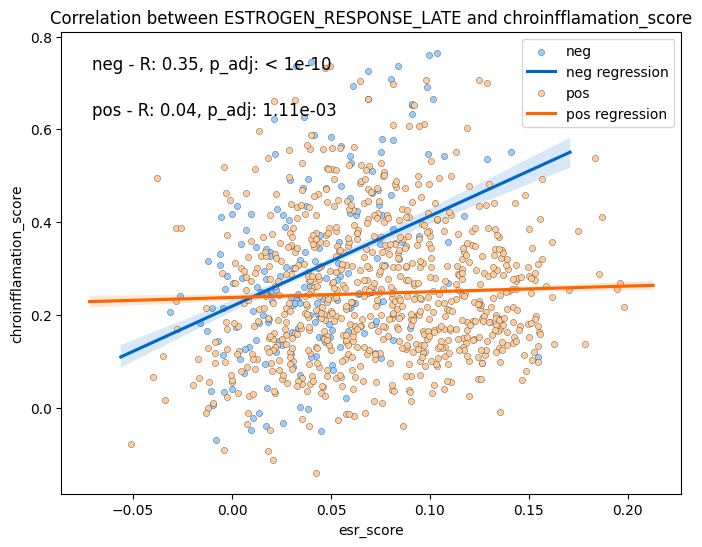

/var/folders/37/xlq517ls2276293h4xc51ydc0000gn/T/ipykernel_51609/418426321.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  correlation_results = df.groupby(biotin_col).apply(lambda group: pearsonr(group[x_score], group[score_name]))
/var/folders/37/xlq517ls2276293h4xc51ydc0000gn/T/ipykernel_51609/418426321.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  correlation_results = df.groupby(biotin_col).apply(lambda group: pearsonr(group[x_score], group[score_name]))
/var/folders/37/xlq517ls2276293h4xc51

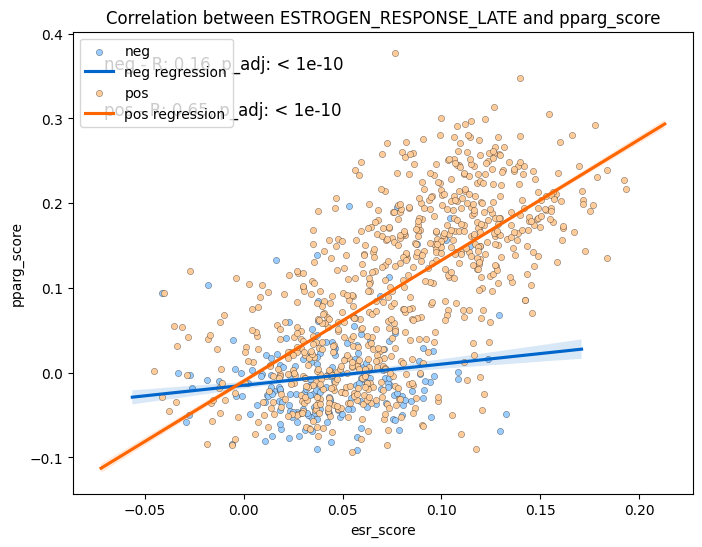

/var/folders/37/xlq517ls2276293h4xc51ydc0000gn/T/ipykernel_51609/418426321.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  correlation_results = df.groupby(biotin_col).apply(lambda group: pearsonr(group[x_score], group[score_name]))
/var/folders/37/xlq517ls2276293h4xc51ydc0000gn/T/ipykernel_51609/418426321.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  correlation_results = df.groupby(biotin_col).apply(lambda group: pearsonr(group[x_score], group[score_name]))
/var/folders/37/xlq517ls2276293h4xc51

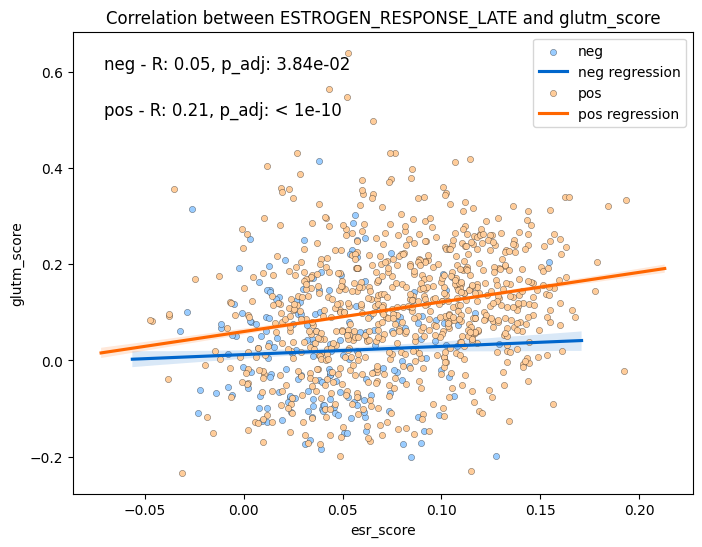

/var/folders/37/xlq517ls2276293h4xc51ydc0000gn/T/ipykernel_51609/418426321.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  correlation_results = df.groupby(biotin_col).apply(lambda group: pearsonr(group[x_score], group[score_name]))
/var/folders/37/xlq517ls2276293h4xc51ydc0000gn/T/ipykernel_51609/418426321.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  correlation_results = df.groupby(biotin_col).apply(lambda group: pearsonr(group[x_score], group[score_name]))
/var/folders/37/xlq517ls2276293h4xc51

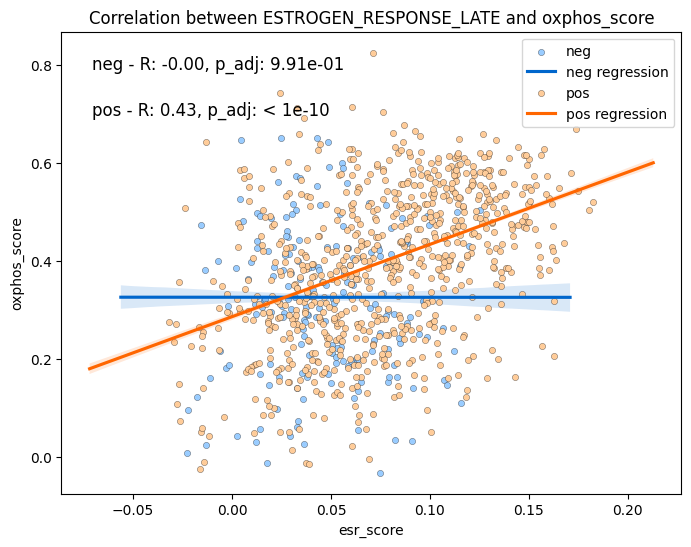

/var/folders/37/xlq517ls2276293h4xc51ydc0000gn/T/ipykernel_51609/418426321.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  correlation_results = df.groupby(biotin_col).apply(lambda group: pearsonr(group[x_score], group[score_name]))
/var/folders/37/xlq517ls2276293h4xc51ydc0000gn/T/ipykernel_51609/418426321.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  correlation_results = df.groupby(biotin_col).apply(lambda group: pearsonr(group[x_score], group[score_name]))
/var/folders/37/xlq517ls2276293h4xc51

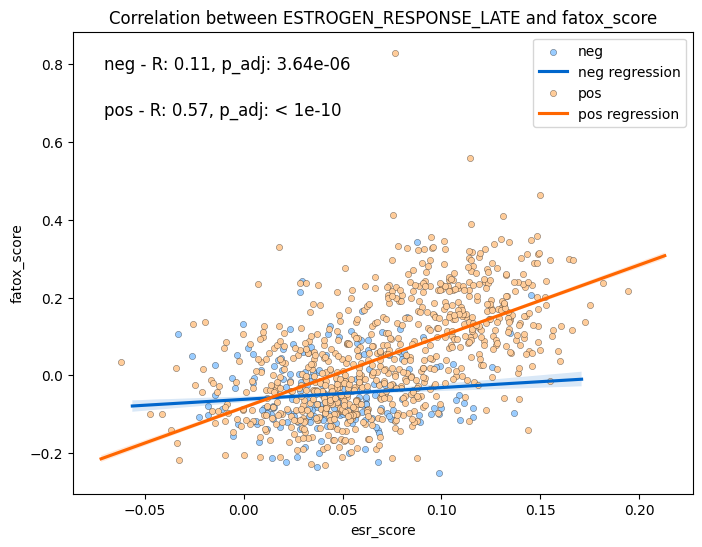

/var/folders/37/xlq517ls2276293h4xc51ydc0000gn/T/ipykernel_51609/418426321.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  correlation_results = df.groupby(biotin_col).apply(lambda group: pearsonr(group[x_score], group[score_name]))
/var/folders/37/xlq517ls2276293h4xc51ydc0000gn/T/ipykernel_51609/418426321.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  correlation_results = df.groupby(biotin_col).apply(lambda group: pearsonr(group[x_score], group[score_name]))
/var/folders/37/xlq517ls2276293h4xc51

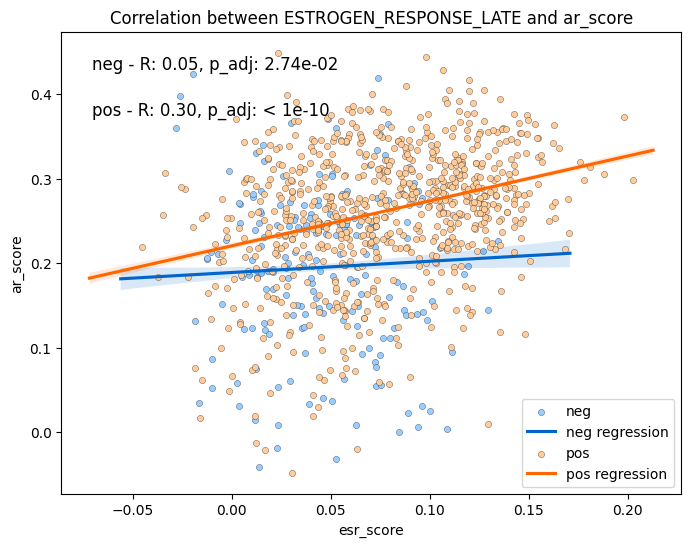

/var/folders/37/xlq517ls2276293h4xc51ydc0000gn/T/ipykernel_51609/418426321.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  correlation_results = df.groupby(biotin_col).apply(lambda group: pearsonr(group[x_score], group[score_name]))
/var/folders/37/xlq517ls2276293h4xc51ydc0000gn/T/ipykernel_51609/418426321.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  correlation_results = df.groupby(biotin_col).apply(lambda group: pearsonr(group[x_score], group[score_name]))
/var/folders/37/xlq517ls2276293h4xc51

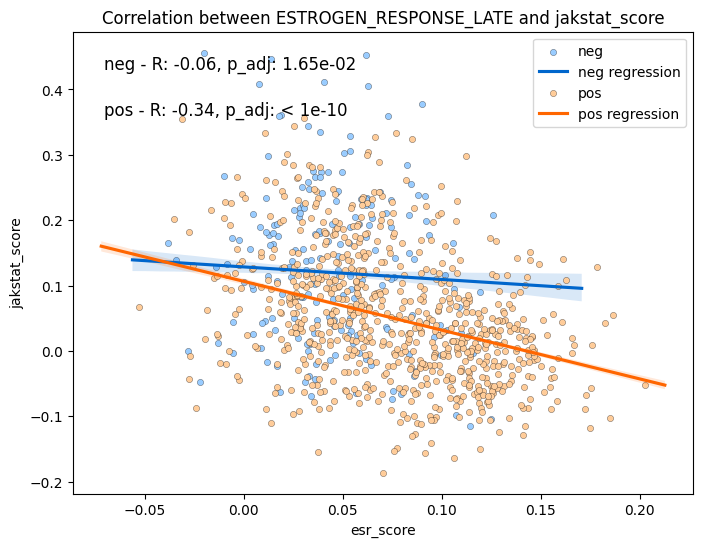

/var/folders/37/xlq517ls2276293h4xc51ydc0000gn/T/ipykernel_51609/418426321.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  correlation_results = df.groupby(biotin_col).apply(lambda group: pearsonr(group[x_score], group[score_name]))
/var/folders/37/xlq517ls2276293h4xc51ydc0000gn/T/ipykernel_51609/418426321.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  correlation_results = df.groupby(biotin_col).apply(lambda group: pearsonr(group[x_score], group[score_name]))
/var/folders/37/xlq517ls2276293h4xc51

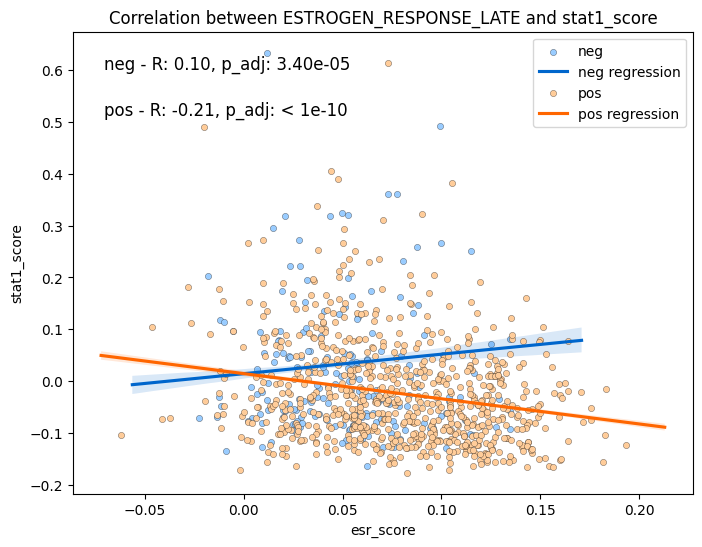

/var/folders/37/xlq517ls2276293h4xc51ydc0000gn/T/ipykernel_51609/418426321.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  correlation_results = df.groupby(biotin_col).apply(lambda group: pearsonr(group[x_score], group[score_name]))
/var/folders/37/xlq517ls2276293h4xc51ydc0000gn/T/ipykernel_51609/418426321.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  correlation_results = df.groupby(biotin_col).apply(lambda group: pearsonr(group[x_score], group[score_name]))
/var/folders/37/xlq517ls2276293h4xc51

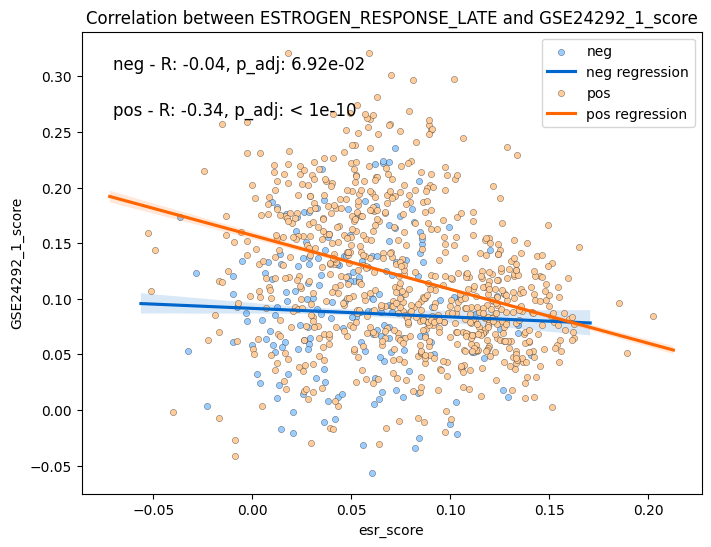

/var/folders/37/xlq517ls2276293h4xc51ydc0000gn/T/ipykernel_51609/418426321.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  correlation_results = df.groupby(biotin_col).apply(lambda group: pearsonr(group[x_score], group[score_name]))
/var/folders/37/xlq517ls2276293h4xc51ydc0000gn/T/ipykernel_51609/418426321.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  correlation_results = df.groupby(biotin_col).apply(lambda group: pearsonr(group[x_score], group[score_name]))
/var/folders/37/xlq517ls2276293h4xc51

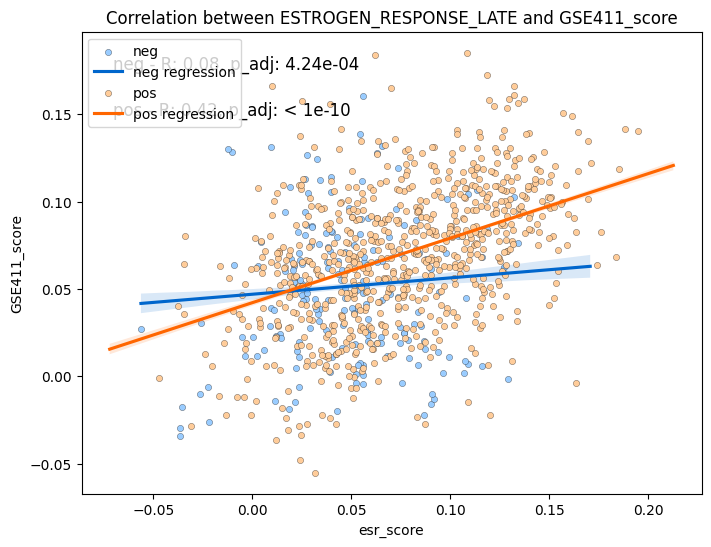

/var/folders/37/xlq517ls2276293h4xc51ydc0000gn/T/ipykernel_51609/418426321.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  correlation_results = df.groupby(biotin_col).apply(lambda group: pearsonr(group[x_score], group[score_name]))
/var/folders/37/xlq517ls2276293h4xc51ydc0000gn/T/ipykernel_51609/418426321.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  correlation_results = df.groupby(biotin_col).apply(lambda group: pearsonr(group[x_score], group[score_name]))
/var/folders/37/xlq517ls2276293h4xc51

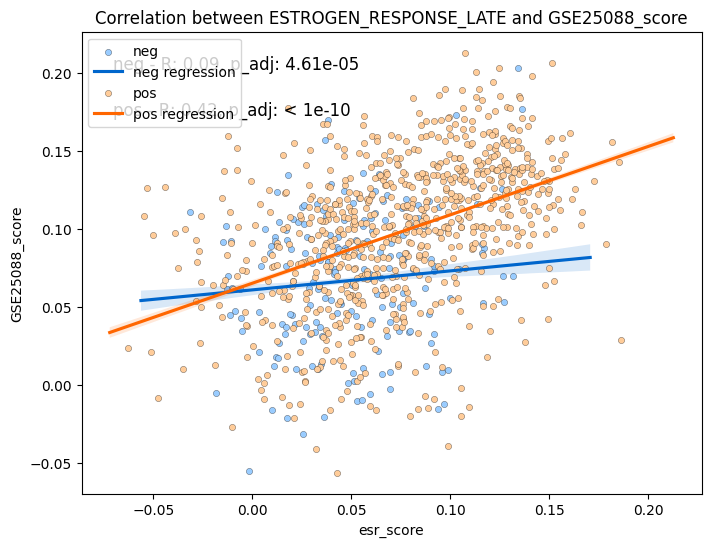

/var/folders/37/xlq517ls2276293h4xc51ydc0000gn/T/ipykernel_51609/418426321.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  correlation_results = df.groupby(biotin_col).apply(lambda group: pearsonr(group[x_score], group[score_name]))
/var/folders/37/xlq517ls2276293h4xc51ydc0000gn/T/ipykernel_51609/418426321.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  correlation_results = df.groupby(biotin_col).apply(lambda group: pearsonr(group[x_score], group[score_name]))
/var/folders/37/xlq517ls2276293h4xc51

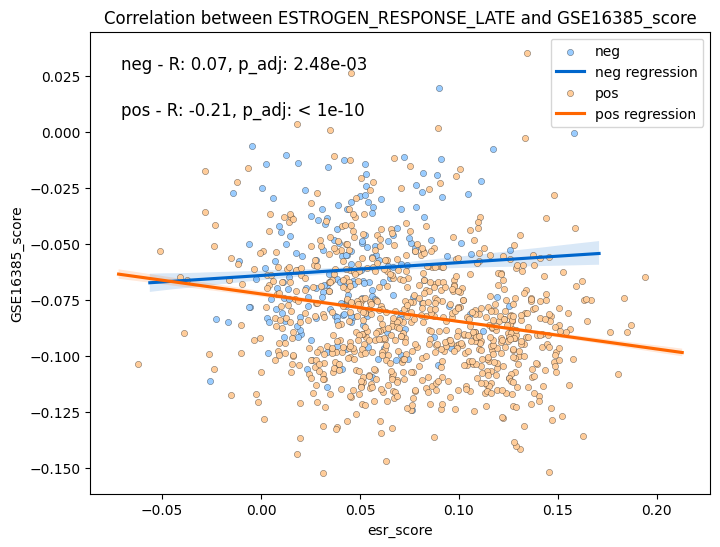

/var/folders/37/xlq517ls2276293h4xc51ydc0000gn/T/ipykernel_51609/418426321.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  correlation_results = df.groupby(biotin_col).apply(lambda group: pearsonr(group[x_score], group[score_name]))
/var/folders/37/xlq517ls2276293h4xc51ydc0000gn/T/ipykernel_51609/418426321.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  correlation_results = df.groupby(biotin_col).apply(lambda group: pearsonr(group[x_score], group[score_name]))
/var/folders/37/xlq517ls2276293h4xc51

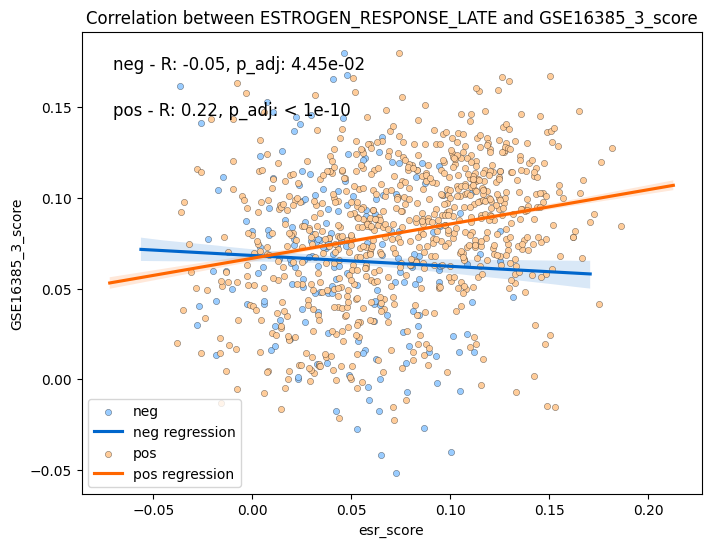

/var/folders/37/xlq517ls2276293h4xc51ydc0000gn/T/ipykernel_51609/418426321.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  correlation_results = df.groupby(biotin_col).apply(lambda group: pearsonr(group[x_score], group[score_name]))
/var/folders/37/xlq517ls2276293h4xc51ydc0000gn/T/ipykernel_51609/418426321.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  correlation_results = df.groupby(biotin_col).apply(lambda group: pearsonr(group[x_score], group[score_name]))
/var/folders/37/xlq517ls2276293h4xc51

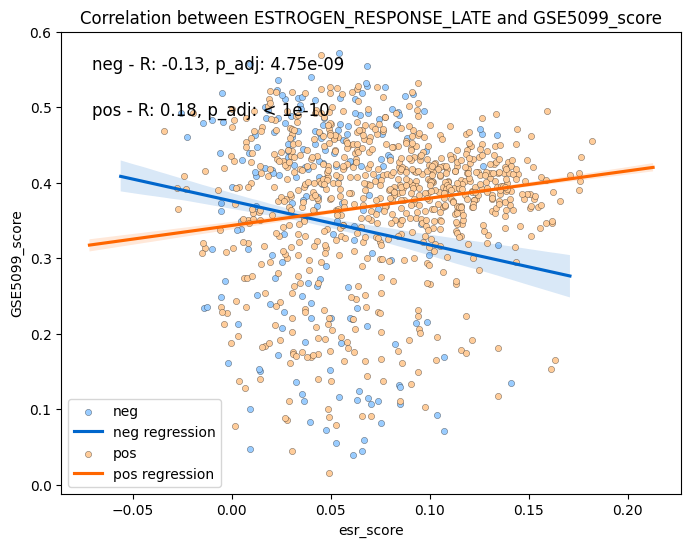

/var/folders/37/xlq517ls2276293h4xc51ydc0000gn/T/ipykernel_51609/418426321.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  correlation_results = df.groupby(biotin_col).apply(lambda group: pearsonr(group[x_score], group[score_name]))
/var/folders/37/xlq517ls2276293h4xc51ydc0000gn/T/ipykernel_51609/418426321.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  correlation_results = df.groupby(biotin_col).apply(lambda group: pearsonr(group[x_score], group[score_name]))
/var/folders/37/xlq517ls2276293h4xc51

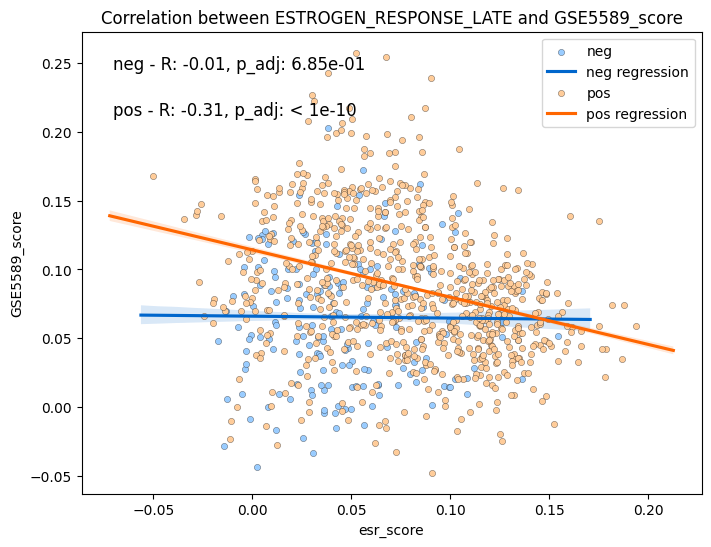

/var/folders/37/xlq517ls2276293h4xc51ydc0000gn/T/ipykernel_51609/418426321.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  correlation_results = df.groupby(biotin_col).apply(lambda group: pearsonr(group[x_score], group[score_name]))
/var/folders/37/xlq517ls2276293h4xc51ydc0000gn/T/ipykernel_51609/418426321.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  correlation_results = df.groupby(biotin_col).apply(lambda group: pearsonr(group[x_score], group[score_name]))
/var/folders/37/xlq517ls2276293h4xc51

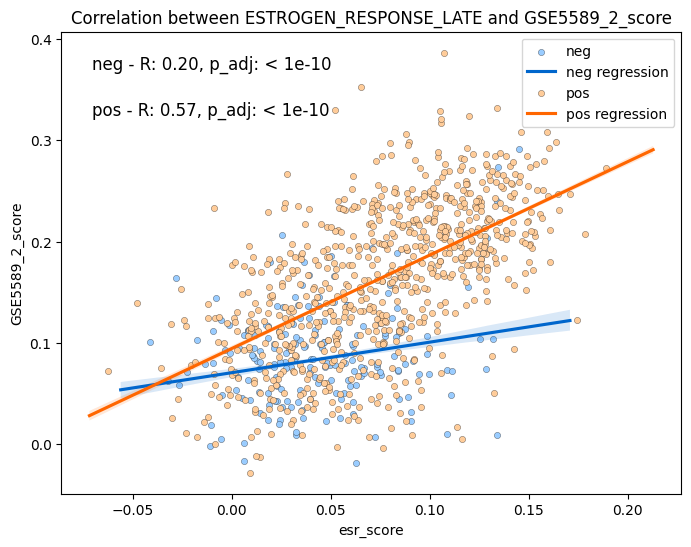

/var/folders/37/xlq517ls2276293h4xc51ydc0000gn/T/ipykernel_51609/418426321.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  correlation_results = df.groupby(biotin_col).apply(lambda group: pearsonr(group[x_score], group[score_name]))
/var/folders/37/xlq517ls2276293h4xc51ydc0000gn/T/ipykernel_51609/418426321.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  correlation_results = df.groupby(biotin_col).apply(lambda group: pearsonr(group[x_score], group[score_name]))
/var/folders/37/xlq517ls2276293h4xc51

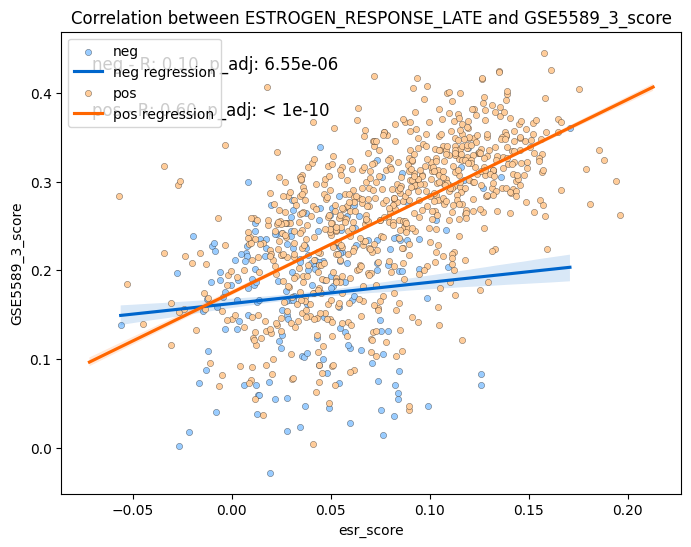

/var/folders/37/xlq517ls2276293h4xc51ydc0000gn/T/ipykernel_51609/418426321.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  correlation_results = df.groupby(biotin_col).apply(lambda group: pearsonr(group[x_score], group[score_name]))
/var/folders/37/xlq517ls2276293h4xc51ydc0000gn/T/ipykernel_51609/418426321.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  correlation_results = df.groupby(biotin_col).apply(lambda group: pearsonr(group[x_score], group[score_name]))
/var/folders/37/xlq517ls2276293h4xc51

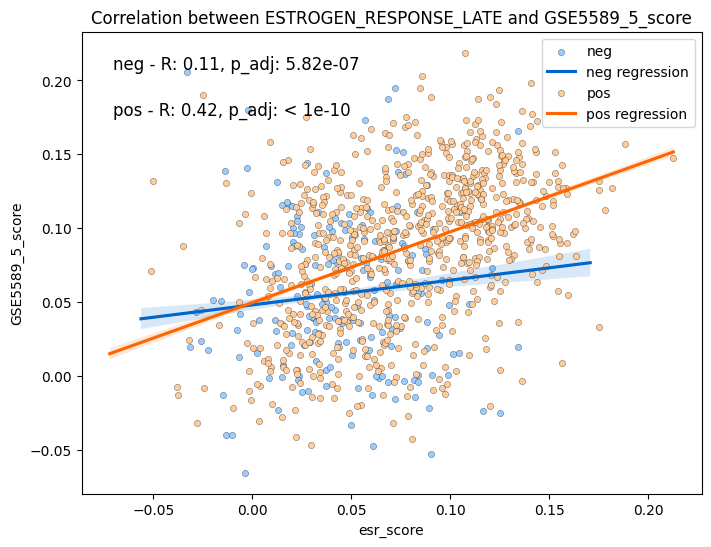

/var/folders/37/xlq517ls2276293h4xc51ydc0000gn/T/ipykernel_51609/418426321.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  correlation_results = df.groupby(biotin_col).apply(lambda group: pearsonr(group[x_score], group[score_name]))
/var/folders/37/xlq517ls2276293h4xc51ydc0000gn/T/ipykernel_51609/418426321.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  correlation_results = df.groupby(biotin_col).apply(lambda group: pearsonr(group[x_score], group[score_name]))
/var/folders/37/xlq517ls2276293h4xc51

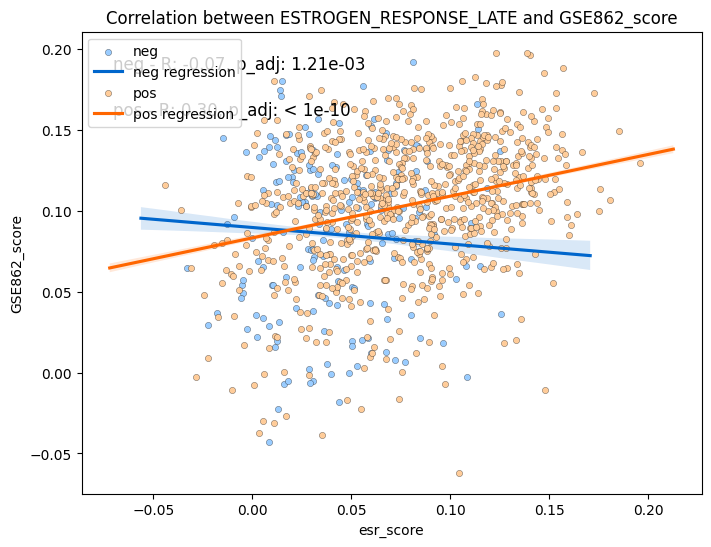

In [214]:
#all_plot_correlation(adata, 'il10_score', dot_size=2, dot_edge_width=0.2, colors={'pos': ('#ffcc99', '#ff6600'), 'neg': ('#99ccff', '#0066cc')}, save_path='../pathway_corraletion/overlapped/il10_score.pdf')
#all_plot_correlation(adata, 'm2_score', dot_size=2, dot_edge_width=0.2, colors={'pos': ('#ffcc99', '#ff6600'), 'neg': ('#99ccff', '#0066cc')}, save_path='../pathway_corraletion/overlapped/m2_score.pdf')
#all_plot_correlation(adata, 'tgfb_score', dot_size=2, dot_edge_width=0.2, colors={'pos': ('#ffcc99', '#ff6600'), 'neg': ('#99ccff', '#0066cc')}, save_path='../pathway_corraletion/overlapped/tgfb_score.pdf')
#all_plot_correlation(adata, 'nfkb_score', dot_size=2, dot_edge_width=0.2, colors={'pos': ('#ffcc99', '#ff6600'), 'neg': ('#99ccff', '#0066cc')}, save_path='../pathway_corraletion/overlapped/nfkb_score.pdf')
all_plot_correlation(adata, 'chroinfflamation_score', dot_size=2, dot_edge_width=0.2, colors={'pos': ('#ffcc99', '#ff6600'), 'neg': ('#99ccff', '#0066cc')}, save_path='../pathway_corraletion/overlapped/chroinfflamation_score.pdf')
all_plot_correlation(adata, 'pparg_score', dot_size=2, dot_edge_width=0.2, colors={'pos': ('#ffcc99', '#ff6600'), 'neg': ('#99ccff', '#0066cc')}, save_path='../pathway_corraletion/overlapped/pparg_score.pdf')
all_plot_correlation(adata, 'glutm_score', dot_size=2, dot_edge_width=0.2, colors={'pos': ('#ffcc99', '#ff6600'), 'neg': ('#99ccff', '#0066cc')}, save_path='../pathway_corraletion/overlapped/glutm_score.pdf')
all_plot_correlation(adata, 'oxphos_score', dot_size=2, dot_edge_width=0.2, colors={'pos': ('#ffcc99', '#ff6600'), 'neg': ('#99ccff', '#0066cc')}, save_path='../pathway_corraletion/overlapped/oxphos_score.pdf')
all_plot_correlation(adata, 'fatox_score', dot_size=2, dot_edge_width=0.2, colors={'pos': ('#ffcc99', '#ff6600'), 'neg': ('#99ccff', '#0066cc')}, save_path='../pathway_corraletion/overlapped/fatox_score.pdf')
#all_plot_correlation(adata, 'angio_score', dot_size=2, dot_edge_width=0.2, colors={'pos': ('#ffcc99', '#ff6600'), 'neg': ('#99ccff', '#0066cc')}, save_path='../pathway_corraletion/overlapped/angio_score.pdf')
#all_plot_correlation(adata, 'vegf_score', dot_size=2, dot_edge_width=0.2, colors={'pos': ('#ffcc99', '#ff6600'), 'neg': ('#99ccff', '#0066cc')}, save_path='../pathway_corraletion/overlapped/vegf_score.pdf')
all_plot_correlation(adata, 'ar_score', dot_size=2, dot_edge_width=0.2, colors={'pos': ('#ffcc99', '#ff6600'), 'neg': ('#99ccff', '#0066cc')}, save_path='../pathway_corraletion/overlapped/ar_score.pdf')
all_plot_correlation(adata, 'jakstat_score', dot_size=2, dot_edge_width=0.2, colors={'pos': ('#ffcc99', '#ff6600'), 'neg': ('#99ccff', '#0066cc')}, save_path='../pathway_corraletion/overlapped/jakstat_score.pdf')
#all_plot_correlation(adata, 'tnfr1_score', dot_size=2, dot_edge_width=0.2, colors={'pos': ('#ffcc99', '#ff6600'), 'neg': ('#99ccff', '#0066cc')}, save_path='../pathway_corraletion/overlapped/tnfr1_score.pdf')
all_plot_correlation(adata, 'stat1_score', dot_size=2, dot_edge_width=0.2, colors={'pos': ('#ffcc99', '#ff6600'), 'neg': ('#99ccff', '#0066cc')}, save_path='../pathway_corraletion/overlapped/stat1_score.pdf')
#all_plot_correlation(adata, 'nfkb_score', dot_size=2, dot_edge_width=0.2, colors={'pos': ('#ffcc99', '#ff6600'), 'neg': ('#99ccff', '#0066cc')}, save_path='../pathway_corraletion/overlapped/nfkb_score.pdf')
#all_plot_correlation(adata, 'GSE22935_1_score', dot_size=2, dot_edge_width=0.2, colors={'pos': ('#ffcc99', '#ff6600'), 'neg': ('#99ccff', '#0066cc')}, save_path='../pathway_corraletion/overlapped/GSE22935_1_score.pdf')
all_plot_correlation(adata, 'GSE24292_1_score', dot_size=2, dot_edge_width=0.2, colors={'pos': ('#ffcc99', '#ff6600'), 'neg': ('#99ccff', '#0066cc')}, save_path='../pathway_corraletion/overlapped/GSE24292_1_score.pdf')
all_plot_correlation(adata, 'GSE411_score', dot_size=2, dot_edge_width=0.2, colors={'pos': ('#ffcc99', '#ff6600'), 'neg': ('#99ccff', '#0066cc')}, save_path='../pathway_corraletion/overlapped/GSE411_score.pdf')
all_plot_correlation(adata, 'GSE25088_score', dot_size=2, dot_edge_width=0.2, colors={'pos': ('#ffcc99', '#ff6600'), 'neg': ('#99ccff', '#0066cc')}, save_path='../pathway_corraletion/overlapped/GSE25088_score.pdf')
#all_plot_correlation(adata, 'GSE26343_score', dot_size=2, dot_edge_width=0.2, colors={'pos': ('#ffcc99', '#ff6600'), 'neg': ('#99ccff', '#0066cc')}, save_path='../pathway_corraletion/overlapped/GSE26343_score.pdf')
#all_plot_correlation(adata, 'GSE26912_score', dot_size=2, dot_edge_width=0.2, colors={'pos': ('#ffcc99', '#ff6600'), 'neg': ('#99ccff', '#0066cc')}, save_path='../pathway_corraletion/overlapped/GSE26912_score.pdf')
all_plot_correlation(adata, 'GSE16385_score', dot_size=2, dot_edge_width=0.2, colors={'pos': ('#ffcc99', '#ff6600'), 'neg': ('#99ccff', '#0066cc')}, save_path='../pathway_corraletion/overlapped/GSE16385_score.pdf')
all_plot_correlation(adata, 'GSE16385_3_score', dot_size=2, dot_edge_width=0.2, colors={'pos': ('#ffcc99', '#ff6600'), 'neg': ('#99ccff', '#0066cc')}, save_path='../pathway_corraletion/overlapped/GSE16385_3_score.pdf')
#all_plot_correlation(adata, 'GSE45382_score', dot_size=2, dot_edge_width=0.2, colors={'pos': ('#ffcc99', '#ff6600'), 'neg': ('#99ccff', '#0066cc')}, save_path='../pathway_corraletion/overlapped/GSE45382_score.pdf')
all_plot_correlation(adata, 'GSE5099_score', dot_size=2, dot_edge_width=0.2, colors={'pos': ('#ffcc99', '#ff6600'), 'neg': ('#99ccff', '#0066cc')}, save_path='../pathway_corraletion/overlapped/GSE5099_score.pdf')
all_plot_correlation(adata, 'GSE5589_score', dot_size=2, dot_edge_width=0.2, colors={'pos': ('#ffcc99', '#ff6600'), 'neg': ('#99ccff', '#0066cc')}, save_path='../pathway_corraletion/overlapped/GSE5589_score.pdf')
all_plot_correlation(adata, 'GSE5589_2_score', dot_size=2, dot_edge_width=0.2, colors={'pos': ('#ffcc99', '#ff6600'), 'neg': ('#99ccff', '#0066cc')}, save_path='../pathway_corraletion/overlapped/GSE5589_2_score.pdf')
all_plot_correlation(adata, 'GSE5589_3_score', dot_size=2, dot_edge_width=0.2, colors={'pos': ('#ffcc99', '#ff6600'), 'neg': ('#99ccff', '#0066cc')}, save_path='../pathway_corraletion/overlapped/GSE5589_3_score.pdf')
#all_plot_correlation(adata, 'GSE5589_4_score', dot_size=2, dot_edge_width=0.2, colors={'pos': ('#ffcc99', '#ff6600'), 'neg': ('#99ccff', '#0066cc')}, save_path='../pathway_corraletion/overlapped/GSE5589_4_score.pdf')
all_plot_correlation(adata, 'GSE5589_5_score', dot_size=2, dot_edge_width=0.2, colors={'pos': ('#ffcc99', '#ff6600'), 'neg': ('#99ccff', '#0066cc')}, save_path='../pathway_corraletion/overlapped/GSE5589_5_score.pdf')
all_plot_correlation(adata, 'GSE862_score', dot_size=2, dot_edge_width=0.2, colors={'pos': ('#ffcc99', '#ff6600'), 'neg': ('#99ccff', '#0066cc')}, save_path='../pathway_corraletion/overlapped/GSE862_score.pdf')
#all_plot_correlation(adata, 'GSE1925_score', dot_size=2, dot_edge_width=0.2, colors={'pos': ('#ffcc99', '#ff6600'), 'neg': ('#99ccff', '#0066cc')}, save_path='../pathway_corraletion/overlapped/GSE1925_score.pdf')

In [276]:
#pathway score per patients
import scanpy as sc
import pandas as pd

# Step 1: Calculate the pathway scores for each cell
gene_list_ppar=['Acaa1a', 'Acaa1b', 'Acadl', 'Acadm', 'Acox1', 'Acox2', 'Acox3', 'Acsbg1', 'Acsbg2', 'Acsl1', 'Acsl3', 'Acsl4', 'Acsl5', 'Acsl6', 'Adipoq', 'Angptl4', 'Apoa1', 'Apoa2', 'Apoa5', 'Apoc3', 'Aqp7', 'Cd36', 'Cpt1a', 'Cpt1b', 'Cpt1c', 'Cpt2', 'Cyp27a1', 'Cyp4a10', 'Cyp4a12a', 'Cyp4a12b', 'Cyp4a14', 'Cyp4a29', 'Cyp4a30b', 'Cyp4a31', 'Cyp4a32', 'Cyp7a1', 'Cyp8b1', 'Dbi', 'Ehhadh', 'Fabp1', 'Fabp2', 'Fabp3', 'Fabp4', 'Fabp5', 'Fabp6', 'Fabp7', 'Fads2', 'Gk', 'Gk2', 'Hmgcs2', 'Ilk', 'Lpl', 'Me1', 'Mmp1a', 'Mmp1b', 'Nr1h3', 'Olr1', 'Pck1', 'Pck2', 'Pdpk1', 'Plin1', 'Pltp', 'Ppara', 'Ppard', 'Pparg', 'Rxra', 'Rxrb', 'Rxrg', 'Scd1', 'Scd2', 'Scd3', 'Scd4', 'Scp2', 'Slc27a1', 'Slc27a2', 'Slc27a4', 'Slc27a5', 'Slc27a6', 'Sorbs1', 'Ubc', 'Ucp1']
sc.tl.score_genes(adata_subset, gene_list_ppar, score_name='ppar_score')

# Step 2: Aggregate the scores for each sample
# Group the data by sample ID and calculate the mean score for each sample
sample_scores = adata_subset.obs.groupby('sample')['mito_score'].mean()

# Convert the result to a DataFrame
sample_scores_df = sample_scores.reset_index()

# Step 3: Export the aggregated scores to a CSV file
sample_scores_df.to_csv('../pathway_corraletion/ppar_score_per_sample.csv', index=False)

print("Pathway scores per sample have been saved to 'mito_score_per_sample.csv'.")

/Users/fengshuoliu/anaconda3/lib/python3.11/site-packages/scanpy/tools/_score_genes.py:178: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[score_name] = pd.Series(


Pathway scores per sample have been saved to 'mito_score_per_sample.csv'.


/var/folders/37/xlq517ls2276293h4xc51ydc0000gn/T/ipykernel_51609/4284415600.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sample_scores = adata_subset.obs.groupby('sample')['mito_score'].mean()


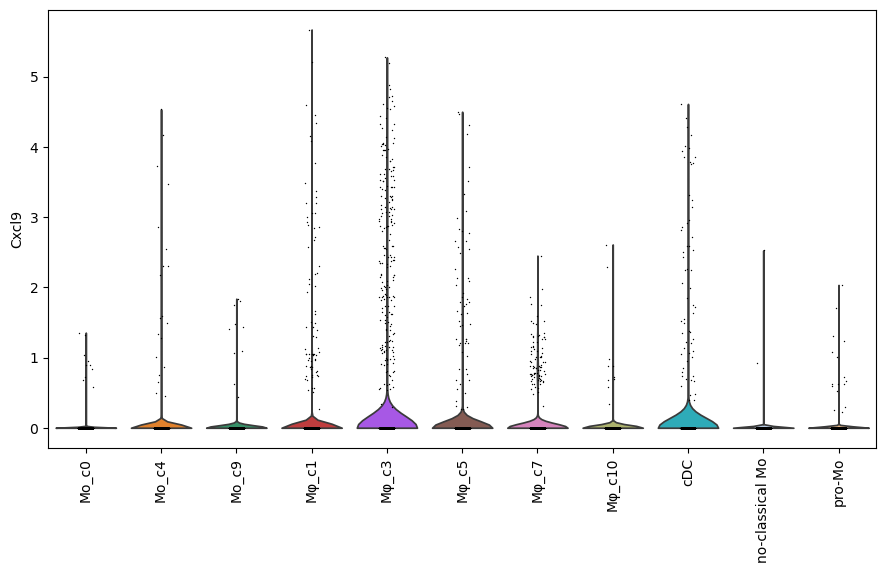

In [158]:
## rc_context is used for the figure size, in this case 4x4
with plt.rc_context({'figure.figsize': (9, 6)}):
    sc.pl.violin(adata, keys=['Cxcl9'], groupby='celltype_C',rotation=90, #,save='Cx3cr1_violin_plot_tissue.pdf'
                )

In [73]:
#REACTOME_SIGNALING_BY_FGFR2
gene_list=['Braf', 'Cbl', 'Fgf1', 'Fgf10', 'Fgf16', 'Fgf17', 'Fgf18', 'Fgf2', 'Fgf20', 'Fgf22', 'Fgf23', 'Fgf3', 'Fgf4', 'Fgf5', 'Fgf6', 'Fgf7', 'Fgf8', 'Fgf9', 'Fgfbp1', 'Fgfbp3', 'Frs2', 'Frs3', 'Gab1', 'Grb2', 'Gtf2f1', 'Gtf2f2', 'Hnrnpa1', 'Hras', 'Kras', 'Mapk1', 'Mapk3', 'Mknk1', 'Ncbp1', 'Ncbp2', 'Pik3ca', 'Pik3r1', 'Plcg1', 'Polr2a', 'Polr2b', 'Polr2c', 'Polr2d', 'Polr2e', 'Polr2f', 'Polr2g', 'Polr2h', 'Polr2i', 'Polr2k', 'Polr2l', 'Ppp2ca', 'Ppp2cb', 'Ppp2r1a', 'Ptbp1', 'Ptpn11', 'Rps27a', 'Shc1', 'Sos1', 'Spry2', 'Src', 'Uba52', 'Ubb', 'Ubc']
sc.tl.score_genes(adata, gene_list, score_name='REACTOME_SIGNALING_BY_FGFR2')

#fgf
gene_list=['Braf', 'Cbl', 'Fgf1', 'Fgf10', 'Fgf16', 'Fgf17', 'Fgf18', 'Fgf2', 'Fgf20', 'Fgf22', 'Fgf23', 'Fgf3', 'Fgf4', 'Fgf5', 'Fgf6', 'Fgf7', 'Fgf8', 'Fgf9', 'Frs2', 'Grb2', 'Mapk1', 'Mapk3', 'Mknk1', 'Ppp2ca', 'Ppp2cb', 'Ppp2r1a', 'Ptpn11', 'Rps27a', 'Spry2', 'Src', 'Uba52', 'Ubb', 'Ubc']
sc.tl.score_genes(adata, gene_list, score_name='REACTOME_SIGNALING_BY_FGFR2')

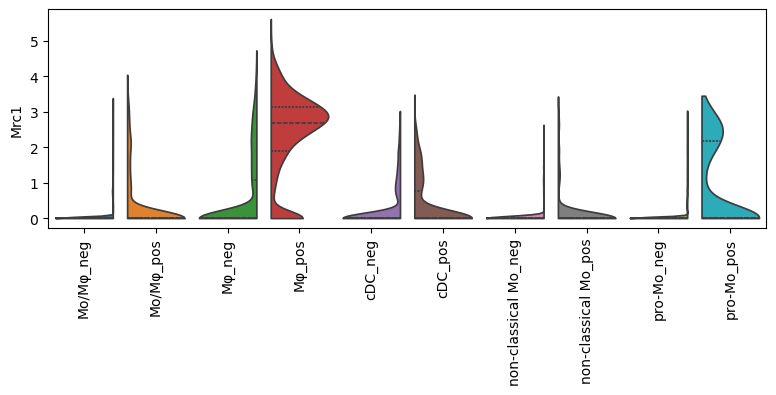

In [14]:
import scanpy as sc
import matplotlib.pyplot as plt

# Ensure 'biotin' is a categorical variable
adata.obs['biotin'] = adata.obs['biotin'].astype('category')

# Create a new variable combining celltype and biotin status
adata.obs['celltype_biotin'] = adata.obs['celltype_B'].astype(str) + "_" + adata.obs['biotin'].astype(str)

# Plot using the newly created variable to show split violins
with plt.rc_context({'figure.figsize': (8, 3)}):
    sc.pl.violin(
        adata,
        keys='Mrc1',                     # Gene to plot
        groupby='celltype_biotin',        # Group by the new combined variable
        rotation=90,                      # Rotate x-axis labels for better readability
        split=True,                       # Enable splitting for the violins
        scale='count',                    # Scale violins to have the same width
        stripplot=False,                  # Disable strip plot for clarity
        jitter=False,                      # Disable jitter to keep the plot clean
        inner="quartile"
        #save='Response_to_Estrogen_AUCell_score_mature_cell_split.pdf'
    )


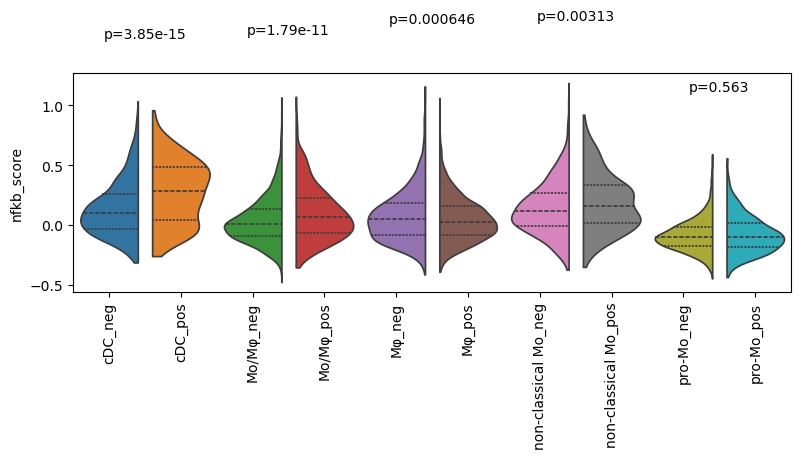

In [18]:
import scanpy as sc
import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np
import pandas as pd

# -------------------------------
# 1. Prepare Data and Variables
# -------------------------------

# Ensure 'biotin' is a categorical variable and set order if desired.
adata.obs['biotin'] = adata.obs['biotin'].astype('category')
# (Optional) If you want a specific order (e.g., "Negative" then "Positive"):
# adata.obs['biotin'].cat.set_categories(["Negative", "Positive"], inplace=True)

# Create a new variable combining cell type (from celltype_B) and biotin status.
adata.obs['celltype_biotin'] = adata.obs['celltype_B'].astype(str) + "_" + adata.obs['biotin'].astype(str)

# -------------------------------
# 2. Compute p-values for Each Cell Type Pair
# -------------------------------
# We'll compute a Welch's t‑test p‑value for each cell type (from celltype_B) comparing the two biotin groups.
celltype_pvals = {}

# Get the unique cell types from celltype_B.
unique_celltypes = adata.obs['celltype_B'].unique()

for cell in unique_celltypes:
    cell_labels = [lbl for lbl in adata.obs['celltype_biotin'].unique() if lbl.startswith(str(cell) + "_")]
    if len(cell_labels) != 2:
        continue

    group_values = {}
    for group in adata.obs['biotin'].cat.categories:
        mask = (adata.obs['celltype_B'] == cell) & (adata.obs['biotin'] == group)
        # CORRECTED: Access from adata.obs
        values = adata.obs.loc[mask, 'nfkb_score'].values.flatten()  # Fix here
        if values.size > 0:
            group_values[group] = values

    if len(group_values) != 2:
        continue

    groups = list(group_values.keys())
    data1 = group_values[groups[0]]
    data2 = group_values[groups[1]]
    
    # Perform Welch's t-test comparing the two biotin groups.
    t_stat, p_val = stats.ttest_ind(data1, data2, equal_var=False)
    celltype_pvals[cell] = p_val

# -------------------------------
# 3. Reorder Categories by Ascending p-values
# -------------------------------
# Sort the cell types by their computed p-values (lowest first).
sorted_celltypes = [cell for cell, p in sorted(celltype_pvals.items(), key=lambda x: x[1])]

# Get the original order of the biotin groups.
biotin_order = list(adata.obs['biotin'].cat.categories)

# Construct the new combined order for "celltype_biotin".
new_order = []
for cell in sorted_celltypes:
    for group in biotin_order:
        new_order.append(f"{cell}_{group}")

# Update the categorical order of 'celltype_biotin'.
adata.obs['celltype_biotin'] = pd.Categorical(adata.obs['celltype_biotin'], categories=new_order, ordered=True)

# -------------------------------
# 4. Plot the Violin Plot (Reordered)
# -------------------------------
with plt.rc_context({'figure.figsize': (8, 3)}):
    sc.pl.violin(
        adata,
        keys='nfkb_score',                     # Gene to plot.
        groupby='celltype_biotin',         # Group by the new combined variable (now reordered).
        rotation=90,                      # Rotate x-axis labels for better readability.
        split=True,                       # Enable splitting for the violins.
        stripplot=False,                  # Disable strip plot for clarity.
        jitter=False,                     # Disable jitter to keep the plot clean.
        show=False,                        # Do not show immediately (annotations will be added).
        inner="quart"
    )
    ax = plt.gca()  # Get the current Axes instance.

# Retrieve the (now reordered) x-axis tick labels.
tick_labels = [tick.get_text() for tick in ax.get_xticklabels()]

# -------------------------------
# 5. Annotate Each Pair with p-values
# -------------------------------
# Loop over each sorted cell type and annotate the corresponding paired split violins.
for cell in sorted_celltypes:
    cell_labels = [lbl for lbl in new_order if lbl.startswith(str(cell) + "_")]
    if len(cell_labels) != 2:
        continue

    indices = [tick_labels.index(lbl) for lbl in cell_labels if lbl in tick_labels]
    if len(indices) != 2:
        continue
    x_pos = np.mean(indices)
    
    group_values = {}
    for group in biotin_order:
        mask = (adata.obs['celltype_B'] == cell) & (adata.obs['biotin'] == group)
        # CORRECTED: Fix typo and access from adata.obs
        values = adata.obs.loc[mask, 'nfkb_score'].values.flatten()  # Fix here
        if values.size > 0:
            group_values[group] = values

    if len(group_values) != 2:
        continue

    groups = list(group_values.keys())
    data1 = group_values[groups[0]]
    data2 = group_values[groups[1]]
    
    # Use the Mann–Whitney U test again for annotation (this p-value should match the stored one)
    u_stat, p_val = stats.mannwhitneyu(data1, data2, alternative='two-sided')
    
    # Determine the highest Anxa2 value for positioning the annotation.
    max_y = max(data1.max(), data2.max())
    
    # Annotate the plot with the p-value text (positioned above the violins).
    ax.text(x_pos, max_y + 0.5, f"p={p_val:.3g}", ha='center', va='bottom', fontsize=10, color='black')

# -------------------------------
# 6. Show the Final Plot
# -------------------------------
plt.show()


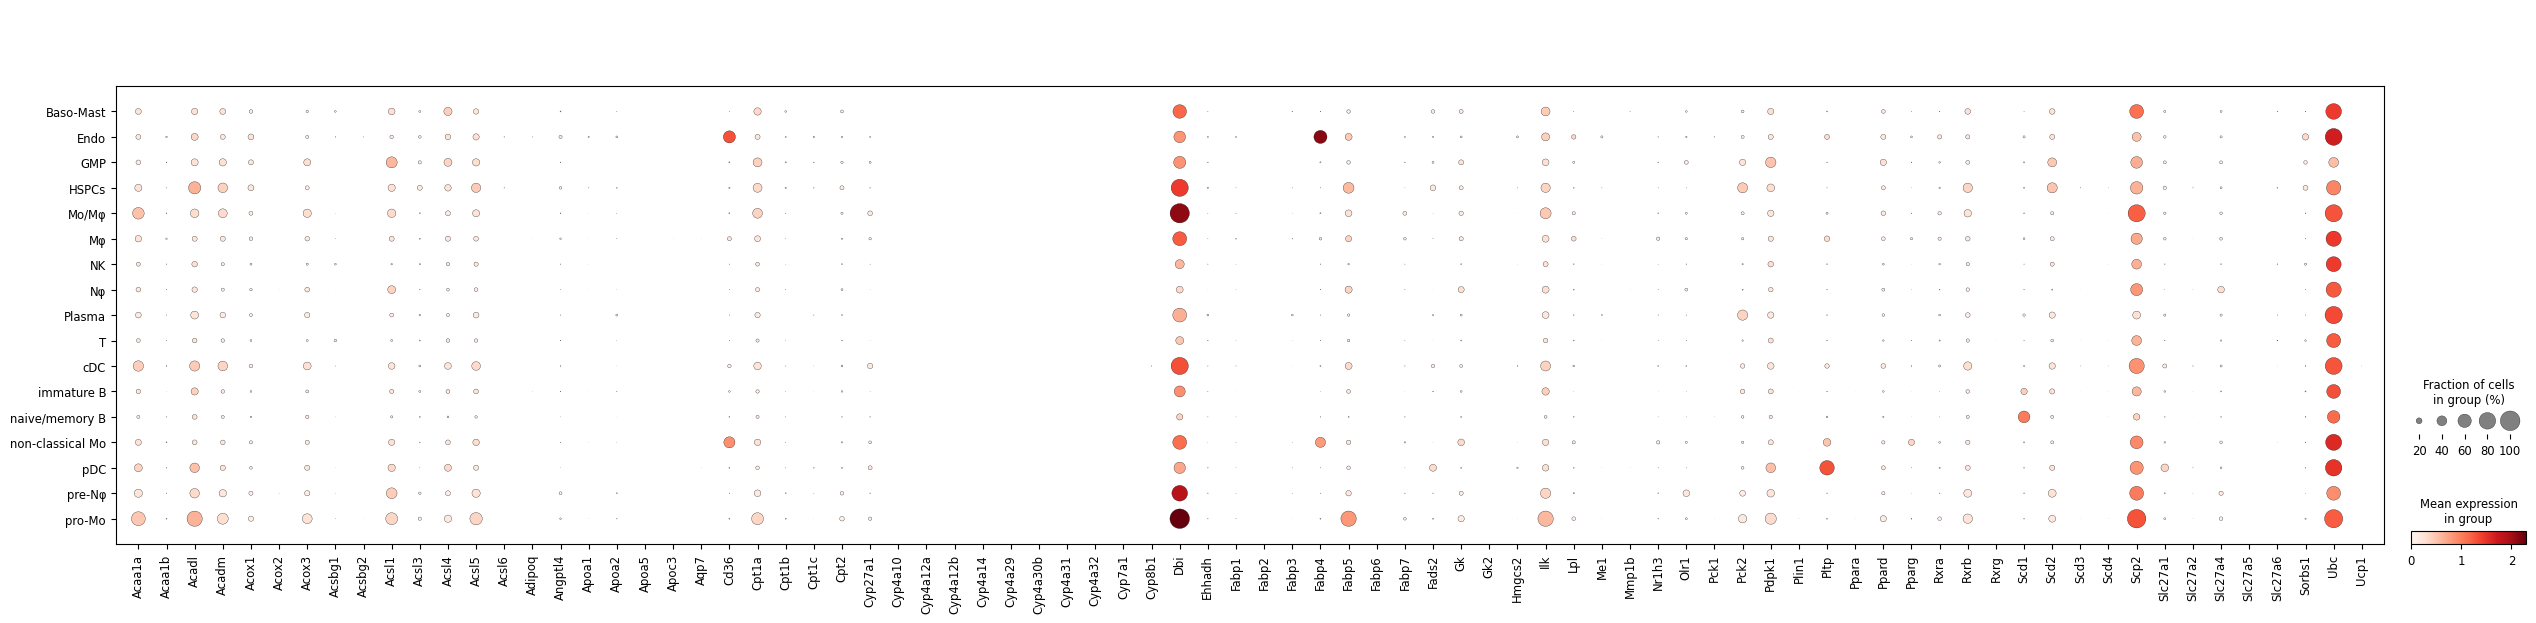

In [248]:
subset_values = ["neg"]
adata_subset = adata[adata.obs['biotin'].isin(subset_values), :]
## rc_context is used for the figure size, in this case 4x4
with plt.rc_context({'figure.figsize': (9, 6)}):
    sc.pl.dotplot(adata_subset,['Acaa1a', 'Acaa1b', 'Acadl', 'Acadm', 'Acox1', 'Acox2', 'Acox3', 'Acsbg1', 'Acsbg2', 'Acsl1', 'Acsl3', 'Acsl4', 'Acsl5', 'Acsl6', 'Adipoq', 'Angptl4', 'Apoa1', 'Apoa2', 'Apoa5', 'Apoc3', 'Aqp7', 'Cd36', 'Cpt1a', 'Cpt1b', 'Cpt1c', 'Cpt2', 'Cyp27a1', 'Cyp4a10', 'Cyp4a12a', 'Cyp4a12b', 'Cyp4a14', 'Cyp4a29', 'Cyp4a30b', 'Cyp4a31', 'Cyp4a32', 'Cyp7a1', 'Cyp8b1', 'Dbi', 'Ehhadh', 'Fabp1', 'Fabp2', 'Fabp3', 'Fabp4', 'Fabp5', 'Fabp6', 'Fabp7', 'Fads2', 'Gk', 'Gk2', 'Hmgcs2', 'Ilk', 'Lpl', 'Me1', 'Mmp1b', 'Nr1h3', 'Olr1', 'Pck1', 'Pck2', 'Pdpk1', 'Plin1', 'Pltp', 'Ppara', 'Ppard', 'Pparg', 'Rxra', 'Rxrb', 'Rxrg', 'Scd1', 'Scd2', 'Scd3', 'Scd4', 'Scp2', 'Slc27a1', 'Slc27a2', 'Slc27a4', 'Slc27a5', 'Slc27a6', 'Sorbs1', 'Ubc', 'Ucp1'], 
                  groupby='celltype_B', save='SAMENT_neg_KEGG_PPAR_SIGNALING_PATHWAY_gene_expression.pdf'
                )

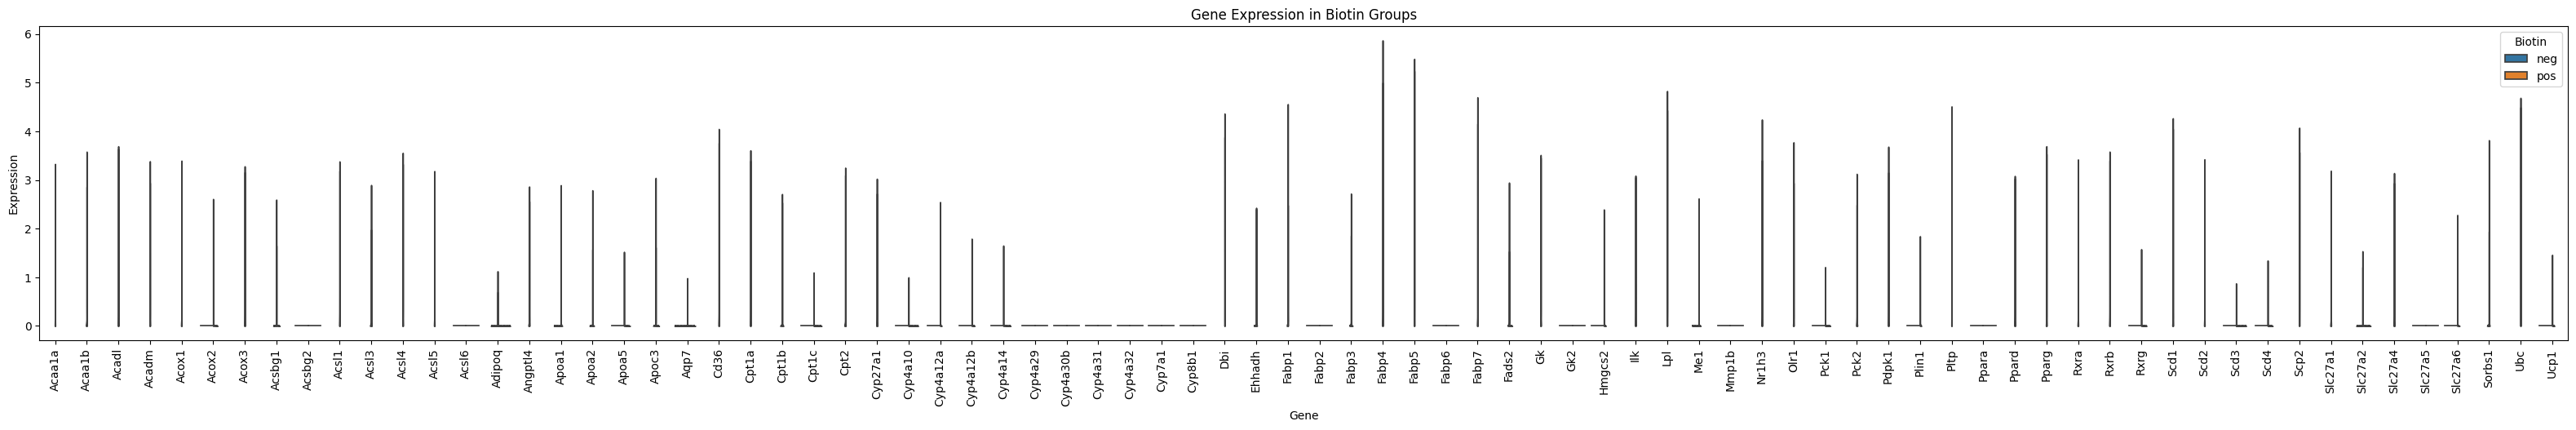

In [252]:
subset_values = ["Mφ"]
adata_subset = adata[adata.obs['celltype_B'].isin(subset_values), :]
import seaborn as sns
import matplotlib.pyplot as plt

# Define the list of genes
genes = ['Acaa1a', 'Acaa1b', 'Acadl', 'Acadm', 'Acox1', 'Acox2', 'Acox3', 'Acsbg1', 'Acsbg2', 'Acsl1', 
         'Acsl3', 'Acsl4', 'Acsl5', 'Acsl6', 'Adipoq', 'Angptl4', 'Apoa1', 'Apoa2', 'Apoa5', 'Apoc3', 
         'Aqp7', 'Cd36', 'Cpt1a', 'Cpt1b', 'Cpt1c', 'Cpt2', 'Cyp27a1', 'Cyp4a10', 'Cyp4a12a', 'Cyp4a12b', 
         'Cyp4a14', 'Cyp4a29', 'Cyp4a30b', 'Cyp4a31', 'Cyp4a32', 'Cyp7a1', 'Cyp8b1', 'Dbi', 'Ehhadh', 
         'Fabp1', 'Fabp2', 'Fabp3', 'Fabp4', 'Fabp5', 'Fabp6', 'Fabp7', 'Fads2', 'Gk', 'Gk2', 'Hmgcs2', 
         'Ilk', 'Lpl', 'Me1', 'Mmp1b', 'Nr1h3', 'Olr1', 'Pck1', 'Pck2', 'Pdpk1', 'Plin1', 'Pltp', 
         'Ppara', 'Ppard', 'Pparg', 'Rxra', 'Rxrb', 'Rxrg', 'Scd1', 'Scd2', 'Scd3', 'Scd4', 'Scp2', 
         'Slc27a1', 'Slc27a2', 'Slc27a4', 'Slc27a5', 'Slc27a6', 'Sorbs1', 'Ubc', 'Ucp1']

# Filter adata to only include relevant genes and cells
adata_subset = adata_subset[:, genes]

# Convert the data to a tidy dataframe for seaborn
df = sc.get.obs_df(adata_subset, keys=['biotin', 'celltype_B'] + genes)

# Melt the dataframe to long format for seaborn
df_melted = df.melt(id_vars=['biotin', 'celltype_B'], value_vars=genes, var_name='Gene', value_name='Expression')

# Create the violin plot
plt.figure(figsize=(40, 5))
sns.violinplot(x='Gene', y='Expression', hue='biotin', data=df_melted, split=True, inner="quart", cut=0)

# Customize the plot
plt.xticks(rotation=90)
plt.title("Gene Expression in Biotin Groups")
plt.xlabel("Gene")
plt.ylabel("Expression")
plt.legend(title='Biotin', loc='upper right')

# Save the plot
#plt.savefig('SAMENT_neg_KEGG_PPAR_SIGNALING_PATHWAY_gene_expression_violin.pdf', bbox_inches='tight')
plt.show()
       

/var/folders/37/xlq517ls2276293h4xc51ydc0000gn/T/ipykernel_9083/3185025370.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_scores = adata.obs.groupby('celltype_B')['esr_score'].mean()


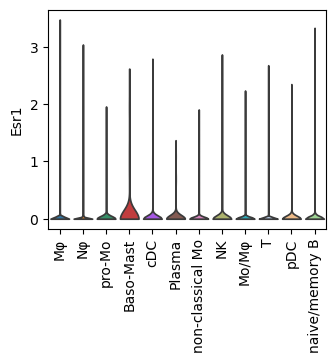

In [577]:
# Calculate mean score for each cluster
mean_scores = adata.obs.groupby('celltype_B')['esr_score'].mean()

# Sort clusters based on mean score in descending order
sorted_clusters = mean_scores.sort_values(ascending=False).index.tolist()

# Set the category order for plotting
adata.obs['celltype_B'] = adata.obs['celltype_B'].cat.reorder_categories(sorted_clusters, ordered=True)

# Plotting
with plt.rc_context({'figure.figsize': (4, 3)}):
    sc.pl.violin(adata, keys=['Esr1'], groupby='celltype_B', rotation=90, stripplot=False, #save='Response_to_Estrogen_AUCell_score_mature_cell_rank.pdf'
                )

/var/folders/37/xlq517ls2276293h4xc51ydc0000gn/T/ipykernel_9083/1342418066.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('afmhot_r')  # brown-white gradient


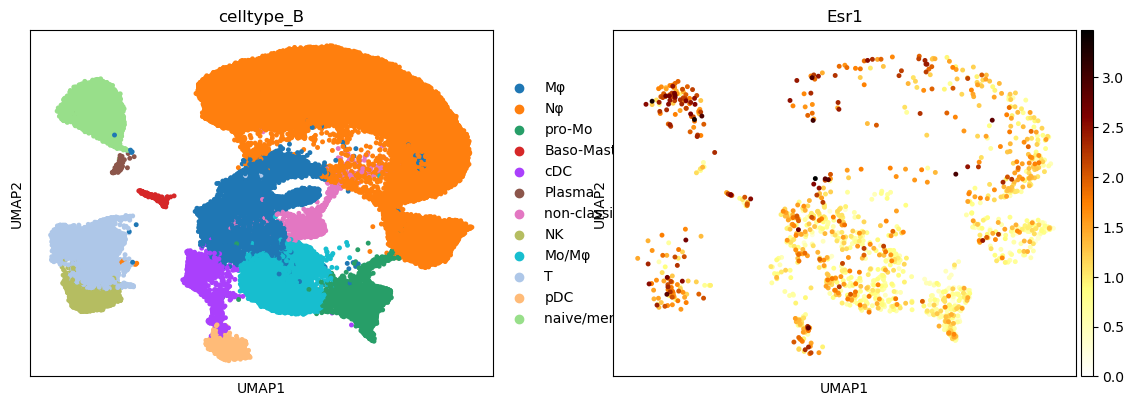

In [578]:
cmap = plt.cm.get_cmap('afmhot_r')  # brown-white gradient

with plt.rc_context({'figure.figsize': (6, 4.5)}):
    sc.pl.umap(adata, color= ['celltype_B','Esr1'], cmap=cmap, ncols=2, alpha=1, size=50#, save='human_OC_AUCell_score_feature_plot_mye.pdf'
              )

/var/folders/37/xlq517ls2276293h4xc51ydc0000gn/T/ipykernel_9083/2554409942.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  correlation_results = df.groupby(biotin_col).apply(lambda group: pearsonr(group[x_score], group[score_name]))
/var/folders/37/xlq517ls2276293h4xc51ydc0000gn/T/ipykernel_9083/2554409942.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  correlation_results = df.groupby(biotin_col).apply(lambda group: pearsonr(group[x_score], group[score_name]))
/var/folders/37/xlq517ls2276293h4xc51

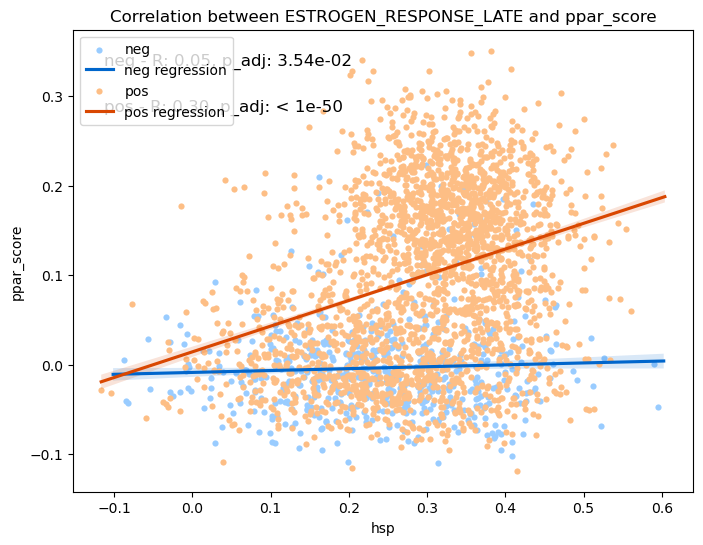

In [479]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from statsmodels.stats.multitest import multipletests
import numpy as np

def format_p_value(p_value):
    if p_value < 1e-50:
        return "< 1e-50"
    else:
        return f"{p_value:.2e}"

def all_plot_correlation(adata, score_name, x_score='hsp', celltype='Mφ', biotin_col='biotin', dot_size=1.5, dot_edge_width=0.5, colors={'pos': ('#ffcc99', '#ff6600'), 'neg': ('#99ccff', '#0066cc')}, save_path=None):
    # Filter data to only include specified cell type
    adata_filtered = adata[adata.obs['celltype_B'] == celltype]
    
    # Extract scores and biotin status
    x_score_values = adata_filtered.obs[x_score]
    y_score_values = adata_filtered.obs[score_name]
    biotin_status = adata_filtered.obs[biotin_col]
    
    # Create a DataFrame for easy manipulation
    df = pd.DataFrame({
        x_score: x_score_values,
        score_name: y_score_values,
        biotin_col: biotin_status
    })
    
    # Calculate correlation for each biotin group
    correlation_results = df.groupby(biotin_col).apply(lambda group: pearsonr(group[x_score], group[score_name]))
    correlation_df = pd.DataFrame(correlation_results.tolist(), index=correlation_results.index, columns=['correlation', 'p_value'])
    
    # Adjust p-values using FDR
    _, pvals_corrected, _, _ = multipletests(correlation_df['p_value'], method='fdr_bh')
    correlation_df['p_value_adj'] = pvals_corrected
    
    # Format p-values
    correlation_df['p_value_adj'] = correlation_df['p_value_adj'].apply(format_p_value)

    # Subsample 10% of cells from each biotin group for plotting
    df_sampled = df.groupby(biotin_col).apply(lambda x: x.sample(frac=0.3)).reset_index(drop=True)
    
    # Plotting
    plt.figure(figsize=(8, 6))
    
    for biotin_group in df[biotin_col].unique():
        df_group = df_sampled[df_sampled[biotin_col] == biotin_group]
        df_group_full = df[df[biotin_col] == biotin_group]
        
        sns.scatterplot(
            data=df_group, x=x_score, y=score_name, label=biotin_group, 
            color=colors[biotin_group][0], edgecolor='k', linewidth=dot_edge_width, s=dot_size * 10)
        
        # Regression line for the full data
        sns.regplot(
            data=df_group_full, x=x_score, y=score_name, scatter=False, 
            color=colors[biotin_group][1], label=f'{biotin_group} regression')
    
    # Annotate correlation scores and adjusted p-values
    for biotin_group, row in correlation_df.iterrows():
        plt.text(0.05, 0.95 - 0.1 * correlation_df.index.tolist().index(biotin_group), 
                 f'{biotin_group} - R: {row["correlation"]:.2f}, p_adj: {row["p_value_adj"]}', 
                 transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')
    
    plt.title(f'Correlation between ESTROGEN_RESPONSE_LATE and {score_name}')
    plt.xlabel(x_score)
    plt.ylabel(score_name)
    plt.legend()
    plt.grid(False)  # Remove grid lines
    ax.legend(loc='upper right')
    
    # Save the plot if save_path is provided
    if save_path:
        plt.savefig(save_path, format='pdf')
    plt.show()

# Example usage
all_plot_correlation(adata, 'ppar_score', dot_size=2, dot_edge_width=0, colors={'pos': ('#fdbe85', '#d94701'), 'neg': ('#99ccff', '#0066cc')}
                 #,save_path='correlation_plot_il10_score.pdf'
                )


/var/folders/37/xlq517ls2276293h4xc51ydc0000gn/T/ipykernel_9083/631718135.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  correlation_results = df.groupby(biotin_col).apply(
/var/folders/37/xlq517ls2276293h4xc51ydc0000gn/T/ipykernel_9083/631718135.py:35: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  correlation_results = df.groupby(biotin_col).apply(
/var/folders/37/xlq517ls2276293h4xc51ydc0000gn/T/ipykernel_9083/631718135.py:52: FutureWarning: The default of observed=False is deprecated and will be cha

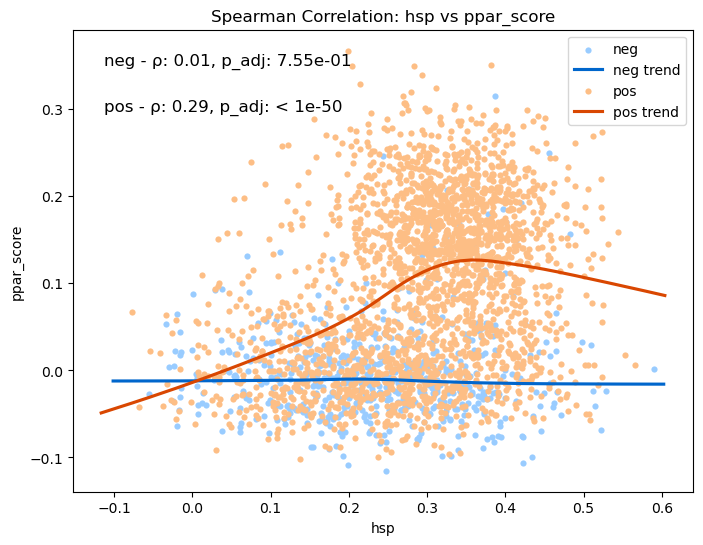

In [483]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr  # Changed to Spearman
from statsmodels.stats.multitest import multipletests
import numpy as np

def format_p_value(p_value):
    if p_value < 1e-50:
        return "< 1e-50"
    else:
        return f"{p_value:.2e}"

def all_plot_correlation(adata, score_name, x_score='hsp', celltype='Mφ', biotin_col='biotin', 
                        dot_size=1.5, dot_edge_width=0.5, 
                        colors={'pos': ('#ffcc99', '#ff6600'), 'neg': ('#99ccff', '#0066cc')}, 
                        save_path=None):
    # Filter data to only include specified cell type
    adata_filtered = adata[adata.obs['celltype_B'] == celltype]
    
    # Extract scores and biotin status
    x_score_values = adata_filtered.obs[x_score]
    y_score_values = adata_filtered.obs[score_name]
    biotin_status = adata_filtered.obs[biotin_col]
    
    # Create a DataFrame for easy manipulation
    df = pd.DataFrame({
        x_score: x_score_values,
        score_name: y_score_values,
        biotin_col: biotin_status
    })
    
    # Calculate SPEARMAN correlation for each biotin group
    correlation_results = df.groupby(biotin_col).apply(
        lambda group: spearmanr(group[x_score], group[score_name])  # Changed to spearmanr
    )
    correlation_df = pd.DataFrame(
        correlation_results.tolist(), 
        index=correlation_results.index, 
        columns=['correlation', 'p_value']
    )
    
    # Adjust p-values using FDR
    _, pvals_corrected, _, _ = multipletests(correlation_df['p_value'], method='fdr_bh')
    correlation_df['p_value_adj'] = pvals_corrected
    
    # Format p-values
    correlation_df['p_value_adj'] = correlation_df['p_value_adj'].apply(format_p_value)

    # Subsample 10% of cells from each biotin group for plotting
    df_sampled = df.groupby(biotin_col).apply(lambda x: x.sample(frac=0.3)).reset_index(drop=True)
    
    # Plotting
    plt.figure(figsize=(8, 6))
    
    for biotin_group in df[biotin_col].unique():
        df_group = df_sampled[df_sampled[biotin_col] == biotin_group]
        df_group_full = df[df[biotin_col] == biotin_group]
        
        sns.scatterplot(
            data=df_group, x=x_score, y=score_name, label=biotin_group, 
            color=colors[biotin_group][0], edgecolor='k', linewidth=dot_edge_width, s=dot_size * 10)
        
        # Add non-parametric loess line instead of linear regression
        sns.regplot(
            data=df_group_full, x=x_score, y=score_name, 
            scatter=False, lowess=True,  # Changed to LOWESS for non-parametric
            color=colors[biotin_group][1], label=f'{biotin_group} trend'
        )
    
    # Annotate correlation scores and adjusted p-values
    for biotin_group, row in correlation_df.iterrows():
        plt.text(0.05, 0.95 - 0.1 * correlation_df.index.tolist().index(biotin_group), 
                 f'{biotin_group} - ρ: {row["correlation"]:.2f}, p_adj: {row["p_value_adj"]}', 
                 transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')
    
    plt.title(f'Spearman Correlation: {x_score} vs {score_name}')  # Updated title
    plt.xlabel(x_score)
    plt.ylabel(score_name)
    plt.legend()
    plt.grid(False)
    
    # Save the plot if save_path is provided
    if save_path:
        plt.savefig(save_path, format='pdf', bbox_inches='tight')
    plt.show()

# Example usage
all_plot_correlation(
    adata, 
    'ppar_score', 
    dot_size=2, 
    dot_edge_width=0, 
    colors={'pos': ('#fdbe85', '#d94701'), 'neg': ('#99ccff', '#0066cc')}
    # save_path='correlation_plot_il10_score.pdf'
)

In [101]:
# Define your target genes
gene1 = 'Gper1'
gene2 = 'Esr1'


# --------------------------------------------------
# 1. Handle gene expression data and filtering
# --------------------------------------------------
# Get expressions (handle missing genes as zero)
expr1 = adata[:, gene1].X.toarray().flatten() if gene1 in adata.var_names else np.zeros(adata.n_obs)
expr2 = adata[:, gene2].X.toarray().flatten() if gene2 in adata.var_names else np.zeros(adata.n_obs)

# Filter cells with expression in both genes (>0)
valid_mask = (expr1 > 0) & (expr2 > 0)
adata = adata[valid_mask].copy()

# --------------------------------------------------
# 2. Check biotin groups in filtered data
# --------------------------------------------------
if 'biotin' not in adata.obs:
    raise ValueError("'biotin' column not found in observations")
    
# Ensure biotin is categorical and has 2 groups
adata.obs['biotin'] = adata.obs['biotin'].astype('category')
if len(adata.obs['biotin'].cat.categories) != 2:
    raise ValueError("Biotin should have exactly 2 categories (pos/neg)")

# --------------------------------------------------
# 3. Set up visualization
# --------------------------------------------------
fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True, sharex=True)
biotin_categories = adata.obs['biotin'].cat.categories

# --------------------------------------------------
# 4. Analysis per biotin group
# --------------------------------------------------
for i, biotin_group in enumerate(biotin_categories):
    # Subset to current biotin group
    mask = adata.obs['biotin'] == biotin_group
    adata_sub = adata[mask]
    
    # Get filtered expressions
    expr1_sub = adata_sub[:, gene1].X.toarray().flatten()
    expr2_sub = adata_sub[:, gene2].X.toarray().flatten()
    
    # --------------------------------------------------
    # 5. Calculate statistics
    # --------------------------------------------------
    if len(expr1_sub) >= 3:
        corr, pval = stats.spearmanr(expr1_sub, expr2_sub)
        m, b = np.polyfit(expr1_sub, expr2_sub, 1)
    else:
        corr, pval, m, b = np.nan, np.nan, np.nan, np.nan
    
    # --------------------------------------------------
    # 6. Plotting components
    # --------------------------------------------------
    ax = axs[i]
    
    # Scatter plot
    if len(expr1_sub) > 0:
        ax.scatter(expr1_sub, expr2_sub, 
                 alpha=0.6, s=20, 
                 edgecolor='w', linewidth=0.5)
    
    # Regression line
    if not np.isnan(m):
        x_range = np.linspace(min(expr1_sub), max(expr1_sub), 100)
        ax.plot(x_range, m*x_range + b, '--', 
                color='red', linewidth=2,
                label=f'y = {m:.2f}x + {b:.2f}')
    
    # Formatting
    ax.set_title(f'{biotin_group}\n(n={len(expr1_sub)})')
    ax.set_xlabel(f'{gene1} Expression')
    ax.set_ylabel(f'{gene2} Expression' if i == 0 else '')
    ax.grid(alpha=0.3)
    
    # Annotation box
    annotation_text = (f'Spearman r = {corr:.2f}\n' + 
                      (f'p = {pval:.1e}' if pval >= 0.0001 else 'p < 0.0001') 
                      if not np.isnan(corr) else 'Insufficient data')
    
    ax.text(0.05, 0.95, annotation_text,
           transform=ax.transAxes, va='top', ha='left',
           fontsize=10, bbox=dict(facecolor='white', alpha=0.8))

# --------------------------------------------------
# 7. Final plot adjustments
# --------------------------------------------------
plt.suptitle(f'{gene1} vs {gene2} Co-expression by Biotin Status\n(Filtered: Cells with >0 expression in both genes)',
            y=1.05, fontsize=12)
plt.tight_layout()
plt.show()

ValueError: Biotin should have exactly 2 categories (pos/neg)

/var/folders/37/xlq517ls2276293h4xc51ydc0000gn/T/ipykernel_59039/251436289.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cell_counts = df.groupby(['celltype_B', 'biotin']).size().reset_index(name='counts')
/var/folders/37/xlq517ls2276293h4xc51ydc0000gn/T/ipykernel_59039/251436289.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  total_cells_per_celltype = df.groupby('celltype_B').size()
/var/folders/37/xlq517ls2276293h4xc51ydc0000gn/T/ipykernel_59039/251436289.py:26: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Speci

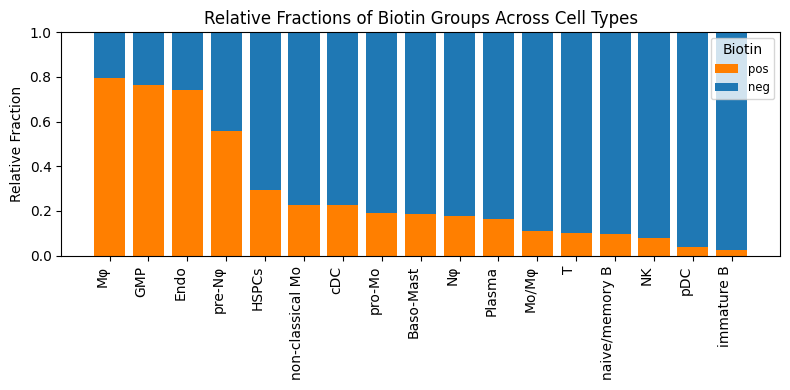

In [23]:
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import pandas as pd

# Extract the relevant data from the adata object
df = pd.DataFrame({
    'biotin': adata.obs['biotin'],
    'celltype_B': adata.obs['celltype_B']
})

# Convert the 'celltype_B' column to a category type
df['celltype_B'] = df['celltype_B'].astype('category')

# Count the number of cells for each cell type and biotin
cell_counts = df.groupby(['celltype_B', 'biotin']).size().reset_index(name='counts')

# Calculate the total number of cells per cell type across both biotin conditions
total_cells_per_celltype = df.groupby('celltype_B').size()

# Calculate the relative fraction of each biotin group per cell type (range 0-1)
cell_counts['relative_fraction'] = cell_counts.apply(
    lambda row: row['counts'] / total_cells_per_celltype[row['celltype_B']], axis=1
)

# Pivot the dataframe for stacked bar plotting and fill any missing values with 0
pivot_df = cell_counts.pivot_table(
    values='relative_fraction', 
    index='celltype_B', 
    columns='biotin', 
    fill_value=0
).reset_index()

# Sort the dataframe based on 'pos' values in descending order
pivot_df.sort_values(by='pos', ascending=False, inplace=True)

# Colors for the 'biotin' groups
biotin_colors = {"pos": "#ff7f00", "neg": "#1f78b4"}

# Create a single plot for all cell types
fig, ax = plt.subplots(figsize=(8, 4))

# Plot stacked bars
ax.bar(pivot_df['celltype_B'], pivot_df['pos'], label='pos', color=biotin_colors['pos'])
ax.bar(pivot_df['celltype_B'], pivot_df['neg'], label='neg', color=biotin_colors['neg'], bottom=pivot_df['pos'])

# Aesthetics
ax.set_title("Relative Fractions of Biotin Groups Across Cell Types")
ax.set_ylabel("Relative Fraction")
ax.set_ylim(0, 1)
ax.set_xticks(range(len(pivot_df['celltype_B'])))
ax.set_xticklabels(pivot_df['celltype_B'], rotation=90, ha="right")

# Display the legend
ax.legend(title="Biotin", loc='upper right', fontsize='small')

plt.tight_layout()
plt.savefig("across_celltype_relative_biotin_barplots_sorted.pdf", format="pdf", dpi=100)
plt.show()


In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

# Extract the relevant data from the adata object
df = pd.DataFrame({
    'tissue': adata.obs['tissue'],
    'biotin': adata.obs['biotin'],
    'celltype_C': adata.obs['celltype_C']
})

# Convert the 'celltype_C' column to a category type
df['celltype_C'] = df['celltype_C'].astype('category')

# Count the number of cells for each cell type per tissue and biotin
cell_counts = df.groupby(['celltype_C', 'tissue', 'biotin']).size().reset_index(name='counts')

# Calculate the total number of cells per cell type
total_cells_per_celltype = df.groupby(['celltype_C']).size()

# Calculate the fraction of each tissue-biotin combination within each cell type
cell_counts['fraction'] = cell_counts.apply(lambda row: (row['counts'] / total_cells_per_celltype[row['celltype_C']]) * 100, axis=1)

# Pivot the dataframe for stacked bar plotting and fill any missing values with 0
pivot_df = cell_counts.pivot_table(values='fraction', index=['celltype_C'], columns=['tissue', 'biotin'], fill_value=0).reset_index()

# Colors for the 'tissue-biotin' groups
tissue_biotin_combinations = pivot_df.columns[1:]  # Exclude 'celltype_C'
tissue_biotin_colors = plt.cm.tab20.colors[:len(tissue_biotin_combinations)]

# Create the plots and save to a PDF
with PdfPages("./outs/cell_type_sample_barplots_flipped.pdf") as pdf:
    fig, ax = plt.subplots(figsize=(11, 8.5))
    bottom = np.zeros(len(pivot_df))
    for idx, (tissue, biotin) in enumerate(tissue_biotin_combinations):
        values = pivot_df[(tissue, biotin)]
        ax.bar(pivot_df['celltype_C'], values, bottom=bottom, label=f"{tissue} ({biotin})", color=tissue_biotin_colors[idx])
        bottom += values

    # Aesthetics
    ax.set_title("Cell Type Fractions by Tissue-Biotin")
    ax.set_ylabel("Fraction (%)")
    ax.set_xlabel("Cell Types")
    ax.set_xticklabels(pivot_df['celltype_C'], rotation=45, ha='right')
    ax.legend(title="Tissue (Biotin)", loc='upper left', bbox_to_anchor=(1, 1))

    plt.tight_layout()
    # Save the plot to the PDF
    pdf.savefig(fig)
    plt.close(fig)

print("Barplots saved to 'cell_type_sample_barplots_flipped.pdf'")

Barplots saved to 'cell_type_sample_barplots_flipped.pdf'


/var/folders/37/xlq517ls2276293h4xc51ydc0000gn/T/ipykernel_9083/260214545.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cell_counts = df.groupby(['celltype_C', 'tissue', 'biotin']).size().reset_index(name='counts')
/var/folders/37/xlq517ls2276293h4xc51ydc0000gn/T/ipykernel_9083/260214545.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  total_cells_per_celltype = df.groupby(['celltype_C']).size()
/var/folders/37/xlq517ls2276293h4xc51ydc0000gn/T/ipykernel_9083/260214545.py:26: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pand

/var/folders/37/xlq517ls2276293h4xc51ydc0000gn/T/ipykernel_9083/161086660.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cell_counts = df.groupby(['integrated_snn_res.1.8', 'tissue', 'biotin']).size().reset_index(name='counts')
/var/folders/37/xlq517ls2276293h4xc51ydc0000gn/T/ipykernel_9083/161086660.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  total_cells_per_tissue_biotin = df.groupby(['tissue', 'biotin']).size()
/var/folders/37/xlq517ls2276293h4xc51ydc0000gn/T/ipykernel_9083/161086660.py:27: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a

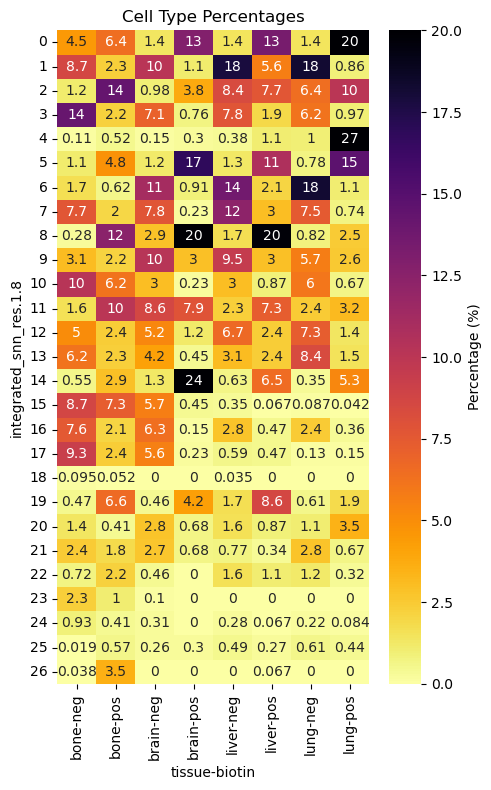

In [269]:
#change above as ridge plot
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Extract the relevant data from the adata object
df = pd.DataFrame({
    'tissue': adata.obs['tissue'],
    'biotin': adata.obs['biotin'],
    'integrated_snn_res.1.8': adata.obs['integrated_snn_res.1.8']
})

# Convert the 'celltype_C' column to a category type
df['integrated_snn_res.1.8'] = df['integrated_snn_res.1.8'].astype('category')

# Count the number of cells for each cell type per tissue and biotin
cell_counts = df.groupby(['integrated_snn_res.1.8', 'tissue', 'biotin']).size().reset_index(name='counts')

# Calculate the total number of cells per tissue and biotin
total_cells_per_tissue_biotin = df.groupby(['tissue', 'biotin']).size()

# Calculate the percentage of each cell type out of the total number of cells for each tissue and biotin
cell_counts['percentage'] = cell_counts.apply(lambda row: (row['counts'] / total_cells_per_tissue_biotin[(row['tissue'], row['biotin'])]) * 100, axis=1)

# Pivot the dataframe for heatmap and fill any missing values with 0
# Note: We are switching the 'index' and 'columns' arguments here to transpose the heatmap
heatmap_data = cell_counts.pivot_table(values='percentage', columns=['tissue', 'biotin'], index='integrated_snn_res.1.8', fill_value=0)

# Define color scale limits
color_scale_min = 0  # Adjust as needed
color_scale_max = 20 # Adjust as needed

# Plotting the heatmap
fig, ax = plt.subplots(figsize=(5, 8))
sns.heatmap(heatmap_data, cmap="inferno_r", ax=ax, annot=True, cbar_kws={'label': 'Percentage (%)'}, vmin=color_scale_min, vmax=color_scale_max)
ax.set_title("Cell Type Percentages")
plt.yticks(rotation=0)
plt.tight_layout()

# Save the figure
#plt.savefig("./outs/iia_ic_merged/neu_across_tissue_Biotin_heatmap.pdf", format="pdf", dpi=300)
plt.show()
